In [92]:
(* ============================================================ *)
(* S118B-R2                                                     *)
(* COMPOSITIONAL ADAPTIVE RESIDUAL EXPERIMENT SYNTHESIS         *)
(* ============================================================ *)
(*                                                              *)
(* Advances S118B by ONE capability only:                       *)
(*                                                              *)
(*      future experiment:  m^k                                 *)
(*                                                              *)
(* becomes                                                      *)
(*                                                              *)
(*      future experiment:  s . m^k                             *)
(*                                                              *)
(* where                                                        *)
(*      |s| <= 1                                                *)
(*      |m| <= 2                                                *)
(*      total future depth <= 48                                *)
(*                                                              *)
(* There is still:                                              *)
(* - NO fixed start-state probe bank                            *)
(* - NO equivalence oracle                                      *)
(* - NO teacher counterexample                                  *)
(* - NO true state count                                        *)
(* - NO hidden state semantics                                  *)
(* - NO hidden transition access                                *)
(*                                                              *)
(* Experiments are synthesized at runtime specifically for      *)
(* histories CURRENTLY merged into the same learned state.      *)
(* ============================================================ *)


ClearAll["Global`S118BR2*"];
ClearAll["Global`s118BR2*"];


s118BR2Result =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S118BR2Fail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S118BR2_STOP"];
);


Print["================================================"];
Print["S118B-R2 COMPOSITIONAL ADAPTIVE EXPERIMENT DISCOVERY"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC INTERFACE                                          *)
(* ============================================================ *)

alphabetS118BR2 =
  {0, 1, 2};


Print[
  "Primitive alphabet = ",
  alphabetS118BR2
];


Print["Output alphabet = {0,1}"];
Print["NO FIXED PROBE BANK."];
Print["NO EQUIVALENCE ORACLE."];
Print["NO TEACHER-PROVIDED COUNTEREXAMPLES."];
Print["NO TRUE STATE COUNT."];
Print["NO STATE SEMANTICS."];
Print["FUTURE EXPERIMENTS ARE SYNTHESIZED FOR CURRENTLY MERGED HISTORIES."];


(* ============================================================ *)
(* 2. FREEZE COMPOSITIONAL EXPERIMENT POLICY                    *)
(*                                                              *)
(* Benchmark does NOT yet exist.                                *)
(* ============================================================ *)

adaptiveAliasExtensionDepthS118BR2 =
  1;


adaptiveStemMaxLengthS118BR2 =
  1;


adaptiveMotifMaxLengthS118BR2 =
  2;


adaptiveMaximumFutureDepthS118BR2 =
  48;


adaptiveMaximumAlternativesPerStateS118BR2 =
  12;


adaptivePolicySpecS118BR2 =
  <|

    "Alphabet" ->
      alphabetS118BR2,

    "AliasExtensionDepth" ->
      adaptiveAliasExtensionDepthS118BR2,

    "StemMaximumLength" ->
      adaptiveStemMaxLengthS118BR2,

    "MotifMaximumLength" ->
      adaptiveMotifMaxLengthS118BR2,

    "MaximumFutureDepth" ->
      adaptiveMaximumFutureDepthS118BR2,

    "MaximumAlternativesPerState" ->
      adaptiveMaximumAlternativesPerStateS118BR2,

    "ExperimentForm" ->
      "StemThenRepeatedMotif",

    "Target" ->
      "HistoriesCurrentlyMappedToSameLearnedState",

    "FixedProbeBank" ->
      False

  |>;


frozenAdaptivePolicyHashS118BR2 =
  Hash[
    adaptivePolicySpecS118BR2,
    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["COMPOSITIONAL ADAPTIVE POLICY FROZEN"];


Print[
  "Stem maximum length = ",
  adaptiveStemMaxLengthS118BR2
];


Print[
  "Motif maximum length = ",
  adaptiveMotifMaxLengthS118BR2
];


Print[
  "Maximum future depth = ",
  adaptiveMaximumFutureDepthS118BR2
];


Print[
  "Policy hash = ",
  frozenAdaptivePolicyHashS118BR2
];


Print["HIDDEN BENCHMARK DOES NOT EXIST YET."];
Print["================================================"];


(* ============================================================ *)
(* 3. NEW HIDDEN BENCHMARK AFTER POLICY FREEZE                  *)
(* ============================================================ *)

hiddenBenchmarkSeedS118BR2 =
  1183817;


{
  hiddenDeepDepthS118BR2,
  hiddenShallowDepthS118BR2,
  hiddenRolePermutationS118BR2
} =
  BlockRandom[

    SeedRandom[
      hiddenBenchmarkSeedS118BR2
    ];


    {
      RandomInteger[
        {18, 36}
      ],

      RandomInteger[
        {4, 8}
      ],

      RandomSample[
        alphabetS118BR2
      ]
    }
  ];


hiddenDeepEntryTokenS118BR2 =
  hiddenRolePermutationS118BR2[[1]];


hiddenShallowEntryTokenS118BR2 =
  hiddenRolePermutationS118BR2[[2]];


hiddenCarryTokenS118BR2 =
  hiddenRolePermutationS118BR2[[3]];


S118BR2DelayState[
  depth_Integer
] :=
  3 + depth;


hiddenStartStateS118BR2 =
  1;


S118BR2EnvStep[
  hiddenState_Integer,
  token_Integer
] :=
Module[
  {
    depth
  },


  Which[

    hiddenState === 1,

      Which[

        token === hiddenDeepEntryTokenS118BR2,

          S118BR2DelayState[
            hiddenDeepDepthS118BR2
          ],


        token === hiddenShallowEntryTokenS118BR2,

          S118BR2DelayState[
            hiddenShallowDepthS118BR2
          ],


        token === hiddenCarryTokenS118BR2,

          1,


        True,

          Missing[
            "UnknownToken"
          ]
      ],


    hiddenState === 2,

      2,


    hiddenState >= 3,

      depth =
        hiddenState - 3;


      If[
        depth == 0,

        2,

        If[
          token === hiddenCarryTokenS118BR2,

          S118BR2DelayState[
            depth - 1
          ],

          2
        ]
      ],


    True,

      Missing[
        "UnknownHiddenState"
      ]

  ]
];


S118BR2EnvStateOutput[
  hiddenState_Integer
] :=
  Boole[
    hiddenState ===
      S118BR2DelayState[0]
  ];


S118BR2EnvStateAfter[
  seq_List
] :=
  Fold[
    S118BR2EnvStep,
    hiddenStartStateS118BR2,
    seq
  ];


S118BR2EnvRawOutput[
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S118BR2EnvStateAfter[
      seq
    ];


  If[
    IntegerQ[state],

    S118BR2EnvStateOutput[
      state
    ],

    Missing[
      "EnvironmentFailure"
    ]
  ]
];


Print["NEW HIDDEN BENCHMARK GENERATED AFTER POLICY FREEZE."];
Print["Hidden delay / state count / token roles remain sealed."];


(* ============================================================ *)
(* 4. PROSPECTIVE RANDOM HOLDOUT                                *)
(* ============================================================ *)

randomHoldoutSeedS118BR2 =
  1183818;


randomHoldoutDepthsS118BR2 =
  {
    80,
    200,
    500,
    1000
  };


randomHoldoutPerDepthCountS118BR2 =
  100;


prospectiveRandomHoldoutS118BR2 =
  BlockRandom[

    SeedRandom[
      randomHoldoutSeedS118BR2
    ];


    Flatten[
      Table[

        Table[

          <|

            "Depth" ->
              depth,

            "Sequence" ->
              RandomChoice[
                alphabetS118BR2,
                depth
              ]

          |>,

          {
            randomHoldoutPerDepthCountS118BR2
          }
        ],

        {
          depth,
          randomHoldoutDepthsS118BR2
        }
      ],

      1
    ]
  ];


Print[
  "Prospective random holdout = ",
  Length[
    prospectiveRandomHoldoutS118BR2
  ]
];


(* ============================================================ *)
(* 5. SEALED BALANCED STRUCTURED CHALLENGE                      *)
(* ============================================================ *)

challengeExactShallowS118BR2 =
  Table[

    <|

      "Kind" ->
        "ExactShallow",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118BR2,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118BR2
          },

          ConstantArray[
            hiddenCarryTokenS118BR2,
            hiddenShallowDepthS118BR2
          ]
        ]

    |>,

    {
      preamble,
      70,
      119
    }
  ];


challengeExactDeepS118BR2 =
  Table[

    <|

      "Kind" ->
        "ExactDeep",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118BR2,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118BR2
          },

          ConstantArray[
            hiddenCarryTokenS118BR2,
            hiddenDeepDepthS118BR2
          ]
        ]

    |>,

    {
      preamble,
      130,
      179
    }
  ];


challengeShallowShortS118BR2 =
  Table[

    <|

      "Kind" ->
        "ShallowOneShort",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118BR2,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118BR2
          },

          ConstantArray[
            hiddenCarryTokenS118BR2,
            hiddenShallowDepthS118BR2 - 1
          ]
        ]

    |>,

    {
      preamble,
      190,
      214
    }
  ];


challengeShallowLongS118BR2 =
  Table[

    <|

      "Kind" ->
        "ShallowOneLong",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118BR2,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118BR2
          },

          ConstantArray[
            hiddenCarryTokenS118BR2,
            hiddenShallowDepthS118BR2 + 1
          ]
        ]

    |>,

    {
      preamble,
      220,
      244
    }
  ];


challengeDeepShortS118BR2 =
  Table[

    <|

      "Kind" ->
        "DeepOneShort",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118BR2,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118BR2
          },

          ConstantArray[
            hiddenCarryTokenS118BR2,
            hiddenDeepDepthS118BR2 - 1
          ]
        ]

    |>,

    {
      preamble,
      250,
      274
    }
  ];


challengeDeepLongS118BR2 =
  Table[

    <|

      "Kind" ->
        "DeepOneLong",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118BR2,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118BR2
          },

          ConstantArray[
            hiddenCarryTokenS118BR2,
            hiddenDeepDepthS118BR2 + 1
          ]
        ]

    |>,

    {
      preamble,
      280,
      304
    }
  ];


(* ------------------------------------------------------------ *)
(* NEW R2 challenge:                                            *)
(* enter sink, then try to "restart" a valid delayed process.   *)
(* This specifically catches Root/Sink overmerge.               *)
(* ------------------------------------------------------------ *)

challengeRestartFromSinkS118BR2 =
  Table[

    <|

      "Kind" ->
        "RestartAfterSink",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118BR2,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118BR2,
            hiddenDeepEntryTokenS118BR2,
            hiddenShallowEntryTokenS118BR2
          },

          ConstantArray[
            hiddenCarryTokenS118BR2,
            hiddenShallowDepthS118BR2
          ]
        ]

    |>,

    {
      preamble,
      310,
      334
    }
  ];


prospectiveChallengeHoldoutS118BR2 =
  Join[
    challengeExactShallowS118BR2,
    challengeExactDeepS118BR2,
    challengeShallowShortS118BR2,
    challengeShallowLongS118BR2,
    challengeDeepShortS118BR2,
    challengeDeepLongS118BR2,
    challengeRestartFromSinkS118BR2
  ];


Print[
  "Prospective structured challenge = ",
  Length[
    prospectiveChallengeHoldoutS118BR2
  ]
];


Print["Challenge outputs remain sealed."];


(* ============================================================ *)
(* 6. MEMBERSHIP ORACLE                                        *)
(* ============================================================ *)

membershipCacheS118BR2 =
  <||>;


membershipUniqueCountS118BR2 =
  0;


membershipNewBySourceS118BR2 =
  <|

    "Table" -> 0,

    "AdaptiveExperiment" -> 0,

    "RandomHoldout" -> 0,

    "ChallengeHoldout" -> 0,

    "Audit" -> 0

  |>;


S118BR2SeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S118BR2MembershipY[
  seq_List,
  source_String : "Table"
] :=
Module[
  {
    key,
    y,
    oldCount
  },


  key =
    S118BR2SeqKey[
      seq
    ];


  If[
    KeyExistsQ[
      membershipCacheS118BR2,
      key
    ],

    Lookup[
      membershipCacheS118BR2,
      key
    ],


    y =
      S118BR2EnvRawOutput[
        seq
      ];


    If[
      !MemberQ[
        {0, 1},
        y
      ],

      S118BR2Fail[
        "Membership oracle returned non-binary output."
      ]
    ];


    membershipUniqueCountS118BR2++;


    AssociateTo[
      membershipCacheS118BR2,
      key -> y
    ];


    oldCount =
      Lookup[
        membershipNewBySourceS118BR2,
        source,
        0
      ];


    AssociateTo[
      membershipNewBySourceS118BR2,
      source -> (oldCount + 1)
    ];


    y
  ]
];


(* ============================================================ *)
(* 7. RESIDUAL TABLE                                            *)
(* ============================================================ *)

prefixSetS118BR2 =
  {
    {}
  };


suffixSetS118BR2 =
  {
    {}
  };


S118BR2Row[
  prefix_List
] :=
  Table[

    S118BR2MembershipY[
      Join[
        prefix,
        suffix
      ],
      "Table"
    ],

    {
      suffix,
      suffixSetS118BR2
    }
  ];


S118BR2RowKey[
  row_List
] :=
  ToString[
    InputForm[
      row
    ]
  ];


S118BR2Frontier[] :=
  DeleteDuplicates[
    Flatten[
      Table[

        Append[
          prefix,
          token
        ],

        {
          prefix,
          prefixSetS118BR2
        },

        {
          token,
          alphabetS118BR2
        }
      ],

      1
    ]
  ];


(* ============================================================ *)
(* 8. CLOSEDNESS                                                *)
(* ============================================================ *)

S118BR2FindUnclosed[] :=
Module[
  {
    rows,
    frontier
  },


  rows =
    S118BR2Row /@
      prefixSetS118BR2;


  frontier =
    S118BR2Frontier[];


  SelectFirst[
    frontier,

    Function[
      candidate,

      !MemberQ[
        rows,
        S118BR2Row[
          candidate
        ]
      ]
    ],

    Missing[
      "Closed"
    ]
  ]
];


(* ============================================================ *)
(* 9. CONSISTENCY                                               *)
(* ============================================================ *)

S118BR2FindInconsistency[] :=
Module[
  {
    result
  },


  result =
    Catch[

      Module[
        {
          n,
          i,
          j,
          p1,
          p2,
          row1,
          row2,
          next1,
          next2,
          pos,
          oldSuffix,
          newSuffix
        },


        n =
          Length[
            prefixSetS118BR2
          ];


        For[
          i = 1,
          i <= n,
          i++,


          p1 =
            prefixSetS118BR2[[i]];


          row1 =
            S118BR2Row[
              p1
            ];


          For[
            j = i + 1,
            j <= n,
            j++,


            p2 =
              prefixSetS118BR2[[j]];


            row2 =
              S118BR2Row[
                p2
              ];


            If[
              row1 === row2,


              Do[

                next1 =
                  S118BR2Row[
                    Append[
                      p1,
                      token
                    ]
                  ];


                next2 =
                  S118BR2Row[
                    Append[
                      p2,
                      token
                    ]
                  ];


                If[
                  next1 =!= next2,


                  pos =
                    FirstPosition[
                      MapThread[
                        Unequal,
                        {
                          next1,
                          next2
                        }
                      ],
                      True,
                      Missing[
                        "NotFound"
                      ]
                    ];


                  If[
                    MissingQ[pos],

                    S118BR2Fail[
                      "Consistency difference has no suffix."
                    ]
                  ];


                  oldSuffix =
                    suffixSetS118BR2[[
                      pos[[1]]
                    ]];


                  newSuffix =
                    Join[
                      {token},
                      oldSuffix
                    ];


                  Throw[

                    <|

                      "NewSuffix" ->
                        newSuffix

                    |>,

                    "S118BR2_INCONSISTENCY"
                  ];
                ],

                {
                  token,
                  alphabetS118BR2
                }
              ];
            ];
          ];
        ];


        Missing[
          "Consistent"
        ]
      ],

      "S118BR2_INCONSISTENCY"
    ];


  result
];


(* ============================================================ *)
(* 10. STABILIZE TABLE                                          *)
(* ============================================================ *)

S118BR2StabilizeTable[] :=
Module[
  {
    done,
    unclosed,
    inconsistency
  },


  done =
    False;


  While[
    !TrueQ[done],


    unclosed =
      S118BR2FindUnclosed[];


    If[
      !MissingQ[unclosed],


      prefixSetS118BR2 =
        DeleteDuplicates[
          Append[
            prefixSetS118BR2,
            unclosed
          ]
        ],


      inconsistency =
        S118BR2FindInconsistency[];


      If[
        AssociationQ[
          inconsistency
        ],

        suffixSetS118BR2 =
          DeleteDuplicates[
            Append[
              suffixSetS118BR2,
              inconsistency[
                "NewSuffix"
              ]
            ]
          ],

        done =
          True;
      ];
    ];

  ];

];


(* ============================================================ *)
(* 11. BUILD HYPOTHESIS                                         *)
(* ============================================================ *)

S118BR2BuildHypothesis[] :=
Module[
  {
    rows,
    uniqueRows,
    rowToState,
    reps,
    transitions,
    outputs,
    rep,
    successorRow,
    successorState,
    i
  },


  rows =
    S118BR2Row /@
      prefixSetS118BR2;


  uniqueRows =
    DeleteDuplicates[
      rows
    ];


  rowToState =
    Association[
      Table[

        S118BR2RowKey[
          uniqueRows[[i]]
        ] ->
          i,

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  reps =
    Association[
      Table[

        i ->

          SelectFirst[
            prefixSetS118BR2,

            Function[
              prefix,
              S118BR2Row[
                prefix
              ] ===
                uniqueRows[[i]]
            ]
          ],

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  transitions =
    <||>;


  outputs =
    <||>;


  Do[

    rep =
      Lookup[
        reps,
        i
      ];


    AssociateTo[
      outputs,

      i ->
        S118BR2MembershipY[
          rep,
          "Table"
        ]
    ];


    Do[

      successorRow =
        S118BR2Row[
          Append[
            rep,
            token
          ]
        ];


      successorState =
        Lookup[
          rowToState,

          S118BR2RowKey[
            successorRow
          ],

          Missing[
            "Unclosed"
          ]
        ];


      If[
        MissingQ[
          successorState
        ],

        S118BR2Fail[
          "Hypothesis is not closed."
        ]
      ];


      AssociateTo[
        transitions,

        ToString[
          InputForm[
            {i, token}
          ]
        ] ->
          successorState
      ],

      {
        token,
        alphabetS118BR2
      }
    ],

    {
      i,
      Length[
        uniqueRows
      ]
    }
  ];


  <|

    "StateCount" ->
      Length[
        uniqueRows
      ],

    "Rows" ->
      uniqueRows,

    "RepresentativeByState" ->
      reps,

    "Transitions" ->
      transitions,

    "Outputs" ->
      outputs,

    "StartState" ->
      Lookup[
        rowToState,
        S118BR2RowKey[
          S118BR2Row[
            {}
          ]
        ]
      ]

  |>
];


(* ============================================================ *)
(* 12. HYPOTHESIS EXECUTION                                     *)
(* ============================================================ *)

S118BR2TransitionKey[
  state_Integer,
  token_Integer
] :=
  ToString[
    InputForm[
      {state, token}
    ]
  ];


S118BR2HypothesisStep[
  hypothesis_Association,
  state_Integer,
  token_Integer
] :=
  Lookup[
    hypothesis[
      "Transitions"
    ],

    S118BR2TransitionKey[
      state,
      token
    ],

    Missing[
      "UnknownTransition"
    ]
  ];


S118BR2HypothesisStateAfter[
  hypothesis_Association,
  seq_List
] :=
  Fold[

    Function[
      {state, token},

      If[
        IntegerQ[state],

        S118BR2HypothesisStep[
          hypothesis,
          state,
          token
        ],

        state
      ]
    ],

    hypothesis[
      "StartState"
    ],

    seq
  ];


S118BR2HypothesisOutput[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S118BR2HypothesisStateAfter[
      hypothesis,
      seq
    ];


  If[
    IntegerQ[state],

    Lookup[
      hypothesis[
        "Outputs"
      ],
      state,
      Missing[
        "UnknownState"
      ]
    ],

    Missing[
      "UnknownTransition"
    ]
  ]
];


(* ============================================================ *)
(* 13. CURRENT ALIAS HISTORIES                                  *)
(* ============================================================ *)

S118BR2AliasPairs[
  hypothesis_Association
] :=
Module[
  {
    reps,
    extensionWords,
    histories,
    rows,
    grouped,
    pairs,
    canonical,
    alternatives
  },


  reps =
    Values[
      hypothesis[
        "RepresentativeByState"
      ]
    ];


  extensionWords =
    Flatten[
      Table[

        Tuples[
          alphabetS118BR2,
          len
        ],

        {
          len,
          0,
          adaptiveAliasExtensionDepthS118BR2
        }
      ],

      1
    ];


  histories =
    DeleteDuplicates[
      Flatten[
        Table[

          Table[
            Join[
              rep,
              ext
            ],

            {
              ext,
              extensionWords
            }
          ],

          {
            rep,
            reps
          }
        ],

        1
      ]
    ];


  rows =
    Table[

      <|

        "History" ->
          h,

        "State" ->
          S118BR2HypothesisStateAfter[
            hypothesis,
            h
          ]

      |>,

      {
        h,
        histories
      }
    ];


  grouped =
    GroupBy[
      rows,
      #["State"] &
    ];


  pairs =
    {};


  Do[

    canonical =
      Lookup[
        hypothesis[
          "RepresentativeByState"
        ],
        state
      ];


    alternatives =
      Select[
        Lookup[
          grouped,
          state,
          {}
        ],

        #["History"] =!= canonical &
      ];


    alternatives =
      SortBy[
        alternatives,
        {
          Length[
            #["History"]
          ] &,
          ToString[
            InputForm[
              #["History"]
            ]
          ] &
        }
      ];


    alternatives =
      Take[
        alternatives,
        UpTo[
          adaptiveMaximumAlternativesPerStateS118BR2
        ]
      ];


    Do[

      AppendTo[
        pairs,

        <|

          "LearnedState" ->
            state,

          "History1" ->
            canonical,

          "History2" ->
            alt[
              "History"
            ]

        |>
      ],

      {
        alt,
        alternatives
      }
    ],

    {
      state,
      Range[
        hypothesis[
          "StateCount"
        ]
      ]
    }
  ];


  pairs
];


(* ============================================================ *)
(* 14. COMPOSITIONAL FUTURE PROGRAM SYNTHESIS                   *)
(*                                                              *)
(* Generates structural descriptions:                           *)
(*                                                              *)
(*   stem . motif^k                                             *)
(*                                                              *)
(* dynamically each learning round.                             *)
(* ============================================================ *)

S118BR2FuturePrograms[] :=
Module[
  {
    stems,
    motifs,
    records,
    maxRepeat,
    suffix,
    sorted,
    unique
  },


  stems =
    Flatten[
      Table[

        Tuples[
          alphabetS118BR2,
          len
        ],

        {
          len,
          0,
          adaptiveStemMaxLengthS118BR2
        }
      ],

      1
    ];


  motifs =
    Flatten[
      Table[

        Tuples[
          alphabetS118BR2,
          len
        ],

        {
          len,
          1,
          adaptiveMotifMaxLengthS118BR2
        }
      ],

      1
    ];


  records =
    {};


  Do[

    Do[

      maxRepeat =
        Floor[
          (
            adaptiveMaximumFutureDepthS118BR2 -
            Length[stem]
          ) /
          Length[motif]
        ];


      If[
        maxRepeat >= 1,

        Do[

          suffix =
            Join[
              stem,

              Flatten[
                ConstantArray[
                  motif,
                  repeatCount
                ],
                1
              ]
            ];


          AppendTo[
            records,

            <|

              "Stem" ->
                stem,

              "Motif" ->
                motif,

              "RepeatCount" ->
                repeatCount,

              "Suffix" ->
                suffix,

              "SuffixLength" ->
                Length[
                  suffix
                ],

              "Compositional" ->
                (
                  Length[
                    stem
                  ] > 0
                )

            |>
          ],

          {
            repeatCount,
            1,
            maxRepeat
          }
        ];
      ],

      {
        motif,
        motifs
      }
    ],

    {
      stem,
      stems
    }
  ];


  (* always include empty future experiment *)
  AppendTo[
    records,

    <|

      "Stem" ->
        {},

      "Motif" ->
        {},

      "RepeatCount" ->
        0,

      "Suffix" ->
        {},

      "SuffixLength" ->
        0,

      "Compositional" ->
        False

    |>
  ];


  sorted =
    SortBy[
      records,

      Function[
        record,
        {
          record[
            "SuffixLength"
          ],
          Length[
            record[
              "Stem"
            ]
          ],
          Length[
            record[
              "Motif"
            ]
          ],
          record[
            "RepeatCount"
          ],
          ToString[
            InputForm[
              record[
                "Suffix"
              ]
            ]
          ]
        }
      ]
    ];


  unique =
    DeleteDuplicatesBy[
      sorted,

      Function[
        record,
        ToString[
          InputForm[
            record[
              "Suffix"
            ]
          ]
        ]
      ]
    ];


  unique
];


(* ============================================================ *)
(* 15. ADAPTIVE COMPOSITIONAL WITNESS SEARCH                    *)
(*                                                              *)
(* suffix-major ordering finds relatively short witnesses first *)
(* without materializing pair x suffix experiment matrix.       *)
(* ============================================================ *)

adaptiveSearchRoundCountS118BR2 =
  0;


adaptiveExperimentAttemptsTotalS118BR2 =
  0;


lastAdaptiveCandidateCountS118BR2 =
  0;


lastAdaptiveAttemptsS118BR2 =
  0;


adaptiveWitnessLogS118BR2 =
  {};


S118BR2FindAdaptiveWitness[
  hypothesis_Association
] :=
Module[
  {
    pairs,
    programs,
    totalCandidates,
    attempts,
    result,
    program,
    pair,
    seq1,
    seq2,
    predictedState1,
    predictedState2,
    predicted1,
    predicted2,
    observed1,
    observed2
  },


  adaptiveSearchRoundCountS118BR2++;


  pairs =
    S118BR2AliasPairs[
      hypothesis
    ];


  programs =
    S118BR2FuturePrograms[];


  totalCandidates =
    Length[pairs] *
      Length[programs];


  lastAdaptiveCandidateCountS118BR2 =
    totalCandidates;


  attempts =
    0;


  result =
    Catch[

      Do[

        program =
          programs[[programIndex]];


        Do[

          pair =
            pairs[[pairIndex]];


          attempts++;


          adaptiveExperimentAttemptsTotalS118BR2++;


          predictedState1 =
            S118BR2HypothesisStateAfter[
              hypothesis,
              pair[
                "History1"
              ]
            ];


          predictedState2 =
            S118BR2HypothesisStateAfter[
              hypothesis,
              pair[
                "History2"
              ]
            ];


          If[
            predictedState1 =!=
              predictedState2,

            S118BR2Fail[
              "Adaptive pair is not currently merged."
            ]
          ];


          seq1 =
            Join[
              pair[
                "History1"
              ],
              program[
                "Suffix"
              ]
            ];


          seq2 =
            Join[
              pair[
                "History2"
              ],
              program[
                "Suffix"
              ]
            ];


          predicted1 =
            S118BR2HypothesisOutput[
              hypothesis,
              seq1
            ];


          predicted2 =
            S118BR2HypothesisOutput[
              hypothesis,
              seq2
            ];


          If[
            predicted1 =!=
              predicted2,

            S118BR2Fail[
              "Merged histories produced different learned predictions."
            ]
          ];


          observed1 =
            S118BR2MembershipY[
              seq1,
              "AdaptiveExperiment"
            ];


          observed2 =
            S118BR2MembershipY[
              seq2,
              "AdaptiveExperiment"
            ];


          If[
            observed1 =!=
              observed2,

            Throw[

              <|

                "LearnedStateBeforeSplit" ->
                  pair[
                    "LearnedState"
                  ],

                "History1" ->
                  pair[
                    "History1"
                  ],

                "History2" ->
                  pair[
                    "History2"
                  ],

                "Stem" ->
                  program[
                    "Stem"
                  ],

                "Motif" ->
                  program[
                    "Motif"
                  ],

                "RepeatCount" ->
                  program[
                    "RepeatCount"
                  ],

                "Suffix" ->
                  program[
                    "Suffix"
                  ],

                "SuffixLength" ->
                  program[
                    "SuffixLength"
                  ],

                "Compositional" ->
                  program[
                    "Compositional"
                  ],

                "FullSequence1" ->
                  seq1,

                "FullSequence2" ->
                  seq2,

                "PredictedOutput" ->
                  predicted1,

                "ObservedOutput1" ->
                  observed1,

                "ObservedOutput2" ->
                  observed2,

                "AttemptIndex" ->
                  attempts

              |>,

              "S118BR2_WITNESS"
            ];
          ],

          {
            pairIndex,
            1,
            Length[
              pairs
            ]
          }
        ],

        {
          programIndex,
          1,
          Length[
            programs
          ]
        }
      ];


      Missing[
        "NoAdaptiveWitness"
      ],

      "S118BR2_WITNESS"
    ];


  lastAdaptiveAttemptsS118BR2 =
    attempts;


  result
];


(* ============================================================ *)
(* 16. REFINEMENT                                               *)
(* ============================================================ *)

S118BR2PrefixesOf[
  seq_List
] :=
  Table[
    Take[
      seq,
      k
    ],
    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S118BR2SuffixesOf[
  seq_List
] :=
  Table[
    Drop[
      seq,
      k
    ],
    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S118BR2Refine[
  witness_Association
] :=
(

  prefixSetS118BR2 =
    DeleteDuplicates[
      Join[
        prefixSetS118BR2,

        S118BR2PrefixesOf[
          witness[
            "FullSequence1"
          ]
        ],

        S118BR2PrefixesOf[
          witness[
            "FullSequence2"
          ]
        ]
      ]
    ];


  suffixSetS118BR2 =
    DeleteDuplicates[
      Join[
        suffixSetS118BR2,

        S118BR2SuffixesOf[
          witness[
            "Suffix"
          ]
        ]
      ]
    ];

);


(* ============================================================ *)
(* 17. LEARNING LOOP                                            *)
(* ============================================================ *)

learningRoundS118BR2 =
  0;


learningRoundLogS118BR2 =
  {};


adaptiveSearchStableS118BR2 =
  False;


adaptiveFullScanInvariantS118BR2 =
  True;


candidateHypothesisS118BR2 =
  Missing[
    "NotBuilt"
  ];


Print["================================================"];
Print["ACTIVE COMPOSITIONAL EXPERIMENT LEARNING"];
Print["================================================"];


learningTimingS118BR2 =
  AbsoluteTiming[

    While[
      !TrueQ[
        adaptiveSearchStableS118BR2
      ],


      learningRoundS118BR2++;


      If[
        learningRoundS118BR2 > 100,

        S118BR2Fail[
          "Learning-round guard exceeded."
        ]
      ];


      S118BR2StabilizeTable[];


      candidateHypothesisS118BR2 =
        S118BR2BuildHypothesis[];


      witnessS118BR2 =
        S118BR2FindAdaptiveWitness[
          candidateHypothesisS118BR2
        ];


      If[
        MissingQ[
          witnessS118BR2
        ] &&

        lastAdaptiveAttemptsS118BR2 =!=
          lastAdaptiveCandidateCountS118BR2,

        adaptiveFullScanInvariantS118BR2 =
          False;


        S118BR2Fail[
          "No witness returned before full adaptive candidate scan."
        ]
      ];


      If[
        AssociationQ[
          witnessS118BR2
        ] &&

        witnessS118BR2[
          "AttemptIndex"
        ] =!=
          lastAdaptiveAttemptsS118BR2,

        adaptiveFullScanInvariantS118BR2 =
          False;


        S118BR2Fail[
          "Witness attempt index mismatch."
        ]
      ];


      If[
        MissingQ[
          witnessS118BR2
        ],


        adaptiveSearchStableS118BR2 =
          True;


        AppendTo[
          learningRoundLogS118BR2,

          <|

            "Round" ->
              learningRoundS118BR2,

            "CandidateStates" ->
              candidateHypothesisS118BR2[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118BR2
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118BR2
              ],

            "MaximumSuffixLength" ->
              Max[
                Length /@
                  suffixSetS118BR2
              ],

            "MembershipQueries" ->
              membershipUniqueCountS118BR2,

            "AdaptiveCandidates" ->
              lastAdaptiveCandidateCountS118BR2,

            "AdaptiveAttempts" ->
              lastAdaptiveAttemptsS118BR2,

            "Result" ->
              "NoWitness",

            "WitnessSuffixLength" ->
              Missing[
                "None"
              ],

            "CompositionalWitness" ->
              Missing[
                "None"
              ]

          |>
        ],


        AppendTo[
          adaptiveWitnessLogS118BR2,
          witnessS118BR2
        ];


        AppendTo[
          learningRoundLogS118BR2,

          <|

            "Round" ->
              learningRoundS118BR2,

            "CandidateStates" ->
              candidateHypothesisS118BR2[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118BR2
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118BR2
              ],

            "MaximumSuffixLength" ->
              Max[
                Length /@
                  suffixSetS118BR2
              ],

            "MembershipQueries" ->
              membershipUniqueCountS118BR2,

            "AdaptiveCandidates" ->
              lastAdaptiveCandidateCountS118BR2,

            "AdaptiveAttempts" ->
              lastAdaptiveAttemptsS118BR2,

            "Result" ->
              "StateSplit",

            "WitnessSuffixLength" ->
              witnessS118BR2[
                "SuffixLength"
              ],

            "Stem" ->
              witnessS118BR2[
                "Stem"
              ],

            "Motif" ->
              witnessS118BR2[
                "Motif"
              ],

            "RepeatCount" ->
              witnessS118BR2[
                "RepeatCount"
              ],

            "CompositionalWitness" ->
              witnessS118BR2[
                "Compositional"
              ]

          |>
        ];


        S118BR2Refine[
          witnessS118BR2
        ];
      ];


      Print[
        "Round ",
        learningRoundS118BR2,
        ": states=",
        candidateHypothesisS118BR2[
          "StateCount"
        ],
        ", prefixes=",
        Length[
          prefixSetS118BR2
        ],
        ", suffixes=",
        Length[
          suffixSetS118BR2
        ],
        ", membership=",
        membershipUniqueCountS118BR2,
        ", candidates=",
        lastAdaptiveCandidateCountS118BR2,
        ", attempts=",
        lastAdaptiveAttemptsS118BR2,
        ", result=",

        If[
          adaptiveSearchStableS118BR2,

          "FULL SEARCH NO WITNESS",

          StringJoin[
            "SPLIT suffix=",
            ToString[
              witnessS118BR2[
                "SuffixLength"
              ]
            ],
            ", compositional=",
            ToString[
              witnessS118BR2[
                "Compositional"
              ]
            ]
          ]
        ]
      ];

    ];

  ];


Print[
  "Learning seconds = ",
  N[
    learningTimingS118BR2[[1]]
  ]
];


Print[
  "Learning rounds = ",
  learningRoundS118BR2
];


Print[
  "Adaptive witnesses = ",
  Length[
    adaptiveWitnessLogS118BR2
  ]
];


Print[
  "Witness suffix lengths = ",
  (
    #[
      "SuffixLength"
    ] &
  ) /@
    adaptiveWitnessLogS118BR2
];


Print[
  "Compositional witness flags = ",
  (
    #[
      "Compositional"
    ] &
  ) /@
    adaptiveWitnessLogS118BR2
];


Print[
  "Membership queries = ",
  membershipUniqueCountS118BR2
];


(* ============================================================ *)
(* 18. HOLDOUT LEAKAGE                                          *)
(* ============================================================ *)

randomHoldoutTouchedBeforeFreezeS118BR2 =
  Count[
    prospectiveRandomHoldoutS118BR2,

    row_Association /;

      KeyExistsQ[
        membershipCacheS118BR2,

        S118BR2SeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


challengeTouchedBeforeFreezeS118BR2 =
  Count[
    prospectiveChallengeHoldoutS118BR2,

    row_Association /;

      KeyExistsQ[
        membershipCacheS118BR2,

        S118BR2SeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


Print[
  "Random holdout touched = ",
  randomHoldoutTouchedBeforeFreezeS118BR2
];


Print[
  "Challenge holdout touched = ",
  challengeTouchedBeforeFreezeS118BR2
];


(* ============================================================ *)
(* 19. POLICY CHECK + FREEZE                                    *)
(* ============================================================ *)

adaptivePolicyHashUnchangedS118BR2 =
  Hash[
    adaptivePolicySpecS118BR2,
    "SHA256",
    "HexString"
  ] ===
    frozenAdaptivePolicyHashS118BR2;


If[
  !TrueQ[
    adaptivePolicyHashUnchangedS118BR2
  ],

  S118BR2Fail[
    "Adaptive policy changed."
  ]
];


frozenHypothesisS118BR2 =
  candidateHypothesisS118BR2;


frozenSuffixSetS118BR2 =
  suffixSetS118BR2;


membershipQueriesBeforeFreezeS118BR2 =
  membershipUniqueCountS118BR2;


frozenMachineHashS118BR2 =
  Hash[
    {
      frozenHypothesisS118BR2[
        "StateCount"
      ],
      frozenHypothesisS118BR2[
        "Transitions"
      ],
      frozenHypothesisS118BR2[
        "Outputs"
      ],
      frozenHypothesisS118BR2[
        "StartState"
      ],
      frozenSuffixSetS118BR2
    },

    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S118B-R2 MACHINE FROZEN"];


Print[
  "States = ",
  frozenHypothesisS118BR2[
    "StateCount"
  ]
];


Print[
  "Transitions = ",
  Length[
    frozenHypothesisS118BR2[
      "Transitions"
    ]
  ]
];


Print[
  "Membership queries = ",
  membershipQueriesBeforeFreezeS118BR2
];


Print["================================================"];


(* ============================================================ *)
(* 20. RANDOM HOLDOUT                                           *)
(* ============================================================ *)

randomHoldoutRowsS118BR2 =
  Table[

    Module[
      {
        seq,
        learned,
        truth
      },


      seq =
        row[
          "Sequence"
        ];


      learned =
        S118BR2HypothesisOutput[
          frozenHypothesisS118BR2,
          seq
        ];


      truth =
        S118BR2MembershipY[
          seq,
          "RandomHoldout"
        ];


      <|

        "Depth" ->
          row[
            "Depth"
          ],

        "Match" ->
          (
            learned === truth
          )

      |>

    ],

    {
      row,
      prospectiveRandomHoldoutS118BR2
    }
  ];


randomHoldoutMatchesS118BR2 =
  Count[
    (
      TrueQ[
        #[
          "Match"
        ]
      ] &
    ) /@
      randomHoldoutRowsS118BR2,
    True
  ];


randomHoldoutAccuracyS118BR2 =
  N[
    randomHoldoutMatchesS118BR2 /
      Length[
        randomHoldoutRowsS118BR2
      ]
  ];


Print[
  "Random holdout = ",
  randomHoldoutMatchesS118BR2,
  " / ",
  Length[
    randomHoldoutRowsS118BR2
  ]
];


(* ============================================================ *)
(* 21. STRUCTURED CHALLENGE                                     *)
(* ============================================================ *)

challengeRowsS118BR2 =
  Table[

    Module[
      {
        seq,
        learned,
        truth
      },


      seq =
        row[
          "Sequence"
        ];


      learned =
        S118BR2HypothesisOutput[
          frozenHypothesisS118BR2,
          seq
        ];


      truth =
        S118BR2MembershipY[
          seq,
          "ChallengeHoldout"
        ];


      <|

        "Kind" ->
          row[
            "Kind"
          ],

        "LearnedY" ->
          learned,

        "TrueY" ->
          truth,

        "Match" ->
          (
            learned === truth
          )

      |>

    ],

    {
      row,
      prospectiveChallengeHoldoutS118BR2
    }
  ];


challengeMatchesS118BR2 =
  Count[
    (
      TrueQ[
        #[
          "Match"
        ]
      ] &
    ) /@
      challengeRowsS118BR2,
    True
  ];


challengeAccuracyS118BR2 =
  N[
    challengeMatchesS118BR2 /
      Length[
        challengeRowsS118BR2
      ]
  ];


challengePerKindS118BR2 =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          challengeRowsS118BR2,
          #["Kind"] === kind &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Kind" ->
          kind,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      kind,
      DeleteDuplicates[
        (
          #[
            "Kind"
          ] &
        ) /@
          challengeRowsS118BR2
      ]
    }
  ];


Print[
  "Structured challenge = ",
  challengeMatchesS118BR2,
  " / ",
  Length[
    challengeRowsS118BR2
  ]
];


(* ============================================================ *)
(* 22. EXHAUSTIVE 0..9 AUDIT                                    *)
(*                                                              *)
(* 29524 sequences.                                             *)
(* Previous S118B failure first appeared at length 9.            *)
(* ============================================================ *)

auditMaxLengthS118BR2 =
  9;


auditSequencesS118BR2 =
  Flatten[
    Table[

      Tuples[
        alphabetS118BR2,
        len
      ],

      {
        len,
        0,
        auditMaxLengthS118BR2
      }
    ],

    1
  ];


auditMatchesS118BR2 =
  Count[
    Table[

      S118BR2HypothesisOutput[
        frozenHypothesisS118BR2,
        seq
      ] ===

      S118BR2MembershipY[
        seq,
        "Audit"
      ],

      {
        seq,
        auditSequencesS118BR2
      }
    ],

    True
  ];


auditAccuracyS118BR2 =
  N[
    auditMatchesS118BR2 /
      Length[
        auditSequencesS118BR2
      ]
  ];


Print[
  "Exhaustive length 0..9 = ",
  auditMatchesS118BR2,
  " / ",
  Length[
    auditSequencesS118BR2
  ]
];


(* ============================================================ *)
(* 23. MACHINE HASH                                             *)
(* ============================================================ *)

frozenMachineHashUnchangedS118BR2 =
  Hash[
    {
      frozenHypothesisS118BR2[
        "StateCount"
      ],
      frozenHypothesisS118BR2[
        "Transitions"
      ],
      frozenHypothesisS118BR2[
        "Outputs"
      ],
      frozenHypothesisS118BR2[
        "StartState"
      ],
      frozenSuffixSetS118BR2
    },

    "SHA256",
    "HexString"
  ] ===
    frozenMachineHashS118BR2;


Print[
  "Frozen hash unchanged = ",
  frozenMachineHashUnchangedS118BR2
];


(* ============================================================ *)
(* 24. POST-HOC TRUE SYSTEM                                     *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC TRUE SYSTEM AUDIT"];
Print["================================================"];


Print[
  "Hidden deep delay = ",
  hiddenDeepDepthS118BR2
];


Print[
  "Hidden shallow delay = ",
  hiddenShallowDepthS118BR2
];


Print[
  "Hidden roles = ",
  hiddenRolePermutationS118BR2
];


S118BR2TrueReachableStates[] :=
Module[
  {
    seen,
    queue,
    current,
    next
  },


  seen =
    {
      hiddenStartStateS118BR2
    };


  queue =
    seen;


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    Do[

      next =
        S118BR2EnvStep[
          current,
          token
        ];


      If[
        !MemberQ[
          seen,
          next
        ],

        AppendTo[
          seen,
          next
        ];


        AppendTo[
          queue,
          next
        ];
      ],

      {
        token,
        alphabetS118BR2
      }
    ];

  ];


  Sort[
    seen
  ]
];


trueReachableStatesS118BR2 =
  S118BR2TrueReachableStates[];


trueReachableCountS118BR2 =
  Length[
    trueReachableStatesS118BR2
  ];


(* ============================================================ *)
(* 25. TRUE MINIMAL PARTITION                                   *)
(* ============================================================ *)

S118BR2TrueMinimalPartition[] :=
Module[
  {
    partition,
    stateToBlock,
    signatures,
    newPartition,
    stable
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS118BR2,

        Function[
          state,
          S118BR2EnvStateOutput[
            state
          ]
        ]
      ]
    ];


  stable =
    False;


  While[
    !TrueQ[
      stable
    ],


    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S118BR2EnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S118BR2EnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS118BR2
                }
              ]
            ],

          {
            state,
            trueReachableStatesS118BR2
          }
        ]
      ];


    newPartition =
      Values[
        GroupBy[
          trueReachableStatesS118BR2,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    If[
      Sort[
        Sort /@
          newPartition
      ] ===
        Sort[
          Sort /@
            partition
        ],

      stable =
        True,

      partition =
        newPartition;
    ];

  ];


  partition
];


trueMinimalPartitionS118BR2 =
  S118BR2TrueMinimalPartition[];


trueMinimalStateCountS118BR2 =
  Length[
    trueMinimalPartitionS118BR2
  ];


trueMachineMinimalS118BR2 =
  And[
    trueReachableCountS118BR2 ===
      trueMinimalStateCountS118BR2,

    AllTrue[
      trueMinimalPartitionS118BR2,
      Length[#] == 1 &
    ]
  ];


Print[
  "True reachable/minimal states = ",
  trueReachableCountS118BR2,
  " / ",
  trueMinimalStateCountS118BR2
];


(* ============================================================ *)
(* 26. TRUE DISTINGUISHING DEPTH                                *)
(* ============================================================ *)

S118BR2TruePairDepth[
  state1_Integer,
  state2_Integer
] :=
Module[
  {
    result
  },


  result =
    Catch[

      Module[
        {
          queue,
          visited,
          current,
          a,
          b,
          depth,
          key
        },


        queue =
          {
            {
              state1,
              state2,
              0
            }
          };


        visited =
          <||>;


        While[
          Length[
            queue
          ] > 0,


          current =
            First[
              queue
            ];


          queue =
            Rest[
              queue
            ];


          a =
            current[[1]];


          b =
            current[[2]];


          depth =
            current[[3]];


          key =
            ToString[
              InputForm[
                Sort[
                  {
                    a,
                    b
                  }
                ]
              ]
            ];


          If[
            !KeyExistsQ[
              visited,
              key
            ],


            AssociateTo[
              visited,
              key -> True
            ];


            If[
              S118BR2EnvStateOutput[a] =!=
                S118BR2EnvStateOutput[b],

              Throw[
                depth,
                "S118BR2_DEPTH"
              ];
            ];


            Do[

              AppendTo[
                queue,

                {
                  S118BR2EnvStep[
                    a,
                    token
                  ],

                  S118BR2EnvStep[
                    b,
                    token
                  ],

                  depth + 1
                }
              ],

              {
                token,
                alphabetS118BR2
              }
            ];
          ];

        ];


        Missing[
          "NotDistinguishable"
        ]
      ],

      "S118BR2_DEPTH"
    ];


  result
];


truePairDepthsS118BR2 =
  Table[

    S118BR2TruePairDepth[
      pair[[1]],
      pair[[2]]
    ],

    {
      pair,
      Subsets[
        trueReachableStatesS118BR2,
        {2}
      ]
    }
  ];


trueMaxDistinguishingDepthS118BR2 =
  Max[
    Cases[
      truePairDepthsS118BR2,
      _Integer
    ]
  ];


Print[
  "TRUE maximum distinguishing depth = ",
  trueMaxDistinguishingDepthS118BR2
];


(* ============================================================ *)
(* 27. LEARNED -> TRUE STATE CORRESPONDENCE                     *)
(* ============================================================ *)

learnedStateCountS118BR2 =
  frozenHypothesisS118BR2[
    "StateCount"
  ];


stateCorrespondenceS118BR2 =
  Table[

    Module[
      {
        rep,
        trueState
      },


      rep =
        Lookup[
          frozenHypothesisS118BR2[
            "RepresentativeByState"
          ],
          learnedState
        ];


      trueState =
        S118BR2EnvStateAfter[
          rep
        ];


      <|

        "LearnedState" ->
          learnedState,

        "TrueState" ->
          trueState

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS118BR2
      ]
    }
  ];


mappedTrueStatesS118BR2 =
  (
    #[
      "TrueState"
    ] &
  ) /@
    stateCorrespondenceS118BR2;


stateBijectionPassedS118BR2 =
  And[
    learnedStateCountS118BR2 ===
      trueReachableCountS118BR2,

    Length[
      DeleteDuplicates[
        mappedTrueStatesS118BR2
      ]
    ] ===
      learnedStateCountS118BR2,

    Sort[
      DeleteDuplicates[
        mappedTrueStatesS118BR2
      ]
    ] ===
      Sort[
        trueReachableStatesS118BR2
      ]
  ];


phiS118BR2 =
  Association[
    Table[
      row[
        "LearnedState"
      ] ->
        row[
          "TrueState"
        ],
      {
        row,
        stateCorrespondenceS118BR2
      }
    ]
  ];


Print[
  "State-space bijection = ",
  stateBijectionPassedS118BR2
];


(* ============================================================ *)
(* 28. TRANSITION ISOMORPHISM                                   *)
(* ============================================================ *)

transitionAuditS118BR2 =
  Flatten[
    Table[

      Module[
        {
          learnedNext,
          trueSource,
          mappedNext,
          trueNext
        },


        learnedNext =
          S118BR2HypothesisStep[
            frozenHypothesisS118BR2,
            learnedState,
            token
          ];


        trueSource =
          Lookup[
            phiS118BR2,
            learnedState,
            Missing[]
          ];


        mappedNext =
          Lookup[
            phiS118BR2,
            learnedNext,
            Missing[]
          ];


        trueNext =
          If[
            IntegerQ[
              trueSource
            ],

            S118BR2EnvStep[
              trueSource,
              token
            ],

            Missing[]
          ];


        mappedNext === trueNext

      ],

      {
        learnedState,
        Range[
          learnedStateCountS118BR2
        ]
      },

      {
        token,
        alphabetS118BR2
      }
    ],

    1
  ];


transitionMatchesS118BR2 =
  Count[
    transitionAuditS118BR2,
    True
  ];


transitionTotalS118BR2 =
  Length[
    transitionAuditS118BR2
  ];


transitionIsomorphismPassedS118BR2 =
  transitionMatchesS118BR2 ===
    transitionTotalS118BR2;


Print[
  "Transition correspondence = ",
  transitionMatchesS118BR2,
  " / ",
  transitionTotalS118BR2
];


(* ============================================================ *)
(* 29. OUTPUT CORRESPONDENCE                                    *)
(* ============================================================ *)

stateOutputMatchesS118BR2 =
  Count[
    Table[

      Module[
        {
          trueState,
          learnedOutput,
          trueOutput
        },


        trueState =
          Lookup[
            phiS118BR2,
            learnedState
          ];


        learnedOutput =
          Lookup[
            frozenHypothesisS118BR2[
              "Outputs"
            ],
            learnedState
          ];


        trueOutput =
          S118BR2EnvStateOutput[
            trueState
          ];


        learnedOutput ===
          trueOutput

      ],

      {
        learnedState,
        Range[
          learnedStateCountS118BR2
        ]
      }
    ],

    True
  ];


stateOutputExactS118BR2 =
  stateOutputMatchesS118BR2 ===
    learnedStateCountS118BR2;


Print[
  "State-output correspondence = ",
  stateOutputMatchesS118BR2,
  " / ",
  learnedStateCountS118BR2
];


(* ============================================================ *)
(* 30. SYNCHRONIZED PRODUCT                                     *)
(* ============================================================ *)

S118BR2ProductClosure[] :=
Module[
  {
    reached,
    frontier,
    nextPairs,
    newPairs
  },


  reached =
    {
      {
        frozenHypothesisS118BR2[
          "StartState"
        ],
        hiddenStartStateS118BR2
      }
    };


  frontier =
    reached;


  While[
    Length[
      frontier
    ] > 0,


    nextPairs =
      DeleteDuplicates[
        Flatten[
          Table[

            {
              S118BR2HypothesisStep[
                frozenHypothesisS118BR2,
                pair[[1]],
                token
              ],

              S118BR2EnvStep[
                pair[[2]],
                token
              ]
            },

            {
              pair,
              frontier
            },

            {
              token,
              alphabetS118BR2
            }
          ],

          1
        ]
      ];


    newPairs =
      Select[
        nextPairs,
        !MemberQ[
          reached,
          #
        ] &
      ];


    reached =
      Join[
        reached,
        newPairs
      ];


    frontier =
      newPairs;

  ];


  reached
];


productPairsS118BR2 =
  S118BR2ProductClosure[];


productPairCountS118BR2 =
  Length[
    productPairsS118BR2
  ];


productLearnedFunctionalS118BR2 =
  AllTrue[
    Range[
      learnedStateCountS118BR2
    ],

    Function[
      state,

      Length[
        DeleteDuplicates[
          (
            #[[2]] &
          ) /@
            Select[
              productPairsS118BR2,
              #[[1]] === state &
            ]
        ]
      ] == 1
    ]
  ];


productTrueFunctionalS118BR2 =
  AllTrue[
    trueReachableStatesS118BR2,

    Function[
      state,

      Length[
        DeleteDuplicates[
          (
            #[[1]] &
          ) /@
            Select[
              productPairsS118BR2,
              #[[2]] === state &
            ]
        ]
      ] == 1
    ]
  ];


exactMachineIsomorphismS118BR2 =
  And[
    frozenMachineHashUnchangedS118BR2,
    adaptivePolicyHashUnchangedS118BR2,
    adaptiveFullScanInvariantS118BR2,
    trueMachineMinimalS118BR2,
    stateBijectionPassedS118BR2,
    transitionIsomorphismPassedS118BR2,
    stateOutputExactS118BR2,
    productPairCountS118BR2 ===
      learnedStateCountS118BR2,
    productLearnedFunctionalS118BR2,
    productTrueFunctionalS118BR2
  ];


allFiniteSequenceEquivalentS118BR2 =
  exactMachineIsomorphismS118BR2;


(* ============================================================ *)
(* 31. COMPOSITIONALITY GATES                                   *)
(* ============================================================ *)

compositionalWitnessCountS118BR2 =
  Count[
    (
      TrueQ[
        #[
          "Compositional"
        ]
      ] &
    ) /@
      adaptiveWitnessLogS118BR2,
    True
  ];


compositionalAdaptiveExperimentConfirmedS118BR2 =
  compositionalWitnessCountS118BR2 > 0;


finalAdaptiveFullScanConfirmedS118BR2 =
  And[
    adaptiveSearchStableS118BR2,
    lastAdaptiveAttemptsS118BR2 ===
      lastAdaptiveCandidateCountS118BR2
  ];


prospectiveStrongS118BR2 =
  And[
    adaptiveFullScanInvariantS118BR2,
    finalAdaptiveFullScanConfirmedS118BR2,
    compositionalAdaptiveExperimentConfirmedS118BR2,
    randomHoldoutTouchedBeforeFreezeS118BR2 === 0,
    challengeTouchedBeforeFreezeS118BR2 === 0,
    Abs[
      randomHoldoutAccuracyS118BR2 - 1.
    ] < 10^-12,
    Abs[
      challengeAccuracyS118BR2 - 1.
    ] < 10^-12,
    Abs[
      auditAccuracyS118BR2 - 1.
    ] < 10^-12,
    exactMachineIsomorphismS118BR2
  ];


diagnosisS118BR2 =
  Which[

    prospectiveStrongS118BR2,

      "S118B_R2_SUCCESS_COMPOSITIONAL_ADAPTIVE_EXPERIMENT_SYNTHESIS_RECOVERS_THE_EXACT_MINIMAL_MACHINE_WITHOUT_FIXED_PROBE_BANK_EQUIVALENCE_ORACLE_OR_TEACHER_COUNTEREXAMPLES",


    !compositionalAdaptiveExperimentConfirmedS118BR2,

      "NO_COMPOSITIONAL_ADAPTIVE_WITNESS_WAS_REQUIRED_OR_DISCOVERED",


    !stateBijectionPassedS118BR2,

      "COMPOSITIONAL_EXPERIMENTS_FOUND_SPLITS_BUT_TRUE_MINIMAL_STATE_SPACE_WAS_NOT_RECOVERED",


    !transitionIsomorphismPassedS118BR2,

      "STATE_COUNT_MATCHES_BUT_TRANSITION_STRUCTURE_IS_NOT_EXACT",


    challengeAccuracyS118BR2 < 1.,

      "MODEL_FAILS_STRUCTURED_POST_SINK_OR_DELAYED_CHALLENGES",


    True,

      "INCONCLUSIVE"

  ];


(* ============================================================ *)
(* 32. FINAL REPORT                                             *)
(* ============================================================ *)

finalS118BR2 =
  <|

    "Stage" ->
      "S118B_R2_CompositionalAdaptiveExperimentSynthesis",

    "FixedProbeBankUsed" ->
      False,

    "EquivalenceOracleUsed" ->
      False,

    "TeacherCounterexamples" ->
      0,

    "LearningRounds" ->
      learningRoundS118BR2,

    "AdaptiveWitnesses" ->
      Length[
        adaptiveWitnessLogS118BR2
      ],

    "CompositionalWitnesses" ->
      compositionalWitnessCountS118BR2,

    "WitnessSuffixLengths" ->
      (
        #[
          "SuffixLength"
        ] &
      ) /@
        adaptiveWitnessLogS118BR2,

    "WitnessStructures" ->
      (
        <|
          "Stem" ->
            #["Stem"],
          "Motif" ->
            #["Motif"],
          "RepeatCount" ->
            #["RepeatCount"],
          "SuffixLength" ->
            #["SuffixLength"]
        |> &
      ) /@
        adaptiveWitnessLogS118BR2,

    "FinalAdaptiveCandidates" ->
      lastAdaptiveCandidateCountS118BR2,

    "FinalAdaptiveAttempts" ->
      lastAdaptiveAttemptsS118BR2,

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS118BR2,

    "MembershipBySource" ->
      membershipNewBySourceS118BR2,

    "LearnedStates" ->
      learnedStateCountS118BR2,

    "RandomHoldoutTouched" ->
      randomHoldoutTouchedBeforeFreezeS118BR2,

    "ChallengeTouched" ->
      challengeTouchedBeforeFreezeS118BR2,

    "RandomHoldoutAccuracy" ->
      randomHoldoutAccuracyS118BR2,

    "ChallengeAccuracy" ->
      challengeAccuracyS118BR2,

    "ExhaustiveAccuracy" ->
      auditAccuracyS118BR2,

    "HiddenDeepDelayPostHoc" ->
      hiddenDeepDepthS118BR2,

    "HiddenShallowDelayPostHoc" ->
      hiddenShallowDepthS118BR2,

    "TrueStates" ->
      trueReachableCountS118BR2,

    "TrueMinimalStates" ->
      trueMinimalStateCountS118BR2,

    "TrueMaxDistinguishingDepth" ->
      trueMaxDistinguishingDepthS118BR2,

    "StateBijection" ->
      stateBijectionPassedS118BR2,

    "TransitionMatches" ->
      transitionMatchesS118BR2,

    "TransitionTotal" ->
      transitionTotalS118BR2,

    "StateOutputMatches" ->
      stateOutputMatchesS118BR2,

    "ProductPairs" ->
      productPairCountS118BR2,

    "CompositionalAdaptiveExperimentConfirmed" ->
      compositionalAdaptiveExperimentConfirmedS118BR2,

    "ExactMachineIsomorphism" ->
      exactMachineIsomorphismS118BR2,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS118BR2,

    "ProspectiveStrong" ->
      prospectiveStrongS118BR2,

    "Diagnosis" ->
      diagnosisS118BR2

  |>;


Print["================================================"];
Print["S118B-R2 COMPLETE"];


Print[
  "Learning rounds = ",
  learningRoundS118BR2
];


Print[
  "Adaptive witnesses = ",
  Length[
    adaptiveWitnessLogS118BR2
  ]
];


Print[
  "Compositional witnesses = ",
  compositionalWitnessCountS118BR2
];


Print[
  "Witness structures = ",
  finalS118BR2[
    "WitnessStructures"
  ]
];


Print[
  "Membership queries = ",
  membershipQueriesBeforeFreezeS118BR2
];


Print[
  "Learned states = ",
  learnedStateCountS118BR2
];


Print[
  "Random holdout = ",
  randomHoldoutMatchesS118BR2,
  " / ",
  Length[
    randomHoldoutRowsS118BR2
  ]
];


Print[
  "Structured challenge = ",
  challengeMatchesS118BR2,
  " / ",
  Length[
    challengeRowsS118BR2
  ]
];


Print[
  "Exhaustive 0..9 = ",
  auditMatchesS118BR2,
  " / ",
  Length[
    auditSequencesS118BR2
  ]
];


Print[
  "True reachable/minimal = ",
  trueReachableCountS118BR2,
  " / ",
  trueMinimalStateCountS118BR2
];


Print[
  "TRUE maximum distinguishing depth = ",
  trueMaxDistinguishingDepthS118BR2
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS118BR2
];


Print[
  "Transition correspondence = ",
  transitionMatchesS118BR2,
  " / ",
  transitionTotalS118BR2
];


Print[
  "Synchronized product pairs = ",
  productPairCountS118BR2
];


Print[
  "Exact machine isomorphism = ",
  exactMachineIsomorphismS118BR2
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS118BR2
];


Print[
  "Prospective strong = ",
  prospectiveStrongS118BR2
];


Print[
  "Diagnosis = ",
  diagnosisS118BR2
];


Print["================================================"];


finalS118BR2

),

"S118BR2_STOP"
];

S118B-R2 COMPOSITIONAL ADAPTIVE EXPERIMENT DISCOVERY
Primitive alphabet = {0, 1, 2}
Output alphabet = {0,1}
NO FIXED PROBE BANK.
NO EQUIVALENCE ORACLE.
NO TEACHER-PROVIDED COUNTEREXAMPLES.
NO TRUE STATE COUNT.
NO STATE SEMANTICS.
FUTURE EXPERIMENTS ARE SYNTHESIZED FOR CURRENTLY MERGED HISTORIES.
COMPOSITIONAL ADAPTIVE POLICY FROZEN
Stem maximum length = 1
Motif maximum length = 2
Maximum future depth = 48
Policy hash = a62cbee423e172f7a31cd28dafdb0e26cd45a74d5722500059cbc6577d7708c7
HIDDEN BENCHMARK DOES NOT EXIST YET.
NEW HIDDEN BENCHMARK GENERATED AFTER POLICY FREEZE.
Hidden delay / state count / token roles remain sealed.
Prospective random holdout = 400
Prospective structured challenge = 225
Challenge outputs remain sealed.
ACTIVE COMPOSITIONAL EXPERIMENT LEARNING
Round 1: states=1, prefixes=16, suffixes=8, membership=298,\
 
>    candidates=2937, attempts=297, result=SPLIT suffix=7, compositional=False
Round 2: states=9, prefixes=25, suffixes=9, membership=1819,\
 
>    candidates

Dataset[{<|Round -> 1, CandidateStates -> 1, PrefixCount -> 1, SuffixCount -> 1, 
 
>     MaximumSuffixLength -> 0, MembershipQueries -> 298, AdaptiveCandidates -> 2937, 
 
>     AdaptiveAttempts -> 297, Result -> StateSplit, WitnessSuffixLength -> 7, 
 
>     Stem -> {}, Motif -> {1}, RepeatCount -> 7, CompositionalWitness -> False|>, 
 
>    <|Round -> 2, CandidateStates -> 9, PrefixCount -> 16, SuffixCount -> 8, 
 
>     MaximumSuffixLength -> 7, MembershipQueries -> 1819, AdaptiveCandidates -> 11748, 
 
>     AdaptiveAttempts -> 1657, Result -> StateSplit, WitnessSuffixLength -> 8, 
 
>     Stem -> {2}, Motif -> {1}, RepeatCount -> 7, CompositionalWitness -> True|>, 
 
>    <|Round -> 3, CandidateStates -> 10, PrefixCount -> 25, SuffixCount -> 9, 
 
>     MaximumSuffixLength -> 8, MembershipQueries -> 4447, AdaptiveCandidates -> 12727, 
 
>     AdaptiveAttempts -> 4007, Result -> StateSplit, WitnessSuffixLength -> 17, 
 
>     Stem -> {}, Motif -> {1}, RepeatCount -> 17, CompositionalWitness -> False|>, 
 
>    <|Round -> 4, CandidateStates -> 21, PrefixCount -> 43, SuffixCount -> 20, 
 
>     MaximumSuffixLength -> 18, MembershipQueries -> 16699, 
 
>     AdaptiveCandidates -> 13706, AdaptiveAttempts -> 13706, Result -> NoWitness, 
 
>     WitnessSuffixLength -> Missing[None], CompositionalWitness -> Missing[None]|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Round, CandidateStates, PrefixCount, 
 
>      SuffixCount, MaximumSuffixLength, MembershipQueries, AdaptiveCandidates, 
 
>      AdaptiveAttempts, Result, WitnessSuffixLength, Stem, Motif, RepeatCount, 
 
>      CompositionalWitness}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], TypeSystem`AnyLength], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 1], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 4], <||>]
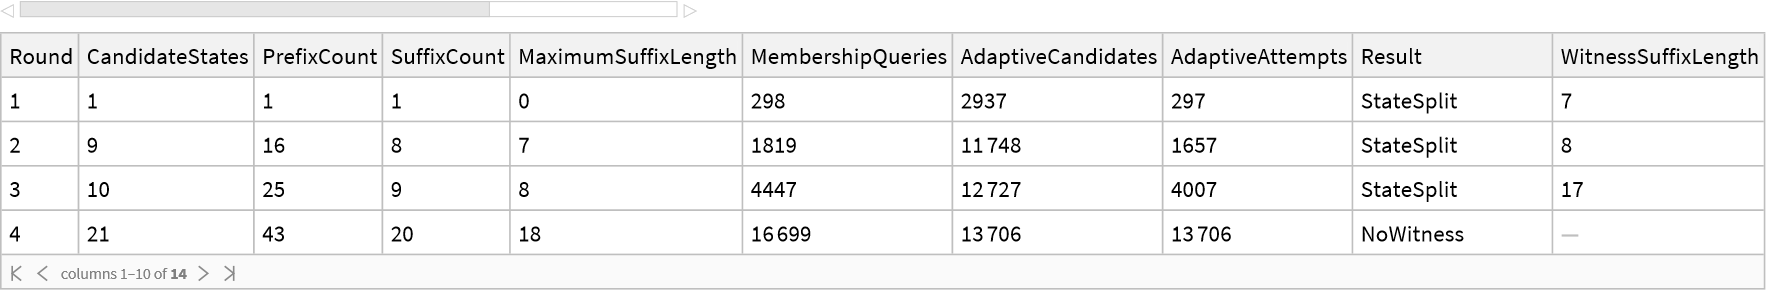

In [128]:
Dataset[
  learningRoundLogS118BR2
]

In [133]:
Dataset[
  challengePerKindS118BR2
]

Dataset[{<|Kind -> ExactShallow, Sequences -> 50, Matches -> 50, Accuracy -> 1.|>, 
 
>    <|Kind -> ExactDeep, Sequences -> 50, Matches -> 50, Accuracy -> 1.|>, 
 
>    <|Kind -> ShallowOneShort, Sequences -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> ShallowOneLong, Sequences -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> DeepOneShort, Sequences -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> DeepOneLong, Sequences -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> RestartAfterSink, Sequences -> 25, Matches -> 25, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Kind, Sequences, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 7], <||>]

<|Rounds -> 4, AdaptiveWitnesses -> 3, CompositionalWitnesses -> 1, 
 
>   WitnessStructures -> 
 
>    {<|Stem -> {}, Motif -> {1}, RepeatCount -> 7, SuffixLength -> 7|>, 
 
>     <|Stem -> {2}, Motif -> {1}, RepeatCount -> 7, SuffixLength -> 8|>, 
 
>     <|Stem -> {}, Motif -> {1}, RepeatCount -> 17, SuffixLength -> 17|>}, 
 
>   FinalAdaptiveCandidates -> 13706, FinalAdaptiveAttempts -> 13706, 
 
>   MembershipQueries -> 16699, LearnedStates -> 21, TrueStates -> 21, 
 
>   TrueMinimalStates -> 21, TrueMaxDistinguishingDepth -> 18, 
 
>   RandomHoldoutAccuracy -> 1., ChallengeAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>   StateBijection -> True, TransitionMatches -> 63, TransitionTotal -> 63, 
 
>   ProductPairs -> 21, CompositionalAdaptiveExperiment -> True, 
 
>   ExactMachineIsomorphism -> True, AllFiniteSequenceEquivalent -> True, 
 
>   ProspectiveStrong -> True, Diagnosis -> 
 
>    S118B_R2_SUCCESS_COMPOSITIONAL_ADAPTIVE_EXPERIMENT_SYNTHESIS_RECOVERS_THE_EXACT_MIN\
 
>     IMAL_MACHINE_WITHOUT_FIXED_PROBE_BANK_EQUIVALENCE_ORACLE_OR_TEACHER_COUNTEREXAMPLES
 
>    |>
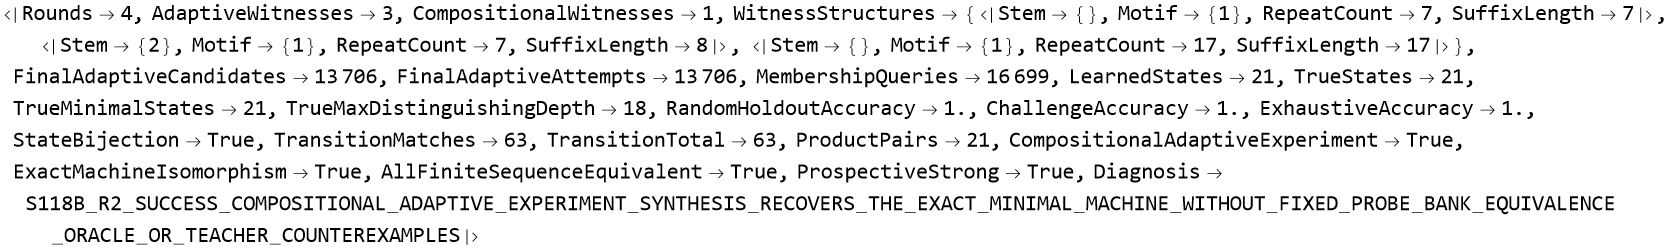

In [138]:
<|

  "Rounds" ->
    learningRoundS118BR2,

  "AdaptiveWitnesses" ->
    Length[
      adaptiveWitnessLogS118BR2
    ],

  "CompositionalWitnesses" ->
    compositionalWitnessCountS118BR2,

  "WitnessStructures" ->
    finalS118BR2[
      "WitnessStructures"
    ],

  "FinalAdaptiveCandidates" ->
    lastAdaptiveCandidateCountS118BR2,

  "FinalAdaptiveAttempts" ->
    lastAdaptiveAttemptsS118BR2,

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS118BR2,

  "LearnedStates" ->
    learnedStateCountS118BR2,

  "TrueStates" ->
    trueReachableCountS118BR2,

  "TrueMinimalStates" ->
    trueMinimalStateCountS118BR2,

  "TrueMaxDistinguishingDepth" ->
    trueMaxDistinguishingDepthS118BR2,

  "RandomHoldoutAccuracy" ->
    randomHoldoutAccuracyS118BR2,

  "ChallengeAccuracy" ->
    challengeAccuracyS118BR2,

  "ExhaustiveAccuracy" ->
    auditAccuracyS118BR2,

  "StateBijection" ->
    stateBijectionPassedS118BR2,

  "TransitionMatches" ->
    transitionMatchesS118BR2,

  "TransitionTotal" ->
    transitionTotalS118BR2,

  "ProductPairs" ->
    productPairCountS118BR2,

  "CompositionalAdaptiveExperiment" ->
    compositionalAdaptiveExperimentConfirmedS118BR2,

  "ExactMachineIsomorphism" ->
    exactMachineIsomorphismS118BR2,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS118BR2,

  "ProspectiveStrong" ->
    prospectiveStrongS118BR2,

  "Diagnosis" ->
    diagnosisS118BR2

|>

In [143]:
(* ============================================================ *)
(* S119A                                                        *)
(* FACTORIZED / COMPOSITIONAL STATE DISCOVERY                   *)
(* ============================================================ *)
(*                                                              *)
(* PURPOSE                                                      *)
(* ------------------------------------------------------------ *)
(* Test whether the learner can discover a hidden Cartesian     *)
(* product state space instead of enumerating all joint states. *)
(*                                                              *)
(* Hidden world:                                                *)
(*                                                              *)
(*      C = C1 x C2 x C3 x C4                                   *)
(*                                                              *)
(* Hidden factor cardinalities are a random permutation of:     *)
(*                                                              *)
(*      {2,3,4,5}                                               *)
(*                                                              *)
(* so the true joint state count is:                            *)
(*                                                              *)
(*      2*3*4*5 = 120                                           *)
(*                                                              *)
(* Each factor has two primitive actions:                       *)
(*      +1 mod n                                                *)
(*      -1 mod n                                                *)
(*                                                              *)
(* Public action IDs are randomly permuted.                     *)
(*                                                              *)
(* There are binary probes. Each probe corresponds to           *)
(* "hidden factor f currently has value v", but public probe    *)
(* IDs are randomly permuted and the learner is NOT given the   *)
(* grouping or semantics.                                       *)
(*                                                              *)
(* Learner receives only:                                       *)
(*                                                              *)
(*      MembershipY[sequence, probe] -> 0 or 1                  *)
(*                                                              *)
(* LEARNER IS NOT GIVEN:                                        *)
(* ------------------------------------------------------------ *)
(* - number of hidden factors                                   *)
(* - factor cardinalities                                       *)
(* - action-to-factor assignment                                *)
(* - probe-to-factor assignment                                 *)
(* - hidden joint states                                        *)
(* - hidden transition table                                    *)
(*                                                              *)
(* TRAINING RESTRICTION                                         *)
(* ------------------------------------------------------------ *)
(* Discovery uses only single-factor interventions.             *)
(* No mixed-factor trajectory is intentionally used before      *)
(* freeze.                                                      *)
(*                                                              *)
(* Therefore most joint combinations remain unseen.             *)
(*                                                              *)
(* POST-FREEZE TEST                                             *)
(* ------------------------------------------------------------ *)
(* - all unseen joint combinations                              *)
(* - unseen-combination transitions                             *)
(* - random long mixed trajectories                             *)
(* - exact factor partition                                     *)
(* - exact local transition isomorphism                         *)
(* - parameter/table compression                                *)
(* ============================================================ *)


ClearAll["Global`S119A*"];
ClearAll["Global`s119A*"];


s119AResult =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S119AFail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S119A_STOP"];
);


Print["================================================"];
Print["S119A FACTORIZED / COMPOSITIONAL STATE DISCOVERY"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC INTERFACE                                          *)
(* ============================================================ *)

publicActionsS119A =
  Range[0, 7];


publicProbesS119A =
  Range[0, 13];


Print[
  "Public primitive actions = ",
  publicActionsS119A
];


Print[
  "Public binary probes = ",
  publicProbesS119A
];


Print["LEARNER IS NOT GIVEN FACTOR COUNT."];
Print["LEARNER IS NOT GIVEN FACTOR CARDINALITIES."];
Print["LEARNER IS NOT GIVEN ACTION OR PROBE GROUPINGS."];
Print["LEARNER RECEIVES FINAL BINARY QUERY OUTPUT ONLY."];


(* ============================================================ *)
(* 2. FREEZE DISCOVERY POLICY BEFORE BENCHMARK                  *)
(*                                                              *)
(* Single-token support scan depth is fixed before knowing      *)
(* hidden factor sizes.                                         *)
(*                                                              *)
(* Local machines are then discovered by BFS using only actions *)
(* inferred to belong to the same component.                    *)
(* ============================================================ *)

supportScanDepthS119A =
  8;


localBFSSafetyS119A =
  128;


discoveryPolicySpecS119A =
  <|

    "Actions" ->
      publicActionsS119A,

    "Probes" ->
      publicProbesS119A,

    "SupportScanDepth" ->
      supportScanDepthS119A,

    "ComponentRule" ->
      "ActionsWithEqualObservedProbeSupport",

    "LocalLearningRule" ->
      "BFSWithinInferredActionComponent",

    "MixedFactorTraining" ->
      False

  |>;


frozenDiscoveryPolicyHashS119A =
  Hash[
    discoveryPolicySpecS119A,
    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S119A DISCOVERY POLICY FROZEN"];


Print[
  "Support scan depth = ",
  supportScanDepthS119A
];


Print[
  "Policy hash = ",
  frozenDiscoveryPolicyHashS119A
];


Print["HIDDEN PRODUCT WORLD DOES NOT YET EXIST."];
Print["================================================"];


(* ============================================================ *)
(* 3. GENERATE HIDDEN PRODUCT WORLD AFTER POLICY FREEZE         *)
(* ============================================================ *)

hiddenBenchmarkSeedS119A =
  1194101;


{
  hiddenFactorSizesS119A,
  hiddenActionRolePermutationS119A,
  hiddenProbeRolePermutationS119A
} =
BlockRandom[

  SeedRandom[
    hiddenBenchmarkSeedS119A
  ];


  Module[
    {
      sizes,
      actionRolePool,
      probeRolePool
    },


    sizes =
      RandomSample[
        {2, 3, 4, 5}
      ];


    actionRolePool =
      Flatten[
        Table[

          {
            {factorIndex, 1},
            {factorIndex, -1}
          },

          {
            factorIndex,
            1,
            4
          }
        ],

        1
      ];


    probeRolePool =
      Flatten[
        Table[

          Table[

            {
              factorIndex,
              value
            },

            {
              value,
              0,
              sizes[[factorIndex]] - 1
            }
          ],

          {
            factorIndex,
            1,
            4
          }
        ],

        1
      ];


    {
      sizes,
      RandomSample[
        actionRolePool
      ],
      RandomSample[
        probeRolePool
      ]
    }

  ]
];


hiddenTrueFactorCountS119A =
  Length[
    hiddenFactorSizesS119A
  ];


hiddenActionRolesS119A =
  AssociationThread[
    publicActionsS119A ->
      hiddenActionRolePermutationS119A
  ];


hiddenProbeRolesS119A =
  AssociationThread[
    publicProbesS119A ->
      hiddenProbeRolePermutationS119A
  ];


hiddenStartStateS119A =
  ConstantArray[
    0,
    hiddenTrueFactorCountS119A
  ];


S119AEnvStep[
  state_List,
  action_Integer
] :=
Module[
  {
    role,
    factorIndex,
    direction,
    factorSize,
    nextState
  },


  role =
    Lookup[
      hiddenActionRolesS119A,
      action,
      Missing[
        "UnknownAction"
      ]
    ];


  If[
    !ListQ[
      role
    ],

    Missing[
      "UnknownAction"
    ],

    factorIndex =
      role[[1]];


    direction =
      role[[2]];


    factorSize =
      hiddenFactorSizesS119A[[
        factorIndex
      ]];


    nextState =
      state;


    nextState[[
      factorIndex
    ]] =
      Mod[
        nextState[[
          factorIndex
        ]] + direction,
        factorSize
      ];


    nextState
  ]
];


S119AEnvStateAfter[
  seq_List
] :=
  Fold[
    S119AEnvStep,
    hiddenStartStateS119A,
    seq
  ];


S119AEnvRawOutput[
  seq_List,
  probe_Integer
] :=
Module[
  {
    state,
    role,
    factorIndex,
    value
  },


  state =
    S119AEnvStateAfter[
      seq
    ];


  role =
    Lookup[
      hiddenProbeRolesS119A,
      probe,
      Missing[
        "UnknownProbe"
      ]
    ];


  If[
    !ListQ[
      state
    ] ||
    !ListQ[
      role
    ],

    Missing[
      "EnvironmentFailure"
    ],

    factorIndex =
      role[[1]];


    value =
      role[[2]];


    Boole[
      state[[
        factorIndex
      ]] === value
    ]
  ]
];


Print["NEW HIDDEN PRODUCT WORLD GENERATED AFTER POLICY FREEZE."];
Print["Hidden factor count / sizes / roles remain sealed."];


(* ============================================================ *)
(* 4. EVALUATOR-ONLY CANONICAL JOINT COMBINATION SEQUENCES      *)
(*                                                              *)
(* Generated BEFORE learning.                                   *)
(* Outputs remain sealed.                                       *)
(*                                                              *)
(* These are never used by the learner.                         *)
(* ============================================================ *)

hiddenIncrementActionByFactorS119A =
  Association[
    Table[

      factorIndex ->

        SelectFirst[
          publicActionsS119A,

          Function[
            action,

            Lookup[
              hiddenActionRolesS119A,
              action
            ] ===
              {
                factorIndex,
                1
              }
          ]
        ],

      {
        factorIndex,
        1,
        hiddenTrueFactorCountS119A
      }
    ]
  ];


S119AEvaluatorCanonicalSequence[
  tuple_List
] :=
  Flatten[
    Table[

      ConstantArray[
        Lookup[
          hiddenIncrementActionByFactorS119A,
          factorIndex
        ],
        tuple[[
          factorIndex
        ]]
      ],

      {
        factorIndex,
        1,
        hiddenTrueFactorCountS119A
      }
    ],

    1
  ];


allTrueJointTuplesS119A =
  Tuples[
    Map[
      Range[
        0,
        # - 1
      ] &,
      hiddenFactorSizesS119A
    ]
  ];


trueJointStateCountS119A =
  Length[
    allTrueJointTuplesS119A
  ];


prospectiveUnseenTuplesS119A =
  Select[
    allTrueJointTuplesS119A,

    Count[
      #,
      Except[0]
    ] >= 2 &
  ];


prospectiveUnseenCombinationHoldoutS119A =
  Table[

    <|

      "TupleEvaluatorOnly" ->
        tuple,

      "Sequence" ->
        S119AEvaluatorCanonicalSequence[
          tuple
        ]

    |>,

    {
      tuple,
      prospectiveUnseenTuplesS119A
    }
  ];


Print[
  "True joint combinations created = ",
  trueJointStateCountS119A
];


Print[
  "Prospective unseen joint-combination holdout = ",
  Length[
    prospectiveUnseenCombinationHoldoutS119A
  ]
];


Print["UNSEEN COMBINATION OUTPUTS REMAIN SEALED."];


(* ============================================================ *)
(* 5. PROSPECTIVE RANDOM MIXED-SEQUENCE HOLDOUT                 *)
(* ============================================================ *)

randomHoldoutSeedS119A =
  1194102;


randomHoldoutDepthsS119A =
  {
    50,
    100,
    250
  };


randomHoldoutPerDepthS119A =
  100;


prospectiveRandomHoldoutS119A =
BlockRandom[

  SeedRandom[
    randomHoldoutSeedS119A
  ];


  Flatten[
    Table[

      Table[

        <|

          "Depth" ->
            depth,

          "Sequence" ->
            RandomChoice[
              publicActionsS119A,
              depth
            ]

        |>,

        {
          randomHoldoutPerDepthS119A
        }
      ],

      {
        depth,
        randomHoldoutDepthsS119A
      }
    ],

    1
  ]
];


Print[
  "Prospective random mixed holdout = ",
  Length[
    prospectiveRandomHoldoutS119A
  ]
];


(* ============================================================ *)
(* 6. MEMBERSHIP QUERY INTERFACE                                *)
(* ============================================================ *)

membershipCacheS119A =
  <||>;


membershipUniqueCountS119A =
  0;


membershipNewBySourceS119A =
  <|

    "SupportScan" -> 0,

    "LocalBFS" -> 0,

    "UnseenHoldout" -> 0,

    "RandomHoldout" -> 0,

    "Audit" -> 0

  |>;


queriedSequenceRegistryS119A =
  <||>;


S119ASeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S119AQueryKey[
  seq_List,
  probe_Integer
] :=
  ToString[
    InputForm[
      {
        seq,
        probe
      }
    ]
  ];


S119AMembershipY[
  seq_List,
  probe_Integer,
  source_String : "SupportScan"
] :=
Module[
  {
    key,
    seqKey,
    y,
    oldCount
  },


  key =
    S119AQueryKey[
      seq,
      probe
    ];


  seqKey =
    S119ASeqKey[
      seq
    ];


  If[
    !KeyExistsQ[
      queriedSequenceRegistryS119A,
      seqKey
    ],

    AssociateTo[
      queriedSequenceRegistryS119A,
      seqKey -> seq
    ];
  ];


  If[
    KeyExistsQ[
      membershipCacheS119A,
      key
    ],

    Lookup[
      membershipCacheS119A,
      key
    ],


    y =
      S119AEnvRawOutput[
        seq,
        probe
      ];


    If[
      !MemberQ[
        {0, 1},
        y
      ],

      S119AFail[
        "Membership oracle returned non-binary output."
      ]
    ];


    membershipUniqueCountS119A++;


    AssociateTo[
      membershipCacheS119A,
      key -> y
    ];


    oldCount =
      Lookup[
        membershipNewBySourceS119A,
        source,
        0
      ];


    AssociateTo[
      membershipNewBySourceS119A,
      source -> (oldCount + 1)
    ];


    y
  ]
];


S119AObserveSignature[
  seq_List,
  probes_List,
  source_String
] :=
  Table[

    S119AMembershipY[
      seq,
      probe,
      source
    ],

    {
      probe,
      probes
    }
  ];


S119ASignatureKey[
  signature_List
] :=
  ToString[
    InputForm[
      signature
    ]
  ];


(* ============================================================ *)
(* 7. DISCOVER ACTION SUPPORTS                                  *)
(*                                                              *)
(* For each action independently:                               *)
(*                                                              *)
(*   {}, a, aa, aaa, ...                                        *)
(*                                                              *)
(* Observe which public probes ever change from baseline.       *)
(*                                                              *)
(* Actions with identical probe support are hypothesized to     *)
(* operate on the same latent factor.                           *)
(* ============================================================ *)

Print["================================================"];
Print["S119A FACTOR SUPPORT DISCOVERY"];
Print["================================================"];


baselineFullSignatureS119A =
  S119AObserveSignature[
    {},
    publicProbesS119A,
    "SupportScan"
  ];


actionSupportRowsS119A =
  Table[

    Module[
      {
        scanSignatures,
        changedPositions,
        support
      },


      scanSignatures =
        Table[

          S119AObserveSignature[
            ConstantArray[
              action,
              repetition
            ],
            publicProbesS119A,
            "SupportScan"
          ],

          {
            repetition,
            1,
            supportScanDepthS119A
          }
        ];


      changedPositions =
        Select[
          Range[
            Length[
              publicProbesS119A
            ]
          ],

          Function[
            position,

            AnyTrue[
              scanSignatures,

              Function[
                signature,

                signature[[position]] =!=
                  baselineFullSignatureS119A[[position]]
              ]
            ]
          ]
        ];


      support =
        publicProbesS119A[[
          changedPositions
        ]];


      <|

        "Action" ->
          action,

        "ObservedProbeSupport" ->
          Sort[
            support
          ],

        "SupportSize" ->
          Length[
            support
          ]

      |>

    ],

    {
      action,
      publicActionsS119A
    }
  ];


If[
  AnyTrue[
    actionSupportRowsS119A,
    Length[
      #[
        "ObservedProbeSupport"
      ]
    ] == 0 &
  ],

  S119AFail[
    "At least one action produced empty observed support."
  ]
];


rawSupportGroupsS119A =
  Values[
    GroupBy[
      actionSupportRowsS119A,

      Function[
        row,

        ToString[
          InputForm[
            row[
              "ObservedProbeSupport"
            ]
          ]
        ]
      ]
    ]
  ];


initialFactorDescriptorsS119A =
  Table[

    <|

      "Probes" ->
        Sort[
          rawSupportGroupsS119A[[groupIndex, 1]][
            "ObservedProbeSupport"
          ]
        ],

      "Actions" ->
        Sort[
          (
            #[
              "Action"
            ] &
          ) /@
            rawSupportGroupsS119A[[groupIndex]]
        ]

    |>,

    {
      groupIndex,
      1,
      Length[
        rawSupportGroupsS119A
      ]
    }
  ];


initialFactorDescriptorsS119A =
  SortBy[
    initialFactorDescriptorsS119A,

    Function[
      descriptor,
      First[
        descriptor[
          "Probes"
        ]
      ]
    ]
  ];


learnedFactorDescriptorsS119A =
  Table[

    Join[
      initialFactorDescriptorsS119A[[factorIndex]],

      <|
        "LearnedFactor" ->
          factorIndex
      |>
    ],

    {
      factorIndex,
      1,
      Length[
        initialFactorDescriptorsS119A
      ]
    }
  ];


inferredFactorCountS119A =
  Length[
    learnedFactorDescriptorsS119A
  ];


learnedProbeGroupsS119A =
  (
    #[
      "Probes"
    ] &
  ) /@
    learnedFactorDescriptorsS119A;


learnedActionGroupsS119A =
  (
    #[
      "Actions"
    ] &
  ) /@
    learnedFactorDescriptorsS119A;


probePartitionObservedValidS119A =
  And[
    Sort[
      DeleteDuplicates[
        Flatten[
          learnedProbeGroupsS119A
        ]
      ]
    ] ===
      Sort[
        publicProbesS119A
      ],

    Total[
      Length /@
        learnedProbeGroupsS119A
    ] ===
      Length[
        publicProbesS119A
      ]
  ];


actionPartitionObservedValidS119A =
  Sort[
    DeleteDuplicates[
      Flatten[
        learnedActionGroupsS119A
      ]
    ]
  ] ===
    Sort[
      publicActionsS119A
    ];


If[
  !TrueQ[
    probePartitionObservedValidS119A
  ],

  S119AFail[
    "Observed probe supports do not form a disjoint full partition."
  ]
];


If[
  !TrueQ[
    actionPartitionObservedValidS119A
  ],

  S119AFail[
    "Observed action groups do not cover the public action alphabet."
  ]
];


Print[
  "Inferred latent factor count = ",
  inferredFactorCountS119A
];


Print[
  "Inferred probe-group sizes = ",
  Length /@
    learnedProbeGroupsS119A
];


Print[
  "Inferred action-group sizes = ",
  Length /@
    learnedActionGroupsS119A
];


(* ============================================================ *)
(* 8. LEARN EACH LOCAL FACTOR MACHINE                           *)
(*                                                              *)
(* IMPORTANT: BFS for one inferred factor uses ONLY that        *)
(* factor's inferred actions.                                   *)
(*                                                              *)
(* Therefore no deliberate mixed-factor training occurs.        *)
(* ============================================================ *)

S119ALocalTransitionKey[
  state_Integer,
  action_Integer
] :=
  ToString[
    InputForm[
      {
        state,
        action
      }
    ]
  ];


S119ALearnLocalFactor[
  descriptor_Association
] :=
Module[
  {
    probes,
    actions,
    startSignature,
    signatureToState,
    stateSignatures,
    representatives,
    transitions,
    queue,
    currentState,
    currentRepresentative,
    nextSequence,
    nextSignature,
    nextKey,
    nextState,
    newState,
    guard
  },


  probes =
    descriptor[
      "Probes"
    ];


  actions =
    descriptor[
      "Actions"
    ];


  startSignature =
    S119AObserveSignature[
      {},
      probes,
      "LocalBFS"
    ];


  signatureToState =
    Association[
      S119ASignatureKey[
        startSignature
      ] -> 1
    ];


  stateSignatures =
    <|
      1 -> startSignature
    |>;


  representatives =
    <|
      1 -> {}
    |>;


  transitions =
    <||>;


  queue =
    {1};


  guard =
    0;


  While[
    Length[
      queue
    ] > 0,


    guard++;


    If[
      guard > localBFSSafetyS119A,

      S119AFail[
        "Local BFS safety guard exceeded."
      ]
    ];


    currentState =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    currentRepresentative =
      Lookup[
        representatives,
        currentState
      ];


    Do[

      nextSequence =
        Append[
          currentRepresentative,
          action
        ];


      nextSignature =
        S119AObserveSignature[
          nextSequence,
          probes,
          "LocalBFS"
        ];


      nextKey =
        S119ASignatureKey[
          nextSignature
        ];


      If[
        KeyExistsQ[
          signatureToState,
          nextKey
        ],

        nextState =
          Lookup[
            signatureToState,
            nextKey
          ],


        newState =
          Length[
            stateSignatures
          ] + 1;


        nextState =
          newState;


        AssociateTo[
          signatureToState,
          nextKey -> newState
        ];


        AssociateTo[
          stateSignatures,
          newState -> nextSignature
        ];


        AssociateTo[
          representatives,
          newState -> nextSequence
        ];


        AppendTo[
          queue,
          newState
        ];
      ];


      AssociateTo[
        transitions,

        S119ALocalTransitionKey[
          currentState,
          action
        ] ->
          nextState
      ],

      {
        action,
        actions
      }
    ];

  ];


  <|

    "LearnedFactor" ->
      descriptor[
        "LearnedFactor"
      ],

    "Probes" ->
      probes,

    "Actions" ->
      actions,

    "StateCount" ->
      Length[
        stateSignatures
      ],

    "StateSignatures" ->
      stateSignatures,

    "RepresentativeByState" ->
      representatives,

    "Transitions" ->
      transitions,

    "StartState" ->
      1,

    "ObservedOneHot" ->
      AllTrue[
        Values[
          stateSignatures
        ],

        Total[#] === 1 &
      ]

  |>
];


learnedFactorsS119A =
  S119ALearnLocalFactor /@
    learnedFactorDescriptorsS119A;


learnedLocalStateCountsS119A =
  (
    #[
      "StateCount"
    ] &
  ) /@
    learnedFactorsS119A;


Print["================================================"];
Print["LOCAL FACTOR MACHINES DISCOVERED"];


Print[
  "Learned local state counts = ",
  learnedLocalStateCountsS119A
];


Print[
  "Stored local states total = ",
  Total[
    learnedLocalStateCountsS119A
  ]
];


Print[
  "Product capacity = ",
  Times @@
    learnedLocalStateCountsS119A
];


Print[
  "All learned local signatures one-hot = ",
  AllTrue[
    learnedFactorsS119A,
    TrueQ[
      #[
        "ObservedOneHot"
      ]
    ] &
  ]
];


Print["================================================"];


(* ============================================================ *)
(* 9. BUILD FACTORIZED EXECUTOR                                 *)
(* ============================================================ *)

actionToLearnedFactorS119A =
  Association[
    Flatten[
      Table[

        Table[
          action -> factorIndex,

          {
            action,
            learnedFactorsS119A[[factorIndex]][
              "Actions"
            ]
          }
        ],

        {
          factorIndex,
          1,
          Length[
            learnedFactorsS119A
          ]
        }
      ]
    ]
  ];


probeToLearnedFactorS119A =
  Association[
    Flatten[
      Table[

        Table[
          probe -> factorIndex,

          {
            probe,
            learnedFactorsS119A[[factorIndex]][
              "Probes"
            ]
          }
        ],

        {
          factorIndex,
          1,
          Length[
            learnedFactorsS119A
          ]
        }
      ]
    ]
  ];


factorizedStartStateS119A =
  (
    #[
      "StartState"
    ] &
  ) /@
    learnedFactorsS119A;


S119AFactorizedStep[
  jointState_List,
  action_Integer
] :=
Module[
  {
    factorIndex,
    localState,
    destination,
    nextJointState
  },


  factorIndex =
    Lookup[
      actionToLearnedFactorS119A,
      action,
      Missing[
        "UnknownAction"
      ]
    ];


  If[
    !IntegerQ[
      factorIndex
    ],

    Missing[
      "UnknownAction"
    ],

    localState =
      jointState[[
        factorIndex
      ]];


    destination =
      Lookup[
        learnedFactorsS119A[[factorIndex]][
          "Transitions"
        ],

        S119ALocalTransitionKey[
          localState,
          action
        ],

        Missing[
          "UnknownTransition"
        ]
      ];


    If[
      !IntegerQ[
        destination
      ],

      Missing[
        "UnknownTransition"
      ],

      nextJointState =
        jointState;


      nextJointState[[
        factorIndex
      ]] =
        destination;


      nextJointState
    ]
  ]
];


S119AFactorizedStateAfter[
  seq_List
] :=
  Fold[

    Function[
      {
        state,
        action
      },

      If[
        ListQ[
          state
        ],

        S119AFactorizedStep[
          state,
          action
        ],

        state
      ]
    ],

    factorizedStartStateS119A,

    seq
  ];


S119AFactorizedOutput[
  seq_List,
  probe_Integer
] :=
Module[
  {
    jointState,
    factorIndex,
    localState,
    signature,
    probePosition
  },


  jointState =
    S119AFactorizedStateAfter[
      seq
    ];


  factorIndex =
    Lookup[
      probeToLearnedFactorS119A,
      probe,
      Missing[
        "UnknownProbe"
      ]
    ];


  If[
    !ListQ[
      jointState
    ] ||
    !IntegerQ[
      factorIndex
    ],

    Missing[
      "ModelFailure"
    ],

    localState =
      jointState[[
        factorIndex
      ]];


    signature =
      Lookup[
        learnedFactorsS119A[[factorIndex]][
          "StateSignatures"
        ],
        localState,
        Missing[
          "UnknownState"
        ]
      ];


    probePosition =
      FirstPosition[
        learnedFactorsS119A[[factorIndex]][
          "Probes"
        ],
        probe,
        Missing[
          "UnknownProbe"
        ]
      ];


    If[
      !ListQ[
        signature
      ] ||
      MissingQ[
        probePosition
      ],

      Missing[
        "ModelFailure"
      ],

      signature[[
        probePosition[[1]]
      ]]
    ]
  ]
];


(* ============================================================ *)
(* 10. PRE-FREEZE LEAKAGE / TRAINING COVERAGE SNAPSHOT          *)
(* ============================================================ *)

unseenHoldoutTouchedBeforeFreezeS119A =
  Count[
    prospectiveUnseenCombinationHoldoutS119A,

    row_Association /;

      KeyExistsQ[
        queriedSequenceRegistryS119A,
        S119ASeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


randomHoldoutTouchedBeforeFreezeS119A =
  Count[
    prospectiveRandomHoldoutS119A,

    row_Association /;

      KeyExistsQ[
        queriedSequenceRegistryS119A,
        S119ASeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


trainingSequencesBeforeFreezeS119A =
  Values[
    queriedSequenceRegistryS119A
  ];


membershipQueriesBeforeFreezeS119A =
  membershipUniqueCountS119A;


recomputedDiscoveryPolicyHashS119A =
  Hash[
    discoveryPolicySpecS119A,
    "SHA256",
    "HexString"
  ];


discoveryPolicyHashUnchangedS119A =
  recomputedDiscoveryPolicyHashS119A ===
    frozenDiscoveryPolicyHashS119A;


If[
  !TrueQ[
    discoveryPolicyHashUnchangedS119A
  ],

  S119AFail[
    "Discovery policy changed after hidden benchmark generation."
  ]
];


frozenFactorizedMachineHashS119A =
  Hash[
    {
      learnedFactorDescriptorsS119A,
      learnedFactorsS119A,
      actionToLearnedFactorS119A,
      probeToLearnedFactorS119A,
      factorizedStartStateS119A
    },

    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S119A FACTORIZED MODEL FROZEN"];


Print[
  "Inferred factors = ",
  inferredFactorCountS119A
];


Print[
  "Local states = ",
  learnedLocalStateCountsS119A
];


Print[
  "Stored local states = ",
  Total[
    learnedLocalStateCountsS119A
  ]
];


Print[
  "Factorized product capacity = ",
  Times @@
    learnedLocalStateCountsS119A
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS119A
];


Print[
  "Unseen-combination holdout touched = ",
  unseenHoldoutTouchedBeforeFreezeS119A,
  " / ",
  Length[
    prospectiveUnseenCombinationHoldoutS119A
  ]
];


Print[
  "Random holdout touched = ",
  randomHoldoutTouchedBeforeFreezeS119A,
  " / ",
  Length[
    prospectiveRandomHoldoutS119A
  ]
];


Print[
  "Machine hash = ",
  frozenFactorizedMachineHashS119A
];


Print["NO LEARNED FACTOR / LOCAL STATE / TRANSITION CHANGES AFTER THIS POINT."];
Print["================================================"];


(* ============================================================ *)
(* 11. OPEN PROSPECTIVE UNSEEN COMBINATION HOLDOUT              *)
(* ============================================================ *)

Print["================================================"];
Print["OPENING UNSEEN JOINT-COMBINATION HOLDOUT"];
Print["================================================"];


unseenCombinationRowsS119A =
  Table[

    Module[
      {
        seq,
        learnedSignature,
        trueSignature
      },


      seq =
        row[
          "Sequence"
        ];


      learnedSignature =
        Table[

          S119AFactorizedOutput[
            seq,
            probe
          ],

          {
            probe,
            publicProbesS119A
          }
        ];


      trueSignature =
        Table[

          S119AMembershipY[
            seq,
            probe,
            "UnseenHoldout"
          ],

          {
            probe,
            publicProbesS119A
          }
        ];


      <|

        "TupleEvaluatorOnly" ->
          row[
            "TupleEvaluatorOnly"
          ],

        "LearnedSignature" ->
          learnedSignature,

        "TrueSignature" ->
          trueSignature,

        "ExactMatch" ->
          (
            learnedSignature ===
              trueSignature
          )

      |>

    ],

    {
      row,
      prospectiveUnseenCombinationHoldoutS119A
    }
  ];


unseenCombinationExactMatchesS119A =
  Count[
    (
      TrueQ[
        #[
          "ExactMatch"
        ]
      ] &
    ) /@
      unseenCombinationRowsS119A,
    True
  ];


unseenCombinationAccuracyS119A =
  N[
    unseenCombinationExactMatchesS119A /
      Length[
        unseenCombinationRowsS119A
      ]
  ];


Print[
  "Unseen joint combinations exact = ",
  unseenCombinationExactMatchesS119A,
  " / ",
  Length[
    unseenCombinationRowsS119A
  ]
];


(* ============================================================ *)
(* 12. UNSEEN-COMBINATION TRANSITION GENERALIZATION             *)
(*                                                              *)
(* For every unseen combination, apply every primitive action.  *)
(* Compare complete observable signature.                       *)
(* ============================================================ *)

unseenTransitionRowsS119A =
  Flatten[
    Table[

      Module[
        {
          seq,
          nextSeq,
          learnedSignature,
          trueSignature
        },


        seq =
          row[
            "Sequence"
          ];


        nextSeq =
          Append[
            seq,
            action
          ];


        learnedSignature =
          Table[

            S119AFactorizedOutput[
              nextSeq,
              probe
            ],

            {
              probe,
              publicProbesS119A
            }
          ];


        trueSignature =
          Table[

            S119AMembershipY[
              nextSeq,
              probe,
              "Audit"
            ],

            {
              probe,
              publicProbesS119A
            }
          ];


        <|

          "Action" ->
            action,

          "ExactMatch" ->
            (
              learnedSignature ===
                trueSignature
            )

        |>

      ],

      {
        row,
        prospectiveUnseenCombinationHoldoutS119A
      },

      {
        action,
        publicActionsS119A
      }
    ],

    1
  ];


unseenTransitionMatchesS119A =
  Count[
    (
      TrueQ[
        #[
          "ExactMatch"
        ]
      ] &
    ) /@
      unseenTransitionRowsS119A,
    True
  ];


unseenTransitionAccuracyS119A =
  N[
    unseenTransitionMatchesS119A /
      Length[
        unseenTransitionRowsS119A
      ]
  ];


Print[
  "Unseen-combination transitions exact = ",
  unseenTransitionMatchesS119A,
  " / ",
  Length[
    unseenTransitionRowsS119A
  ]
];


(* ============================================================ *)
(* 13. RANDOM LONG MIXED HOLDOUT                                *)
(* ============================================================ *)

randomHoldoutRowsS119A =
  Table[

    Module[
      {
        seq,
        learnedSignature,
        trueSignature
      },


      seq =
        row[
          "Sequence"
        ];


      learnedSignature =
        Table[

          S119AFactorizedOutput[
            seq,
            probe
          ],

          {
            probe,
            publicProbesS119A
          }
        ];


      trueSignature =
        Table[

          S119AMembershipY[
            seq,
            probe,
            "RandomHoldout"
          ],

          {
            probe,
            publicProbesS119A
          }
        ];


      <|

        "Depth" ->
          row[
            "Depth"
          ],

        "ExactMatch" ->
          (
            learnedSignature ===
              trueSignature
          )

      |>

    ],

    {
      row,
      prospectiveRandomHoldoutS119A
    }
  ];


randomHoldoutMatchesS119A =
  Count[
    (
      TrueQ[
        #[
          "ExactMatch"
        ]
      ] &
    ) /@
      randomHoldoutRowsS119A,
    True
  ];


randomHoldoutAccuracyS119A =
  N[
    randomHoldoutMatchesS119A /
      Length[
        randomHoldoutRowsS119A
      ]
  ];


randomHoldoutPerDepthS119A =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          randomHoldoutRowsS119A,
          #[
            "Depth"
          ] === depth &
        ];


      matches =
        Count[
          (
            TrueQ[
              #[
                "ExactMatch"
              ]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Depth" ->
          depth,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      depth,
      randomHoldoutDepthsS119A
    }
  ];


Print[
  "Random mixed long holdout = ",
  randomHoldoutMatchesS119A,
  " / ",
  Length[
    randomHoldoutRowsS119A
  ]
];


(* ============================================================ *)
(* 14. ALL 120 JOINT COMBINATIONS AUDIT                         *)
(* ============================================================ *)

allJointCombinationRowsS119A =
  Table[

    Module[
      {
        seq,
        learnedSignature,
        trueSignature
      },


      seq =
        S119AEvaluatorCanonicalSequence[
          tuple
        ];


      learnedSignature =
        Table[

          S119AFactorizedOutput[
            seq,
            probe
          ],

          {
            probe,
            publicProbesS119A
          }
        ];


      trueSignature =
        Table[

          S119AMembershipY[
            seq,
            probe,
            "Audit"
          ],

          {
            probe,
            publicProbesS119A
          }
        ];


      <|

        "Tuple" ->
          tuple,

        "ExactMatch" ->
          (
            learnedSignature ===
              trueSignature
          )

      |>

    ],

    {
      tuple,
      allTrueJointTuplesS119A
    }
  ];


allJointCombinationMatchesS119A =
  Count[
    (
      TrueQ[
        #[
          "ExactMatch"
        ]
      ] &
    ) /@
      allJointCombinationRowsS119A,
    True
  ];


allJointCombinationAccuracyS119A =
  N[
    allJointCombinationMatchesS119A /
      Length[
        allJointCombinationRowsS119A
      ]
  ];


Print[
  "All joint combinations exact = ",
  allJointCombinationMatchesS119A,
  " / ",
  trueJointStateCountS119A
];


(* ============================================================ *)
(* 15. VERIFY FROZEN MACHINE HASH                               *)
(* ============================================================ *)

recomputedFactorizedMachineHashS119A =
  Hash[
    {
      learnedFactorDescriptorsS119A,
      learnedFactorsS119A,
      actionToLearnedFactorS119A,
      probeToLearnedFactorS119A,
      factorizedStartStateS119A
    },

    "SHA256",
    "HexString"
  ];


frozenFactorizedMachineHashUnchangedS119A =
  recomputedFactorizedMachineHashS119A ===
    frozenFactorizedMachineHashS119A;


Print[
  "Frozen model hash unchanged = ",
  frozenFactorizedMachineHashUnchangedS119A
];


If[
  !TrueQ[
    frozenFactorizedMachineHashUnchangedS119A
  ],

  S119AFail[
    "Frozen factorized model changed after freeze."
  ]
];


(* ============================================================ *)
(* 16. POST-HOC OPEN TRUE PRODUCT STRUCTURE                     *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC TRUE FACTORIZATION AUDIT"];
Print["================================================"];


Print[
  "Hidden factor sizes = ",
  hiddenFactorSizesS119A
];


Print[
  "True joint states = ",
  trueJointStateCountS119A
];


Print[
  "Hidden action roles = ",
  hiddenActionRolesS119A
];


Print[
  "Hidden probe roles = ",
  hiddenProbeRolesS119A
];


(* ============================================================ *)
(* 17. TRUE VS LEARNED FACTOR PARTITIONS                        *)
(* ============================================================ *)

trueProbeGroupsS119A =
  Table[

    Sort[
      Select[
        publicProbesS119A,

        Function[
          probe,

          Lookup[
            hiddenProbeRolesS119A,
            probe
          ][[1]] === factorIndex
        ]
      ]
    ],

    {
      factorIndex,
      1,
      hiddenTrueFactorCountS119A
    }
  ];


trueActionGroupsS119A =
  Table[

    Sort[
      Select[
        publicActionsS119A,

        Function[
          action,

          Lookup[
            hiddenActionRolesS119A,
            action
          ][[1]] === factorIndex
        ]
      ]
    ],

    {
      factorIndex,
      1,
      hiddenTrueFactorCountS119A
    }
  ];


factorProbePartitionExactS119A =
  Sort[
    Sort /@
      learnedProbeGroupsS119A
  ] ===
    Sort[
      Sort /@
        trueProbeGroupsS119A
    ];


factorActionPartitionExactS119A =
  Sort[
    Sort /@
      learnedActionGroupsS119A
  ] ===
    Sort[
      Sort /@
        trueActionGroupsS119A
    ];


Print[
  "Probe-factor partition exact = ",
  factorProbePartitionExactS119A
];


Print[
  "Action-factor partition exact = ",
  factorActionPartitionExactS119A
];


(* ============================================================ *)
(* 18. MAP LEARNED FACTORS TO TRUE FACTORS                      *)
(* ============================================================ *)

learnedToTrueFactorS119A =
  Association[
    Table[

      learnedFactor ->

        SelectFirst[
          Range[
            hiddenTrueFactorCountS119A
          ],

          Function[
            trueFactor,

            Sort[
              learnedFactorsS119A[[learnedFactor]][
                "Probes"
              ]
            ] ===
              Sort[
                trueProbeGroupsS119A[[
                  trueFactor
                ]]
              ]
          ],

          Missing[
            "NoFactorMapping"
          ]
        ],

      {
        learnedFactor,
        1,
        Length[
          learnedFactorsS119A
        ]
      }
    ]
  ];


factorMappingFunctionalS119A =
  And[
    AllTrue[
      Values[
        learnedToTrueFactorS119A
      ],
      IntegerQ
    ],

    Length[
      DeleteDuplicates[
        Values[
          learnedToTrueFactorS119A
        ]
      ]
    ] ===
      hiddenTrueFactorCountS119A
  ];


Print[
  "Learned-factor -> true-factor mapping functional = ",
  factorMappingFunctionalS119A
];


(* ============================================================ *)
(* 19. MAP EACH LEARNED LOCAL STATE TO TRUE LOCAL VALUE         *)
(* ============================================================ *)

S119ALearnedLocalStateTrueValue[
  learnedFactor_Integer,
  localState_Integer
] :=
Module[
  {
    factor,
    signature,
    onePositions,
    activeProbe,
    probeRole,
    trueFactor
  },


  factor =
    learnedFactorsS119A[[
      learnedFactor
    ]];


  signature =
    Lookup[
      factor[
        "StateSignatures"
      ],
      localState
    ];


  onePositions =
    Flatten[
      Position[
        signature,
        1
      ]
    ];


  If[
    Length[
      onePositions
    ] =!= 1,

    Missing[
      "NonOneHot"
    ],

    activeProbe =
      factor[
        "Probes"
      ][[
        First[
          onePositions
        ]
      ]];


    probeRole =
      Lookup[
        hiddenProbeRolesS119A,
        activeProbe
      ];


    trueFactor =
      Lookup[
        learnedToTrueFactorS119A,
        learnedFactor
      ];


    If[
      probeRole[[1]] =!=
        trueFactor,

      Missing[
        "FactorMismatch"
      ],

      probeRole[[2]]
    ]
  ]
];


localStateTrueValueMapsS119A =
  Table[

    Association[
      Table[

        localState ->

          S119ALearnedLocalStateTrueValue[
            learnedFactor,
            localState
          ],

        {
          localState,
          1,
          learnedFactorsS119A[[learnedFactor]][
            "StateCount"
          ]
        }
      ]
    ],

    {
      learnedFactor,
      1,
      Length[
        learnedFactorsS119A
      ]
    }
  ];


localStateBijectionPerFactorS119A =
  Table[

    Module[
      {
        trueFactor,
        trueSize,
        mappedValues
      },


      trueFactor =
        Lookup[
          learnedToTrueFactorS119A,
          learnedFactor
        ];


      trueSize =
        hiddenFactorSizesS119A[[
          trueFactor
        ]];


      mappedValues =
        Values[
          localStateTrueValueMapsS119A[[
            learnedFactor
          ]]
        ];


      And[
        AllTrue[
          mappedValues,
          IntegerQ
        ],

        Length[
          DeleteDuplicates[
            mappedValues
          ]
        ] ===
          trueSize,

        Sort[
          mappedValues
        ] ===
          Range[
            0,
            trueSize - 1
          ]
      ]

    ],

    {
      learnedFactor,
      1,
      Length[
        learnedFactorsS119A
      ]
    }
  ];


localStateBijectionPassedS119A =
  AllTrue[
    localStateBijectionPerFactorS119A,
    TrueQ
  ];


Print[
  "Local-state bijection per factor = ",
  localStateBijectionPerFactorS119A
];


(* ============================================================ *)
(* 20. EXACT LOCAL TRANSITION AUDIT                             *)
(* ============================================================ *)

localTransitionAuditRowsS119A =
  Flatten[
    Table[

      Module[
        {
          trueFactor,
          factorSize,
          currentTrueValue,
          actionRole,
          learnedDestination,
          destinationTrueValue,
          expectedTrueValue
        },


        trueFactor =
          Lookup[
            learnedToTrueFactorS119A,
            learnedFactor
          ];


        factorSize =
          hiddenFactorSizesS119A[[
            trueFactor
          ]];


        currentTrueValue =
          Lookup[
            localStateTrueValueMapsS119A[[
              learnedFactor
            ]],
            localState
          ];


        actionRole =
          Lookup[
            hiddenActionRolesS119A,
            action
          ];


        learnedDestination =
          Lookup[
            learnedFactorsS119A[[learnedFactor]][
              "Transitions"
            ],

            S119ALocalTransitionKey[
              localState,
              action
            ]
          ];


        destinationTrueValue =
          Lookup[
            localStateTrueValueMapsS119A[[
              learnedFactor
            ]],
            learnedDestination
          ];


        expectedTrueValue =
          Mod[
            currentTrueValue +
              actionRole[[2]],
            factorSize
          ];


        <|

          "LearnedFactor" ->
            learnedFactor,

          "LocalState" ->
            localState,

          "Action" ->
            action,

          "Match" ->
            And[
              actionRole[[1]] ===
                trueFactor,

              destinationTrueValue ===
                expectedTrueValue
            ]

        |>

      ],

      {
        learnedFactor,
        1,
        Length[
          learnedFactorsS119A
        ]
      },

      {
        localState,
        1,
        learnedFactorsS119A[[learnedFactor]][
          "StateCount"
        ]
      },

      {
        action,
        learnedFactorsS119A[[learnedFactor]][
          "Actions"
        ]
      }
    ],

    2
  ];


localTransitionMatchesS119A =
  Count[
    (
      TrueQ[
        #[
          "Match"
        ]
      ] &
    ) /@
      localTransitionAuditRowsS119A,
    True
  ];


localTransitionTotalS119A =
  Length[
    localTransitionAuditRowsS119A
  ];


localTransitionExactS119A =
  localTransitionMatchesS119A ===
    localTransitionTotalS119A;


Print[
  "Local transition correspondence = ",
  localTransitionMatchesS119A,
  " / ",
  localTransitionTotalS119A
];


(* ============================================================ *)
(* 21. EXACT LOCAL OUTPUT AUDIT                                 *)
(* ============================================================ *)

localOutputAuditRowsS119A =
  Flatten[
    Table[

      Module[
        {
          factor,
          signature,
          currentTrueValue,
          probePosition,
          probeRole,
          learnedBit,
          expectedBit
        },


        factor =
          learnedFactorsS119A[[
            learnedFactor
          ]];


        signature =
          Lookup[
            factor[
              "StateSignatures"
            ],
            localState
          ];


        currentTrueValue =
          Lookup[
            localStateTrueValueMapsS119A[[
              learnedFactor
            ]],
            localState
          ];


        probePosition =
          FirstPosition[
            factor[
              "Probes"
            ],
            probe
          ][[1]];


        probeRole =
          Lookup[
            hiddenProbeRolesS119A,
            probe
          ];


        learnedBit =
          signature[[
            probePosition
          ]];


        expectedBit =
          Boole[
            currentTrueValue ===
              probeRole[[2]]
          ];


        <|

          "Match" ->
            (
              learnedBit ===
                expectedBit
            )

        |>

      ],

      {
        learnedFactor,
        1,
        Length[
          learnedFactorsS119A
        ]
      },

      {
        localState,
        1,
        learnedFactorsS119A[[learnedFactor]][
          "StateCount"
        ]
      },

      {
        probe,
        learnedFactorsS119A[[learnedFactor]][
          "Probes"
        ]
      }
    ],

    2
  ];


localOutputMatchesS119A =
  Count[
    (
      TrueQ[
        #[
          "Match"
        ]
      ] &
    ) /@
      localOutputAuditRowsS119A,
    True
  ];


localOutputTotalS119A =
  Length[
    localOutputAuditRowsS119A
  ];


localOutputExactS119A =
  localOutputMatchesS119A ===
    localOutputTotalS119A;


Print[
  "Local output correspondence = ",
  localOutputMatchesS119A,
  " / ",
  localOutputTotalS119A
];


(* ============================================================ *)
(* 22. START-STATE CORRESPONDENCE                               *)
(* ============================================================ *)

startFactorCorrespondenceS119A =
  Table[

    Lookup[
      localStateTrueValueMapsS119A[[
        learnedFactor
      ]],
      learnedFactorsS119A[[learnedFactor]][
        "StartState"
      ]
    ] === 0,

    {
      learnedFactor,
      1,
      Length[
        learnedFactorsS119A
      ]
    }
  ];


startFactorCorrespondencePassedS119A =
  AllTrue[
    startFactorCorrespondenceS119A,
    TrueQ
  ];


Print[
  "Factorized start-state correspondence = ",
  startFactorCorrespondencePassedS119A
];


(* ============================================================ *)
(* 23. HOW MUCH OF THE JOINT STATE SPACE WAS SEEN IN TRAINING?  *)
(*                                                              *)
(* This uses hidden truth ONLY POST-HOC.                         *)
(* ============================================================ *)

trainingTrueJointStatesPostHocS119A =
  DeleteDuplicates[
    S119AEnvStateAfter /@
      trainingSequencesBeforeFreezeS119A
  ];


trainingJointStateCountPostHocS119A =
  Length[
    trainingTrueJointStatesPostHocS119A
  ];


trainingJointCoverageFractionS119A =
  N[
    trainingJointStateCountPostHocS119A /
      trueJointStateCountS119A
  ];


multiFactorTrainingStatesPostHocS119A =
  Select[
    trainingTrueJointStatesPostHocS119A,

    Count[
      #,
      Except[0]
    ] >= 2 &
  ];


multiFactorTrainingStateCountS119A =
  Length[
    multiFactorTrainingStatesPostHocS119A
  ];


Print[
  "Distinct true joint states touched during learning = ",
  trainingJointStateCountPostHocS119A,
  " / ",
  trueJointStateCountS119A
];


Print[
  "Training joint-state coverage = ",
  100. *
    trainingJointCoverageFractionS119A,
  "%"
];


Print[
  "Multi-factor joint states touched during learning = ",
  multiFactorTrainingStateCountS119A
];


(* ============================================================ *)
(* 24. FACTORIZED PARAMETER / TABLE EFFICIENCY                  *)
(*                                                              *)
(* These are discrete table cells, NOT neural float parameters. *)
(* ============================================================ *)

storedLocalStatesS119A =
  Total[
    learnedLocalStateCountsS119A
  ];


factorizedJointCapacityS119A =
  Times @@
    learnedLocalStateCountsS119A;


flatStateStorageBaselineS119A =
  trueJointStateCountS119A;


stateStorageCompressionS119A =
  N[
    flatStateStorageBaselineS119A /
      storedLocalStatesS119A
  ];


flatTransitionCellsS119A =
  trueJointStateCountS119A *
    Length[
      publicActionsS119A
    ];


factorizedTransitionCellsS119A =
  Total[
    Table[

      learnedFactorsS119A[[factorIndex]][
        "StateCount"
      ] *
      Length[
        learnedFactorsS119A[[factorIndex]][
          "Actions"
        ]
      ],

      {
        factorIndex,
        1,
        Length[
          learnedFactorsS119A
        ]
      }
    ]
  ];


transitionTableCompressionS119A =
  N[
    flatTransitionCellsS119A /
      factorizedTransitionCellsS119A
  ];


flatOutputCellsS119A =
  trueJointStateCountS119A *
    Length[
      publicProbesS119A
    ];


factorizedOutputCellsS119A =
  Total[
    Table[

      learnedFactorsS119A[[factorIndex]][
        "StateCount"
      ] *
      Length[
        learnedFactorsS119A[[factorIndex]][
          "Probes"
        ]
      ],

      {
        factorIndex,
        1,
        Length[
          learnedFactorsS119A
        ]
      }
    ]
  ];


flatTotalTableCellsS119A =
  flatTransitionCellsS119A +
    flatOutputCellsS119A;


factorizedTotalTableCellsS119A =
  factorizedTransitionCellsS119A +
    factorizedOutputCellsS119A;


combinedTableCompressionS119A =
  N[
    flatTotalTableCellsS119A /
      factorizedTotalTableCellsS119A
  ];


Print["================================================"];
Print["FACTORIZED REPRESENTATION EFFICIENCY"];


Print[
  "Flat states vs stored local states = ",
  flatStateStorageBaselineS119A,
  " vs ",
  storedLocalStatesS119A
];


Print[
  "State-storage compression = ",
  stateStorageCompressionS119A,
  "x"
];


Print[
  "Flat transition cells = ",
  flatTransitionCellsS119A
];


Print[
  "Factorized transition cells = ",
  factorizedTransitionCellsS119A
];


Print[
  "Transition-table compression = ",
  transitionTableCompressionS119A,
  "x"
];


Print[
  "Flat total transition+output cells = ",
  flatTotalTableCellsS119A
];


Print[
  "Factorized total transition+output cells = ",
  factorizedTotalTableCellsS119A
];


Print[
  "Combined table compression = ",
  combinedTableCompressionS119A,
  "x"
];


Print["================================================"];


(* ============================================================ *)
(* 25. EXACT FACTORIZED ISOMORPHISM                             *)
(*                                                              *)
(* If factor partitions, local states, transitions, outputs,    *)
(* and starts are exact, then arbitrary action sequences are    *)
(* equivalent by componentwise induction.                       *)
(* ============================================================ *)

exactFactorizedIsomorphismS119A =
  And[
    frozenFactorizedMachineHashUnchangedS119A,
    discoveryPolicyHashUnchangedS119A,
    factorProbePartitionExactS119A,
    factorActionPartitionExactS119A,
    factorMappingFunctionalS119A,
    localStateBijectionPassedS119A,
    localTransitionExactS119A,
    localOutputExactS119A,
    startFactorCorrespondencePassedS119A,
    factorizedJointCapacityS119A ===
      trueJointStateCountS119A
  ];


allFiniteSequenceEquivalentS119A =
  exactFactorizedIsomorphismS119A;


(* ============================================================ *)
(* 26. SUCCESS GATES                                            *)
(* ============================================================ *)

unseenCombinationGeneralizationPassedS119A =
  Abs[
    unseenCombinationAccuracyS119A - 1.
  ] < 10^-12;


unseenTransitionGeneralizationPassedS119A =
  Abs[
    unseenTransitionAccuracyS119A - 1.
  ] < 10^-12;


randomMixedGeneralizationPassedS119A =
  Abs[
    randomHoldoutAccuracyS119A - 1.
  ] < 10^-12;


trainingWasSingleFactorOnlyS119A =
  multiFactorTrainingStateCountS119A === 0;


strongCombinatorialHoldoutS119A =
  And[
    Length[
      prospectiveUnseenCombinationHoldoutS119A
    ] >= 100,

    trainingJointCoverageFractionS119A <
      0.2
  ];


prospectiveStrongS119A =
  And[
    unseenHoldoutTouchedBeforeFreezeS119A === 0,
    randomHoldoutTouchedBeforeFreezeS119A === 0,
    trainingWasSingleFactorOnlyS119A,
    strongCombinatorialHoldoutS119A,
    unseenCombinationGeneralizationPassedS119A,
    unseenTransitionGeneralizationPassedS119A,
    randomMixedGeneralizationPassedS119A,
    Abs[
      allJointCombinationAccuracyS119A - 1.
    ] < 10^-12,
    exactFactorizedIsomorphismS119A,
    combinedTableCompressionS119A > 10.
  ];


diagnosisS119A =
  Which[

    prospectiveStrongS119A,

      "S119A_SUCCESS_FACTOR_DISCOVERY_RECOVERS_THE_HIDDEN_PRODUCT_STRUCTURE_AND_GENERALIZES_TO_UNSEEN_JOINT_COMBINATIONS_WITHOUT_ENUMERATING_THE_JOINT_STATE_SPACE",


    !factorProbePartitionExactS119A ||
    !factorActionPartitionExactS119A,

      "FACTOR_PARTITION_DISCOVERY_FAILED",


    !localStateBijectionPassedS119A,

      "FACTOR_PARTITIONS_FOUND_BUT_LOCAL_STATE_SPACES_ARE_NOT_EXACT",


    !localTransitionExactS119A,

      "LOCAL_STATE_SPACES_FOUND_BUT_LOCAL_TRANSITIONS_ARE_NOT_EXACT",


    !unseenCombinationGeneralizationPassedS119A,

      "FACTORIZED_MODEL_FAILS_UNSEEN_JOINT_COMBINATIONS",


    !unseenTransitionGeneralizationPassedS119A,

      "UNSEEN_COMBINATIONS_ARE_RECOGNIZED_BUT_TRANSITION_GENERALIZATION_FAILS",


    !trainingWasSingleFactorOnlyS119A,

      "TRAINING_LEAKED_MULTI_FACTOR_JOINT_STATES",


    True,

      "INCONCLUSIVE"

  ];


(* ============================================================ *)
(* 27. FINAL REPORT                                             *)
(* ============================================================ *)

finalS119A =
  <|

    "Stage" ->
      "S119A_FactorizedCompositionalStateDiscovery",

    "TrueJointStatesPostHoc" ->
      trueJointStateCountS119A,

    "InferredFactorCount" ->
      inferredFactorCountS119A,

    "LearnedLocalStateCounts" ->
      learnedLocalStateCountsS119A,

    "StoredLocalStates" ->
      storedLocalStatesS119A,

    "FactorizedJointCapacity" ->
      factorizedJointCapacityS119A,

    "TrainingJointStatesPostHoc" ->
      trainingJointStateCountPostHocS119A,

    "TrainingJointCoverage" ->
      trainingJointCoverageFractionS119A,

    "MultiFactorTrainingStates" ->
      multiFactorTrainingStateCountS119A,

    "UnseenJointCombinations" ->
      Length[
        prospectiveUnseenCombinationHoldoutS119A
      ],

    "UnseenHoldoutTouchedBeforeFreeze" ->
      unseenHoldoutTouchedBeforeFreezeS119A,

    "RandomHoldoutTouchedBeforeFreeze" ->
      randomHoldoutTouchedBeforeFreezeS119A,

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS119A,

    "MembershipBySource" ->
      membershipNewBySourceS119A,

    "UnseenCombinationMatches" ->
      unseenCombinationExactMatchesS119A,

    "UnseenCombinationTotal" ->
      Length[
        unseenCombinationRowsS119A
      ],

    "UnseenCombinationAccuracy" ->
      unseenCombinationAccuracyS119A,

    "UnseenTransitionMatches" ->
      unseenTransitionMatchesS119A,

    "UnseenTransitionTotal" ->
      Length[
        unseenTransitionRowsS119A
      ],

    "UnseenTransitionAccuracy" ->
      unseenTransitionAccuracyS119A,

    "RandomMixedAccuracy" ->
      randomHoldoutAccuracyS119A,

    "AllJointCombinationAccuracy" ->
      allJointCombinationAccuracyS119A,

    "ProbeFactorPartitionExact" ->
      factorProbePartitionExactS119A,

    "ActionFactorPartitionExact" ->
      factorActionPartitionExactS119A,

    "LocalStateBijectionPassed" ->
      localStateBijectionPassedS119A,

    "LocalTransitionMatches" ->
      localTransitionMatchesS119A,

    "LocalTransitionTotal" ->
      localTransitionTotalS119A,

    "LocalOutputMatches" ->
      localOutputMatchesS119A,

    "LocalOutputTotal" ->
      localOutputTotalS119A,

    "StartFactorCorrespondence" ->
      startFactorCorrespondencePassedS119A,

    "StateStorageCompression" ->
      stateStorageCompressionS119A,

    "FlatTransitionCells" ->
      flatTransitionCellsS119A,

    "FactorizedTransitionCells" ->
      factorizedTransitionCellsS119A,

    "TransitionTableCompression" ->
      transitionTableCompressionS119A,

    "FlatTotalTableCells" ->
      flatTotalTableCellsS119A,

    "FactorizedTotalTableCells" ->
      factorizedTotalTableCellsS119A,

    "CombinedTableCompression" ->
      combinedTableCompressionS119A,

    "ExactFactorizedIsomorphism" ->
      exactFactorizedIsomorphismS119A,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS119A,

    "ProspectiveStrong" ->
      prospectiveStrongS119A,

    "Diagnosis" ->
      diagnosisS119A,

    "MachineHash" ->
      frozenFactorizedMachineHashS119A

  |>;


(* ============================================================ *)
(* 28. FINAL PRINT                                              *)
(* ============================================================ *)

Print["================================================"];
Print["S119A COMPLETE"];


Print[
  "Hidden factor sizes post-hoc = ",
  hiddenFactorSizesS119A
];


Print[
  "True joint states = ",
  trueJointStateCountS119A
];


Print[
  "Inferred factors = ",
  inferredFactorCountS119A
];


Print[
  "Learned local state counts = ",
  learnedLocalStateCountsS119A
];


Print[
  "Stored local states = ",
  storedLocalStatesS119A
];


Print[
  "Factorized joint capacity = ",
  factorizedJointCapacityS119A
];


Print[
  "Joint states touched during learning = ",
  trainingJointStateCountPostHocS119A,
  " / ",
  trueJointStateCountS119A
];


Print[
  "Multi-factor states touched during learning = ",
  multiFactorTrainingStateCountS119A
];


Print[
  "Unseen combinations = ",
  Length[
    prospectiveUnseenCombinationHoldoutS119A
  ]
];


Print[
  "Unseen combinations exact = ",
  unseenCombinationExactMatchesS119A,
  " / ",
  Length[
    unseenCombinationRowsS119A
  ]
];


Print[
  "Unseen transitions exact = ",
  unseenTransitionMatchesS119A,
  " / ",
  Length[
    unseenTransitionRowsS119A
  ]
];


Print[
  "Random mixed holdout = ",
  randomHoldoutMatchesS119A,
  " / ",
  Length[
    randomHoldoutRowsS119A
  ]
];


Print[
  "All 120 joint combinations exact = ",
  allJointCombinationMatchesS119A,
  " / ",
  trueJointStateCountS119A
];


Print[
  "Probe-factor partition exact = ",
  factorProbePartitionExactS119A
];


Print[
  "Action-factor partition exact = ",
  factorActionPartitionExactS119A
];


Print[
  "Local-state bijection = ",
  localStateBijectionPassedS119A
];


Print[
  "Local transitions = ",
  localTransitionMatchesS119A,
  " / ",
  localTransitionTotalS119A
];


Print[
  "Local outputs = ",
  localOutputMatchesS119A,
  " / ",
  localOutputTotalS119A
];


Print[
  "State-storage compression = ",
  stateStorageCompressionS119A,
  "x"
];


Print[
  "Transition-table compression = ",
  transitionTableCompressionS119A,
  "x"
];


Print[
  "Combined table compression = ",
  combinedTableCompressionS119A,
  "x"
];


Print[
  "Exact factorized isomorphism = ",
  exactFactorizedIsomorphismS119A
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS119A
];


Print[
  "Prospective strong = ",
  prospectiveStrongS119A
];


Print[
  "Diagnosis = ",
  diagnosisS119A
];


Print["================================================"];


finalS119A

),

"S119A_STOP"
];

S119A FACTORIZED / COMPOSITIONAL STATE DISCOVERY
Public primitive actions = {0, 1, 2, 3, 4, 5, 6, 7}
Public binary probes = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13}
LEARNER IS NOT GIVEN FACTOR COUNT.
LEARNER IS NOT GIVEN FACTOR CARDINALITIES.
LEARNER IS NOT GIVEN ACTION OR PROBE GROUPINGS.
LEARNER RECEIVES FINAL BINARY QUERY OUTPUT ONLY.
S119A DISCOVERY POLICY FROZEN
Support scan depth = 8
Policy hash = fcd8ba45eaf7a519460a75461e5674aa9f4dfded5e48af0bfd3ad74ecaededbd
HIDDEN PRODUCT WORLD DOES NOT YET EXIST.
NEW HIDDEN PRODUCT WORLD GENERATED AFTER POLICY FREEZE.
Hidden factor count / sizes / roles remain sealed.
True joint combinations created = 120
Prospective unseen joint-combination holdout = 109
UNSEEN COMBINATION OUTPUTS REMAIN SEALED.
Prospective random mixed holdout = 300
S119A FACTOR SUPPORT DISCOVERY
Inferred latent factor count = 4
Inferred probe-group sizes = {4, 5, 2, 3}
Inferred action-group sizes = {2, 2, 2, 2}
LOCAL FACTOR MACHINES DISCOVERED
Learned local state co

In [213]:
Dataset[
  actionSupportRowsS119A
]

Dataset[{<|Action -> 0, ObservedProbeSupport -> {4, 8, 11}, SupportSize -> 3|>, 
 
>    <|Action -> 1, ObservedProbeSupport -> {2, 10}, SupportSize -> 2|>, 
 
>    <|Action -> 2, ObservedProbeSupport -> {1, 6, 7, 12, 13}, SupportSize -> 5|>, 
 
>    <|Action -> 3, ObservedProbeSupport -> {0, 3, 5, 9}, SupportSize -> 4|>, 
 
>    <|Action -> 4, ObservedProbeSupport -> {1, 6, 7, 12, 13}, SupportSize -> 5|>, 
 
>    <|Action -> 5, ObservedProbeSupport -> {0, 3, 5, 9}, SupportSize -> 4|>, 
 
>    <|Action -> 6, ObservedProbeSupport -> {2, 10}, SupportSize -> 2|>, 
 
>    <|Action -> 7, ObservedProbeSupport -> {4, 8, 11}, SupportSize -> 3|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Action, ObservedProbeSupport, SupportSize}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 
 
>       TypeSystem`AnyLength], TypeSystem`Atom[Integer]}], 8], <||>]

In [218]:
Dataset[
  randomHoldoutPerDepthS119A
]

Dataset[{<|Depth -> 50, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 100, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 250, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Sequences, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 3], <||>]

Dataset[{<|LearnedFactor -> 1, LocalState -> 1, Action -> 3, Match -> True|>, 
 
>    <|LearnedFactor -> 1, LocalState -> 1, Action -> 5, Match -> True|>, 
 
>    <|LearnedFactor -> 1, LocalState -> 2, Action -> 3, Match -> True|>, 
 
>    <|LearnedFactor -> 1, LocalState -> 2, Action -> 5, Match -> True|>, 
 
>    <|LearnedFactor -> 1, LocalState -> 3, Action -> 3, Match -> True|>, 
 
>    <|LearnedFactor -> 1, LocalState -> 3, Action -> 5, Match -> True|>, 
 
>    <|LearnedFactor -> 1, LocalState -> 4, Action -> 3, Match -> True|>, 
 
>    <|LearnedFactor -> 1, LocalState -> 4, Action -> 5, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 1, Action -> 2, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 1, Action -> 4, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 2, Action -> 2, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 2, Action -> 4, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 3, Action -> 2, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 3, Action -> 4, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 4, Action -> 2, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 4, Action -> 4, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 5, Action -> 2, Match -> True|>, 
 
>    <|LearnedFactor -> 2, LocalState -> 5, Action -> 4, Match -> True|>, 
 
>    <|LearnedFactor -> 3, LocalState -> 1, Action -> 1, Match -> True|>, 
 
>    <|LearnedFactor -> 3, LocalState -> 1, Action -> 6, Match -> True|>, 
 
>    <|LearnedFactor -> 3, LocalState -> 2, Action -> 1, Match -> True|>, 
 
>    <|LearnedFactor -> 3, LocalState -> 2, Action -> 6, Match -> True|>, 
 
>    <|LearnedFactor -> 4, LocalState -> 1, Action -> 0, Match -> True|>, 
 
>    <|LearnedFactor -> 4, LocalState -> 1, Action -> 7, Match -> True|>, 
 
>    <|LearnedFactor -> 4, LocalState -> 2, Action -> 0, Match -> True|>, 
 
>    <|LearnedFactor -> 4, LocalState -> 2, Action -> 7, Match -> True|>, 
 
>    <|LearnedFactor -> 4, LocalState -> 3, Action -> 0, Match -> True|>, 
 
>    <|LearnedFactor -> 4, LocalState -> 3, Action -> 7, Match -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{LearnedFactor, LocalState, Action, Match}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 28], <||>]
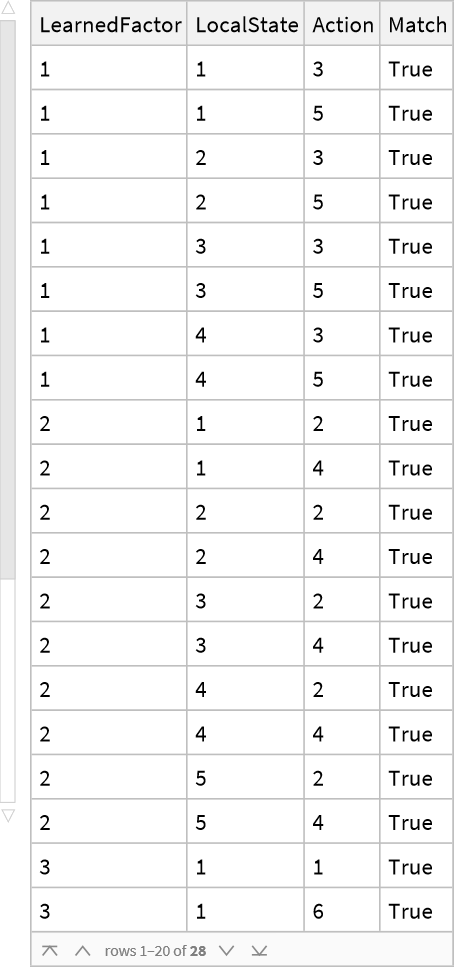

In [223]:
Dataset[
  localTransitionAuditRowsS119A
]

<|TrueJointStates -> 120, HiddenFactorSizesPostHoc -> {3, 5, 4, 2}, 
 
>   InferredFactors -> 4, LocalStateCounts -> {4, 5, 2, 3}, StoredLocalStates -> 14, 
 
>   ProductCapacity -> 120, TrainingJointStates -> 11, 
 
>   TrainingCoveragePercent -> 9.16667, MultiFactorTrainingStates -> 0, 
 
>   UnseenCombinations -> 109, UnseenTouchedBeforeFreeze -> 0, MembershipQueries -> 950, 
 
>   UnseenCombinationAccuracy -> 1., UnseenTransitionAccuracy -> 1., 
 
>   RandomMixedAccuracy -> 1., AllJointAccuracy -> 1., ProbePartitionExact -> True, 
 
>   ActionPartitionExact -> True, LocalStateBijection -> True, 
 
>   LocalTransitionMatches -> 28, LocalTransitionTotal -> 28, 
 
>   StateStorageCompression -> 8.57143, TransitionCompression -> 34.2857, 
 
>   CombinedTableCompression -> 32.1951, ExactFactorizedIsomorphism -> True, 
 
>   AllFiniteSequenceEquivalent -> True, ProspectiveStrong -> True, 
 
>   Diagnosis -> S119A_SUCCESS_FACTOR_DISCOVERY_RECOVERS_THE_HIDDEN_PRODUCT_STRUCTURE_AN\
 
>     D_GENERALIZES_TO_UNSEEN_JOINT_COMBINATIONS_WITHOUT_ENUMERATING_THE_JOINT_STATE_SPA\
 
>     CE|>
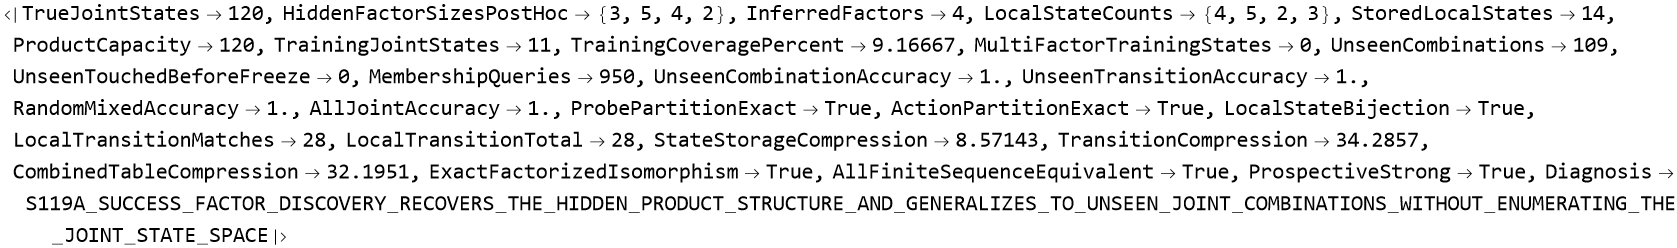

In [228]:
<|

  "TrueJointStates" ->
    trueJointStateCountS119A,

  "HiddenFactorSizesPostHoc" ->
    hiddenFactorSizesS119A,

  "InferredFactors" ->
    inferredFactorCountS119A,

  "LocalStateCounts" ->
    learnedLocalStateCountsS119A,

  "StoredLocalStates" ->
    storedLocalStatesS119A,

  "ProductCapacity" ->
    factorizedJointCapacityS119A,

  "TrainingJointStates" ->
    trainingJointStateCountPostHocS119A,

  "TrainingCoveragePercent" ->
    100. trainingJointCoverageFractionS119A,

  "MultiFactorTrainingStates" ->
    multiFactorTrainingStateCountS119A,

  "UnseenCombinations" ->
    Length[
      prospectiveUnseenCombinationHoldoutS119A
    ],

  "UnseenTouchedBeforeFreeze" ->
    unseenHoldoutTouchedBeforeFreezeS119A,

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS119A,

  "UnseenCombinationAccuracy" ->
    unseenCombinationAccuracyS119A,

  "UnseenTransitionAccuracy" ->
    unseenTransitionAccuracyS119A,

  "RandomMixedAccuracy" ->
    randomHoldoutAccuracyS119A,

  "AllJointAccuracy" ->
    allJointCombinationAccuracyS119A,

  "ProbePartitionExact" ->
    factorProbePartitionExactS119A,

  "ActionPartitionExact" ->
    factorActionPartitionExactS119A,

  "LocalStateBijection" ->
    localStateBijectionPassedS119A,

  "LocalTransitionMatches" ->
    localTransitionMatchesS119A,

  "LocalTransitionTotal" ->
    localTransitionTotalS119A,

  "StateStorageCompression" ->
    stateStorageCompressionS119A,

  "TransitionCompression" ->
    transitionTableCompressionS119A,

  "CombinedTableCompression" ->
    combinedTableCompressionS119A,

  "ExactFactorizedIsomorphism" ->
    exactFactorizedIsomorphismS119A,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS119A,

  "ProspectiveStrong" ->
    prospectiveStrongS119A,

  "Diagnosis" ->
    diagnosisS119A

|>

In [233]:
(* ============================================================ *)
(* S119B                                                        *)
(* SPARSE COUPLED FACTOR / INTERACTION-GRAPH DISCOVERY          *)
(* ============================================================ *)
(*                                                              *)
(* HIDDEN WORLD                                                 *)
(* ------------------------------------------------------------ *)
(* 4 latent factors with sizes = random permutation {2,3,4,5}.  *)
(* Joint capacity = 120.                                        *)
(*                                                              *)
(* Every public action modifies exactly ONE target factor.      *)
(* Therefore factor action-support remains locally identifiable.*)
(*                                                              *)
(* BUT two target actions have context-dependent transitions:   *)
(*                                                              *)
(*       ParentFactor -> TargetFactor                            *)
(*                                                              *)
(* The action's destination depends on the CURRENT value of     *)
(* another factor.                                              *)
(*                                                              *)
(* Example hidden rule:                                         *)
(*                                                              *)
(*   if parent == 0: target += 1                                *)
(*   else:           target += 2                                *)
(*                                                              *)
(* The learner is NOT given:                                    *)
(* - factor count                                               *)
(* - factor sizes                                               *)
(* - action grouping                                            *)
(* - probe grouping                                             *)
(* - coupled actions                                            *)
(* - parent factors                                             *)
(* - interaction graph                                         *)
(* - joint state table                                          *)
(*                                                              *)
(* Learner sees binary final probe outputs only.                *)
(*                                                              *)
(* TRAINING                                                     *)
(* ------------------------------------------------------------ *)
(* 1. infer latent factors from intervention support            *)
(* 2. learn baseline local machines                             *)
(* 3. actively vary one candidate context factor at a time      *)
(* 4. discover context-dependent transition edges               *)
(* 5. learn sparse conditional local transition tables          *)
(*                                                              *)
(* Training intentionally uses at most TWO simultaneously       *)
(* non-zero latent factors.                                     *)
(*                                                              *)
(* PROSPECTIVE HOLDOUT                                          *)
(* ------------------------------------------------------------ *)
(* All joint states having >=3 non-zero factors are sealed      *)
(* before learning.                                             *)
(*                                                              *)
(* The frozen model must generalize its sparse interaction      *)
(* rules to those never-seen 3/4-factor combinations.           *)
(* ============================================================ *)


ClearAll["Global`S119B*"];
ClearAll["Global`s119B*"];


s119BResult =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S119BFail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S119B_STOP"];
);


Print["================================================"];
Print["S119B SPARSE COUPLED FACTOR DISCOVERY"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC INTERFACE                                          *)
(* ============================================================ *)

publicActionsS119B =
  Range[0, 7];


publicProbesS119B =
  Range[0, 13];


Print[
  "Public actions = ",
  publicActionsS119B
];


Print[
  "Public binary probes = ",
  publicProbesS119B
];


Print["NO FACTOR COUNT GIVEN."];
Print["NO FACTOR CARDINALITIES GIVEN."];
Print["NO ACTION/PROBE GROUPINGS GIVEN."];
Print["NO INTERACTION GRAPH GIVEN."];
Print["NO COUPLED ACTIONS IDENTIFIED TO LEARNER."];
Print["LEARNER RECEIVES FINAL BINARY PROBE OUTPUTS ONLY."];


(* ============================================================ *)
(* 2. FREEZE DISCOVERY POLICY BEFORE WORLD GENERATION           *)
(* ============================================================ *)

supportScanDepthS119B =
  8;


localBFSSafetyS119B =
  128;


preparationBFSSafetyS119B =
  256;


discoveryPolicySpecS119B =
  <|

    "Actions" ->
      publicActionsS119B,

    "Probes" ->
      publicProbesS119B,

    "SupportScanDepth" ->
      supportScanDepthS119B,

    "FactorRule" ->
      "EqualObservedProbeSupport",

    "LocalLearning" ->
      "BFSAtBaselineContext",

    "InteractionDiscovery" ->
      "OneCandidateContextFactorAtATime",

    "TransitionRepresentation" ->
      "SparseConditionalLocalTable",

    "MaximumTrainingInteractionOrder" ->
      2

  |>;


frozenDiscoveryPolicyHashS119B =
  Hash[
    discoveryPolicySpecS119B,
    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S119B POLICY FROZEN"];


Print[
  "Support scan depth = ",
  supportScanDepthS119B
];


Print[
  "Policy hash = ",
  frozenDiscoveryPolicyHashS119B
];


Print["HIDDEN COUPLED WORLD DOES NOT EXIST YET."];
Print["================================================"];


(* ============================================================ *)
(* 3. GENERATE HIDDEN SPARSELY COUPLED WORLD                    *)
(* ============================================================ *)

hiddenBenchmarkSeedS119B =
  1194701;


hiddenFactorSizesS119B =
BlockRandom[

  SeedRandom[
    hiddenBenchmarkSeedS119B
  ];

  RandomSample[
    {2, 3, 4, 5}
  ]

];


hiddenTrueFactorCountS119B =
  Length[
    hiddenFactorSizesS119B
  ];


(* ------------------------------------------------------------ *)
(* Choose the size-2 and size-3 factors as SOURCE factors.      *)
(* Choose size-4 and size-5 factors as TARGET factors.          *)
(*                                                              *)
(* This guarantees the +1 vs +2 conditional transition is       *)
(* behaviorally distinguishable in the coupled targets.         *)
(* ------------------------------------------------------------ *)

hiddenSourceFactorsS119B =
  Flatten[
    Position[
      hiddenFactorSizesS119B,
      2 | 3
    ]
  ];


hiddenTargetFactorsS119B =
  Flatten[
    Position[
      hiddenFactorSizesS119B,
      4 | 5
    ]
  ];


hiddenSourceFactorsS119B =
BlockRandom[

  SeedRandom[
    hiddenBenchmarkSeedS119B + 1
  ];

  RandomSample[
    hiddenSourceFactorsS119B
  ]

];


hiddenTargetFactorsS119B =
BlockRandom[

  SeedRandom[
    hiddenBenchmarkSeedS119B + 2
  ];

  RandomSample[
    hiddenTargetFactorsS119B
  ]

];


hiddenCouplingPairsS119B =
  Thread[
    hiddenSourceFactorsS119B ->
      hiddenTargetFactorsS119B
  ];


(* ------------------------------------------------------------ *)
(* Two actions per factor: + and -.                             *)
(*                                                              *)
(* The + action on each TARGET is coupled to its source.        *)
(* All other actions are independent.                           *)
(*                                                              *)
(* Action role record:                                          *)
(*                                                              *)
(* {TargetFactor, Direction, ParentFactor}                       *)
(*                                                              *)
(* ParentFactor == 0 means context-independent.                 *)
(* ------------------------------------------------------------ *)

hiddenActionRolePoolS119B =
  Flatten[
    Table[

      Module[
        {
          parentForPlus
        },


        parentForPlus =
          Lookup[
            Association[
              Reverse /@
                hiddenCouplingPairsS119B
            ],
            factorIndex,
            0
          ];


        {
          {
            factorIndex,
            1,
            parentForPlus
          },

          {
            factorIndex,
            -1,
            0
          }
        }

      ],

      {
        factorIndex,
        1,
        hiddenTrueFactorCountS119B
      }
    ],

    1
  ];


hiddenActionRolePermutationS119B =
BlockRandom[

  SeedRandom[
    hiddenBenchmarkSeedS119B + 3
  ];

  RandomSample[
    hiddenActionRolePoolS119B
  ]

];


hiddenActionRolesS119B =
  AssociationThread[
    publicActionsS119B ->
      hiddenActionRolePermutationS119B
  ];


(* ------------------------------------------------------------ *)
(* Probe role: {Factor, Value}.                                 *)
(* ------------------------------------------------------------ *)

hiddenProbeRolePoolS119B =
  Flatten[
    Table[

      Table[
        {
          factorIndex,
          value
        },

        {
          value,
          0,
          hiddenFactorSizesS119B[[factorIndex]] - 1
        }
      ],

      {
        factorIndex,
        1,
        hiddenTrueFactorCountS119B
      }
    ],

    1
  ];


hiddenProbeRolePermutationS119B =
BlockRandom[

  SeedRandom[
    hiddenBenchmarkSeedS119B + 4
  ];

  RandomSample[
    hiddenProbeRolePoolS119B
  ]

];


hiddenProbeRolesS119B =
  AssociationThread[
    publicProbesS119B ->
      hiddenProbeRolePermutationS119B
  ];


hiddenStartStateS119B =
  ConstantArray[
    0,
    hiddenTrueFactorCountS119B
  ];


(* ============================================================ *)
(* 4. HIDDEN ENVIRONMENT                                        *)
(* ============================================================ *)

S119BEnvStep[
  state_List,
  action_Integer
] :=
Module[
  {
    role,
    targetFactor,
    direction,
    parentFactor,
    targetSize,
    delta,
    nextState
  },


  role =
    Lookup[
      hiddenActionRolesS119B,
      action,
      Missing[
        "UnknownAction"
      ]
    ];


  If[
    !ListQ[
      role
    ],

    Missing[
      "UnknownAction"
    ],


    targetFactor =
      role[[1]];


    direction =
      role[[2]];


    parentFactor =
      role[[3]];


    targetSize =
      hiddenFactorSizesS119B[[
        targetFactor
      ]];


    delta =
      Which[

        parentFactor == 0,

          direction,


        direction == 1 &&
        state[[parentFactor]] == 0,

          1,


        direction == 1 &&
        state[[parentFactor]] =!= 0,

          2,


        True,

          direction
      ];


    nextState =
      state;


    nextState[[
      targetFactor
    ]] =
      Mod[
        nextState[[
          targetFactor
        ]] + delta,
        targetSize
      ];


    nextState
  ]
];


S119BEnvStateAfter[
  seq_List
] :=
  Fold[
    S119BEnvStep,
    hiddenStartStateS119B,
    seq
  ];


S119BEnvRawOutput[
  seq_List,
  probe_Integer
] :=
Module[
  {
    state,
    role,
    factorIndex,
    value
  },


  state =
    S119BEnvStateAfter[
      seq
    ];


  role =
    Lookup[
      hiddenProbeRolesS119B,
      probe,
      Missing[
        "UnknownProbe"
      ]
    ];


  If[
    !ListQ[state] ||
    !ListQ[role],

    Missing[
      "EnvironmentFailure"
    ],


    factorIndex =
      role[[1]];


    value =
      role[[2]];


    Boole[
      state[[factorIndex]] ===
        value
    ]
  ]
];


Print["NEW HIDDEN SPARSELY COUPLED WORLD GENERATED."];
Print["Factor sizes / action roles / interaction graph remain sealed."];


(* ============================================================ *)
(* 5. EVALUATOR-ONLY INDEPENDENT PREPARATION ACTIONS            *)
(*                                                              *)
(* Every - action is context-independent.                       *)
(* Used ONLY to construct sealed holdout sequences.             *)
(* Learner never receives this mapping.                         *)
(* ============================================================ *)

hiddenIndependentMinusActionByFactorS119B =
  Association[
    Table[

      factorIndex ->

        SelectFirst[
          publicActionsS119B,

          Function[
            action,

            Lookup[
              hiddenActionRolesS119B,
              action
            ] ===
              {
                factorIndex,
                -1,
                0
              }
          ]
        ],

      {
        factorIndex,
        1,
        hiddenTrueFactorCountS119B
      }
    ]
  ];


S119BEvaluatorCanonicalSequence[
  tuple_List
] :=
  Flatten[
    Table[

      ConstantArray[

        Lookup[
          hiddenIndependentMinusActionByFactorS119B,
          factorIndex
        ],

        Mod[
          -tuple[[factorIndex]],
          hiddenFactorSizesS119B[[factorIndex]]
        ]
      ],

      {
        factorIndex,
        1,
        hiddenTrueFactorCountS119B
      }
    ],

    1
  ];


allTrueJointTuplesS119B =
  Tuples[
    Map[
      Range[
        0,
        # - 1
      ] &,
      hiddenFactorSizesS119B
    ]
  ];


trueJointStateCountS119B =
  Length[
    allTrueJointTuplesS119B
  ];


(* ============================================================ *)
(* 6. PROSPECTIVE HIGH-ORDER COMPOSITION HOLDOUT                *)
(*                                                              *)
(* Hold out every state with >=3 non-zero factors.              *)
(*                                                              *)
(* Training will use at most pairwise contexts.                 *)
(* ============================================================ *)

prospectiveHighOrderTuplesS119B =
  Select[
    allTrueJointTuplesS119B,

    Count[
      #,
      Except[0]
    ] >= 3 &
  ];


prospectiveHighOrderHoldoutS119B =
  Table[

    <|

      "TupleEvaluatorOnly" ->
        tuple,

      "Sequence" ->
        S119BEvaluatorCanonicalSequence[
          tuple
        ]

    |>,

    {
      tuple,
      prospectiveHighOrderTuplesS119B
    }
  ];


Print[
  "True joint states = ",
  trueJointStateCountS119B
];


Print[
  "Prospective >=3-factor unseen combinations = ",
  Length[
    prospectiveHighOrderHoldoutS119B
  ]
];


Print["HIGH-ORDER HOLDOUT OUTPUTS REMAIN SEALED."];


(* ============================================================ *)
(* 7. RANDOM LONG MIXED HOLDOUT                                 *)
(* ============================================================ *)

randomHoldoutSeedS119B =
  1194702;


randomHoldoutDepthsS119B =
  {
    50,
    100,
    250
  };


randomHoldoutPerDepthCountS119B =
  100;


prospectiveRandomHoldoutS119B =
BlockRandom[

  SeedRandom[
    randomHoldoutSeedS119B
  ];


  Flatten[
    Table[

      Table[

        <|

          "Depth" ->
            depth,

          "Sequence" ->
            RandomChoice[
              publicActionsS119B,
              depth
            ]

        |>,

        {
          randomHoldoutPerDepthCountS119B
        }
      ],

      {
        depth,
        randomHoldoutDepthsS119B
      }
    ],

    1
  ]
];


Print[
  "Prospective random mixed holdout = ",
  Length[
    prospectiveRandomHoldoutS119B
  ]
];


(* ============================================================ *)
(* 8. MEMBERSHIP INTERFACE                                      *)
(* ============================================================ *)

membershipCacheS119B =
  <||>;


membershipUniqueCountS119B =
  0;


membershipNewBySourceS119B =
  <|

    "SupportScan" -> 0,

    "LocalBFS" -> 0,

    "InteractionScan" -> 0,

    "ConditionalTable" -> 0,

    "HighOrderHoldout" -> 0,

    "RandomHoldout" -> 0,

    "Audit" -> 0

  |>;


queriedSequenceRegistryS119B =
  <||>;


S119BSeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S119BQueryKey[
  seq_List,
  probe_Integer
] :=
  ToString[
    InputForm[
      {
        seq,
        probe
      }
    ]
  ];


S119BMembershipY[
  seq_List,
  probe_Integer,
  source_String : "SupportScan"
] :=
Module[
  {
    key,
    seqKey,
    y,
    oldCount
  },


  key =
    S119BQueryKey[
      seq,
      probe
    ];


  seqKey =
    S119BSeqKey[
      seq
    ];


  If[
    !KeyExistsQ[
      queriedSequenceRegistryS119B,
      seqKey
    ],

    AssociateTo[
      queriedSequenceRegistryS119B,
      seqKey -> seq
    ];
  ];


  If[
    KeyExistsQ[
      membershipCacheS119B,
      key
    ],

    Lookup[
      membershipCacheS119B,
      key
    ],


    y =
      S119BEnvRawOutput[
        seq,
        probe
      ];


    If[
      !MemberQ[
        {0, 1},
        y
      ],

      S119BFail[
        "Membership oracle returned non-binary output."
      ]
    ];


    membershipUniqueCountS119B++;


    AssociateTo[
      membershipCacheS119B,
      key -> y
    ];


    oldCount =
      Lookup[
        membershipNewBySourceS119B,
        source,
        0
      ];


    AssociateTo[
      membershipNewBySourceS119B,
      source -> (oldCount + 1)
    ];


    y
  ]
];


S119BObserveSignature[
  seq_List,
  probes_List,
  source_String
] :=
  Table[

    S119BMembershipY[
      seq,
      probe,
      source
    ],

    {
      probe,
      probes
    }
  ];


S119BSignatureKey[
  signature_List
] :=
  ToString[
    InputForm[
      signature
    ]
  ];


(* ============================================================ *)
(* 9. FACTOR SUPPORT DISCOVERY                                  *)
(* ============================================================ *)

Print["================================================"];
Print["S119B FACTOR SUPPORT DISCOVERY"];
Print["================================================"];


baselineSignatureS119B =
  S119BObserveSignature[
    {},
    publicProbesS119B,
    "SupportScan"
  ];


actionSupportRowsS119B =
  Table[

    Module[
      {
        scanSignatures,
        changedPositions,
        support
      },


      scanSignatures =
        Table[

          S119BObserveSignature[
            ConstantArray[
              action,
              repetition
            ],
            publicProbesS119B,
            "SupportScan"
          ],

          {
            repetition,
            1,
            supportScanDepthS119B
          }
        ];


      changedPositions =
        Select[
          Range[
            Length[
              publicProbesS119B
            ]
          ],

          Function[
            position,

            AnyTrue[
              scanSignatures,

              Function[
                signature,

                signature[[position]] =!=
                  baselineSignatureS119B[[position]]
              ]
            ]
          ]
        ];


      support =
        publicProbesS119B[[
          changedPositions
        ]];


      <|

        "Action" ->
          action,

        "ObservedProbeSupport" ->
          Sort[
            support
          ],

        "SupportSize" ->
          Length[
            support
          ]

      |>

    ],

    {
      action,
      publicActionsS119B
    }
  ];


If[
  AnyTrue[
    actionSupportRowsS119B,

    Length[
      #[
        "ObservedProbeSupport"
      ]
    ] == 0 &
  ],

  S119BFail[
    "At least one action produced empty factor support."
  ]
];


supportGroupsS119B =
  Values[
    GroupBy[
      actionSupportRowsS119B,

      Function[
        row,
        ToString[
          InputForm[
            row[
              "ObservedProbeSupport"
            ]
          ]
        ]
      ]
    ]
  ];


factorDescriptorsS119B =
  Table[

    <|

      "Probes" ->
        Sort[
          supportGroupsS119B[[groupIndex, 1]][
            "ObservedProbeSupport"
          ]
        ],

      "Actions" ->
        Sort[
          (
            #[
              "Action"
            ] &
          ) /@
            supportGroupsS119B[[groupIndex]]
        ]

    |>,

    {
      groupIndex,
      1,
      Length[
        supportGroupsS119B
      ]
    }
  ];


factorDescriptorsS119B =
  SortBy[
    factorDescriptorsS119B,
    First[
      #[
        "Probes"
      ]
    ] &
  ];


factorDescriptorsS119B =
  Table[

    Join[
      factorDescriptorsS119B[[factorIndex]],

      <|
        "LearnedFactor" ->
          factorIndex
      |>
    ],

    {
      factorIndex,
      1,
      Length[
        factorDescriptorsS119B
      ]
    }
  ];


inferredFactorCountS119B =
  Length[
    factorDescriptorsS119B
  ];


learnedProbeGroupsS119B =
  (
    #[
      "Probes"
    ] &
  ) /@
    factorDescriptorsS119B;


learnedActionGroupsS119B =
  (
    #[
      "Actions"
    ] &
  ) /@
    factorDescriptorsS119B;


Print[
  "Inferred factors = ",
  inferredFactorCountS119B
];


Print[
  "Probe-group sizes = ",
  Length /@
    learnedProbeGroupsS119B
];


Print[
  "Action-group sizes = ",
  Length /@
    learnedActionGroupsS119B
];


(* ============================================================ *)
(* 10. LEARN BASELINE LOCAL MACHINES                            *)
(* ============================================================ *)

S119BLocalTransitionKey[
  state_Integer,
  action_Integer
] :=
  ToString[
    InputForm[
      {
        state,
        action
      }
    ]
  ];


S119BLearnLocalFactor[
  descriptor_Association
] :=
Module[
  {
    probes,
    actions,
    startSignature,
    signatureToState,
    stateSignatures,
    representatives,
    transitions,
    queue,
    currentState,
    currentRep,
    nextSeq,
    nextSignature,
    nextKey,
    nextState,
    newState,
    guard
  },


  probes =
    descriptor[
      "Probes"
    ];


  actions =
    descriptor[
      "Actions"
    ];


  startSignature =
    S119BObserveSignature[
      {},
      probes,
      "LocalBFS"
    ];


  signatureToState =
    Association[
      S119BSignatureKey[
        startSignature
      ] -> 1
    ];


  stateSignatures =
    <|
      1 -> startSignature
    |>;


  representatives =
    <|
      1 -> {}
    |>;


  transitions =
    <||>;


  queue =
    {1};


  guard =
    0;


  While[
    Length[
      queue
    ] > 0,


    guard++;


    If[
      guard >
        localBFSSafetyS119B,

      S119BFail[
        "Local BFS safety guard exceeded."
      ]
    ];


    currentState =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    currentRep =
      Lookup[
        representatives,
        currentState
      ];


    Do[

      nextSeq =
        Append[
          currentRep,
          action
        ];


      nextSignature =
        S119BObserveSignature[
          nextSeq,
          probes,
          "LocalBFS"
        ];


      nextKey =
        S119BSignatureKey[
          nextSignature
        ];


      If[
        KeyExistsQ[
          signatureToState,
          nextKey
        ],

        nextState =
          Lookup[
            signatureToState,
            nextKey
          ],


        newState =
          Length[
            stateSignatures
          ] + 1;


        nextState =
          newState;


        AssociateTo[
          signatureToState,
          nextKey -> newState
        ];


        AssociateTo[
          stateSignatures,
          newState -> nextSignature
        ];


        AssociateTo[
          representatives,
          newState -> nextSeq
        ];


        AppendTo[
          queue,
          newState
        ];
      ];


      AssociateTo[
        transitions,

        S119BLocalTransitionKey[
          currentState,
          action
        ] ->
          nextState
      ],

      {
        action,
        actions
      }
    ];

  ];


  <|

    "LearnedFactor" ->
      descriptor[
        "LearnedFactor"
      ],

    "Probes" ->
      probes,

    "Actions" ->
      actions,

    "StateCount" ->
      Length[
        stateSignatures
      ],

    "StateSignatures" ->
      stateSignatures,

    "RepresentativeByState" ->
      representatives,

    "TransitionsAtBaseline" ->
      transitions,

    "StartState" ->
      1,

    "ObservedOneHot" ->
      AllTrue[
        Values[
          stateSignatures
        ],
        Total[#] === 1 &
      ]

  |>
];


learnedFactorsS119B =
  S119BLearnLocalFactor /@
    factorDescriptorsS119B;


learnedLocalStateCountsS119B =
  (
    #[
      "StateCount"
    ] &
  ) /@
    learnedFactorsS119B;


Print["================================================"];
Print["BASELINE LOCAL FACTORS DISCOVERED"];


Print[
  "Local state counts = ",
  learnedLocalStateCountsS119B
];


Print[
  "Stored local states = ",
  Total[
    learnedLocalStateCountsS119B
  ]
];


Print[
  "Product capacity = ",
  Times @@
    learnedLocalStateCountsS119B
];


Print["================================================"];


(* ============================================================ *)
(* 11. ACTION / PROBE -> LEARNED FACTOR                         *)
(* ============================================================ *)

actionToLearnedFactorS119B =
  Association[
    Flatten[
      Table[

        Table[
          action -> factorIndex,

          {
            action,
            learnedFactorsS119B[[factorIndex]][
              "Actions"
            ]
          }
        ],

        {
          factorIndex,
          1,
          Length[
            learnedFactorsS119B
          ]
        }
      ]
    ]
  ];


probeToLearnedFactorS119B =
  Association[
    Flatten[
      Table[

        Table[
          probe -> factorIndex,

          {
            probe,
            learnedFactorsS119B[[factorIndex]][
              "Probes"
            ]
          }
        ],

        {
          factorIndex,
          1,
          Length[
            learnedFactorsS119B
          ]
        }
      ]
    ]
  ];


(* ============================================================ *)
(* 12. MAP OBSERVED LOCAL SIGNATURE -> LEARNED LOCAL STATE      *)
(* ============================================================ *)

S119BLocalStateFromSignature[
  factorIndex_Integer,
  signature_List
] :=
  SelectFirst[
    Range[
      learnedFactorsS119B[[factorIndex]][
        "StateCount"
      ]
    ],

    Function[
      localState,

      Lookup[
        learnedFactorsS119B[[factorIndex]][
          "StateSignatures"
        ],
        localState
      ] ===
        signature
    ],

    Missing[
      "UnknownLocalSignature"
    ]
  ];


(* ============================================================ *)
(* 13. ACTIVE STATE PREPARATION UNDER CURRENT CONTEXT           *)
(*                                                              *)
(* Critical for interaction discovery:                          *)
(*                                                              *)
(* A factor's transition may depend on another factor, so a     *)
(* baseline representative is NOT blindly reused in a new       *)
(* context.                                                     *)
(*                                                              *)
(* Instead, BFS over that factor's public actions until the     *)
(* desired observed local state is reached.                     *)
(*                                                              *)
(* Because actions modify only their target factor, previously  *)
(* prepared factors remain unchanged.                           *)
(* ============================================================ *)

S119BPrepareFactorState[
  baseSequence_List,
  factorIndex_Integer,
  desiredLocalState_Integer,
  source_String
] :=
Module[
  {
    result,
    probes,
    actions,
    desiredSignature
  },


  probes =
    learnedFactorsS119B[[factorIndex]][
      "Probes"
    ];


  actions =
    learnedFactorsS119B[[factorIndex]][
      "Actions"
    ];


  desiredSignature =
    Lookup[
      learnedFactorsS119B[[factorIndex]][
        "StateSignatures"
      ],
      desiredLocalState
    ];


  result =
    Catch[

      Module[
        {
          startSignature,
          queue,
          visited,
          current,
          currentSequence,
          currentSignature,
          nextSequence,
          nextSignature,
          nextKey,
          guard
        },


        startSignature =
          S119BObserveSignature[
            baseSequence,
            probes,
            source
          ];


        If[
          startSignature ===
            desiredSignature,

          Throw[
            baseSequence,
            "S119B_PREPARED"
          ];
        ];


        queue =
          {
            {
              baseSequence,
              startSignature
            }
          };


        visited =
          <|
            S119BSignatureKey[
              startSignature
            ] -> True
          |>;


        guard =
          0;


        While[
          Length[
            queue
          ] > 0,


          guard++;


          If[
            guard >
              preparationBFSSafetyS119B,

            Throw[
              $Failed,
              "S119B_PREPARED"
            ];
          ];


          current =
            First[
              queue
            ];


          queue =
            Rest[
              queue
            ];


          currentSequence =
            current[[1]];


          currentSignature =
            current[[2]];


          Do[

            nextSequence =
              Append[
                currentSequence,
                action
              ];


            nextSignature =
              S119BObserveSignature[
                nextSequence,
                probes,
                source
              ];


            If[
              nextSignature ===
                desiredSignature,

              Throw[
                nextSequence,
                "S119B_PREPARED"
              ];
            ];


            nextKey =
              S119BSignatureKey[
                nextSignature
              ];


            If[
              !KeyExistsQ[
                visited,
                nextKey
              ],

              AssociateTo[
                visited,
                nextKey -> True
              ];


              AppendTo[
                queue,
                {
                  nextSequence,
                  nextSignature
                }
              ];
            ],

            {
              action,
              actions
            }
          ];

        ];


        $Failed
      ],

      "S119B_PREPARED"
    ];


  If[
    result === $Failed,

    S119BFail[
      "Could not actively prepare requested local factor state."
    ],

    result
  ]
];


(* ============================================================ *)
(* 14. PREPARE A SET OF LOCAL FACTOR STATES                     *)
(* ============================================================ *)

S119BPrepareContext[
  assignments_List,
  source_String
] :=
Module[
  {
    seq
  },


  seq =
    {};


  Do[

    seq =
      S119BPrepareFactorState[
        seq,
        assignment[[1]],
        assignment[[2]],
        source
      ],

    {
      assignment,
      assignments
    }
  ];


  seq
];


(* ============================================================ *)
(* 15. INTERACTION DISCOVERY                                    *)
(*                                                              *)
(* For every action a targeting factor T:                       *)
(*                                                              *)
(* vary every other candidate factor P independently.           *)
(*                                                              *)
(* Hold T at local state t, vary P across its local states,     *)
(* apply a, and observe destination of T.                        *)
(*                                                              *)
(* If destination changes as P changes:                         *)
(*                                                              *)
(*          P ->(action a)-> T                                  *)
(*                                                              *)
(* is a learned interaction dependency.                         *)
(* ============================================================ *)

Print["================================================"];
Print["ACTIVE PAIRWISE INTERACTION DISCOVERY"];
Print["================================================"];


interactionScanRowsS119B =
  Flatten[
    Table[

      Module[
        {
          targetFactor,
          seq,
          nextSeq,
          targetSignature,
          destinationState
        },


        targetFactor =
          Lookup[
            actionToLearnedFactorS119B,
            action
          ];


        seq =
          S119BPrepareContext[
            {
              {
                targetFactor,
                targetState
              },

              {
                candidateParent,
                parentState
              }
            },
            "InteractionScan"
          ];


        nextSeq =
          Append[
            seq,
            action
          ];


        targetSignature =
          S119BObserveSignature[
            nextSeq,
            learnedFactorsS119B[[targetFactor]][
              "Probes"
            ],
            "InteractionScan"
          ];


        destinationState =
          S119BLocalStateFromSignature[
            targetFactor,
            targetSignature
          ];


        If[
          !IntegerQ[
            destinationState
          ],

          S119BFail[
            "Interaction scan reached an unknown local target signature."
          ]
        ];


        <|

          "Action" ->
            action,

          "TargetFactor" ->
            targetFactor,

          "CandidateParent" ->
            candidateParent,

          "TargetState" ->
            targetState,

          "ParentState" ->
            parentState,

          "DestinationState" ->
            destinationState

        |>

      ],

      {
        action,
        publicActionsS119B
      },

      {
        candidateParent,
        DeleteCases[
          Range[
            inferredFactorCountS119B
          ],
          Lookup[
            actionToLearnedFactorS119B,
            action
          ]
        ]
      },

      {
        targetState,
        Range[
          learnedFactorsS119B[[
            Lookup[
              actionToLearnedFactorS119B,
              action
            ]
          ]][
            "StateCount"
          ]
        ]
      },

      {
        parentState,
        Range[
          learnedFactorsS119B[[
            candidateParent
          ]][
            "StateCount"
          ]
        ]
      }
    ],

    3
  ];


S119BDependencyDetectedQ[
  action_Integer,
  candidateParent_Integer
] :=
Module[
  {
    rows,
    targetFactor,
    targetStateCount
  },


  rows =
    Select[
      interactionScanRowsS119B,

      And[
        #["Action"] === action,
        #["CandidateParent"] ===
          candidateParent
      ] &
    ];


  targetFactor =
    Lookup[
      actionToLearnedFactorS119B,
      action
    ];


  targetStateCount =
    learnedFactorsS119B[[targetFactor]][
      "StateCount"
    ];


  AnyTrue[
    Range[
      targetStateCount
    ],

    Function[
      targetState,

      Length[
        DeleteDuplicates[
          (
            #[
              "DestinationState"
            ] &
          ) /@
            Select[
              rows,
              #["TargetState"] ===
                targetState &
            ]
        ]
      ] > 1
    ]
  ]
];


learnedParentsByActionS119B =
  Association[
    Table[

      action ->

        Sort[
          Select[
            DeleteCases[
              Range[
                inferredFactorCountS119B
              ],
              Lookup[
                actionToLearnedFactorS119B,
                action
              ]
            ],

            S119BDependencyDetectedQ[
              action,
              #
            ] &
          ]
        ],

      {
        action,
        publicActionsS119B
      }
    ]
  ];


learnedInteractionEdgesS119B =
  DeleteDuplicates[
    Flatten[
      Table[

        Module[
          {
            targetFactor
          },


          targetFactor =
            Lookup[
              actionToLearnedFactorS119B,
              action
            ];


          Table[
            parent ->
              targetFactor,

            {
              parent,
              Lookup[
                learnedParentsByActionS119B,
                action
              ]
            }
          ]

        ],

        {
          action,
          publicActionsS119B
        }
      ],

      1
    ]
  ];


Print[
  "Learned parents by action = ",
  learnedParentsByActionS119B
];


Print[
  "Learned interaction edges = ",
  learnedInteractionEdgesS119B
];


(* ============================================================ *)
(* 16. LEARN SPARSE CONDITIONAL TRANSITION TABLES               *)
(* ============================================================ *)

S119BConditionalTransitionKey[
  action_Integer,
  targetState_Integer,
  parentStates_List
] :=
  ToString[
    InputForm[
      {
        action,
        targetState,
        parentStates
      }
    ]
  ];


conditionalTransitionsS119B =
  <||>;


conditionalTransitionRowsS119B =
  {};


Do[

  Module[
    {
      targetFactor,
      parentFactors,
      parentStateTuples,
      destination,
      seq,
      nextSeq,
      targetSignature,
      assignments
    },


    targetFactor =
      Lookup[
        actionToLearnedFactorS119B,
        action
      ];


    parentFactors =
      Lookup[
        learnedParentsByActionS119B,
        action
      ];


    If[
      Length[
        parentFactors
      ] == 0,


      Do[

        destination =
          Lookup[
            learnedFactorsS119B[[targetFactor]][
              "TransitionsAtBaseline"
            ],

            S119BLocalTransitionKey[
              targetState,
              action
            ]
          ];


        AssociateTo[
          conditionalTransitionsS119B,

          S119BConditionalTransitionKey[
            action,
            targetState,
            {}
          ] ->
            destination
        ];


        AppendTo[
          conditionalTransitionRowsS119B,

          <|

            "Action" ->
              action,

            "TargetFactor" ->
              targetFactor,

            "ParentFactors" ->
              {},

            "TargetState" ->
              targetState,

            "ParentStates" ->
              {},

            "DestinationState" ->
              destination

          |>
        ],

        {
          targetState,
          1,
          learnedFactorsS119B[[targetFactor]][
            "StateCount"
          ]
        }
      ],


      parentStateTuples =
        Tuples[
          Table[
            Range[
              learnedFactorsS119B[[parentFactor]][
                "StateCount"
              ]
            ],

            {
              parentFactor,
              parentFactors
            }
          ]
        ];


      Do[

        Do[

          assignments =
            Join[
              {
                {
                  targetFactor,
                  targetState
                }
              },

              MapThread[
                List,
                {
                  parentFactors,
                  parentStates
                }
              ]
            ];


          seq =
            S119BPrepareContext[
              assignments,
              "ConditionalTable"
            ];


          nextSeq =
            Append[
              seq,
              action
            ];


          targetSignature =
            S119BObserveSignature[
              nextSeq,
              learnedFactorsS119B[[targetFactor]][
                "Probes"
              ],
              "ConditionalTable"
            ];


          destination =
            S119BLocalStateFromSignature[
              targetFactor,
              targetSignature
            ];


          If[
            !IntegerQ[
              destination
            ],

            S119BFail[
              "Conditional transition reached unknown local signature."
            ]
          ];


          AssociateTo[
            conditionalTransitionsS119B,

            S119BConditionalTransitionKey[
              action,
              targetState,
              parentStates
            ] ->
              destination
          ];


          AppendTo[
            conditionalTransitionRowsS119B,

            <|

              "Action" ->
                action,

              "TargetFactor" ->
                targetFactor,

              "ParentFactors" ->
                parentFactors,

              "TargetState" ->
                targetState,

              "ParentStates" ->
                parentStates,

              "DestinationState" ->
                destination

            |>
          ],

          {
            parentStates,
            parentStateTuples
          }
        ],

        {
          targetState,
          1,
          learnedFactorsS119B[[targetFactor]][
            "StateCount"
          ]
        }
      ];
    ];

  ],

  {
    action,
    publicActionsS119B
  }
];


Print["================================================"];
Print["SPARSE CONDITIONAL MODEL LEARNED"];


Print[
  "Conditional transition cells = ",
  Length[
    conditionalTransitionsS119B
  ]
];


Print[
  "Learned interaction edge count = ",
  Length[
    learnedInteractionEdgesS119B
  ]
];


Print["================================================"];


(* ============================================================ *)
(* 17. FACTORIZED COUPLED EXECUTOR                              *)
(* ============================================================ *)

factorizedStartStateS119B =
  (
    #[
      "StartState"
    ] &
  ) /@
    learnedFactorsS119B;


S119BFactorizedStep[
  jointState_List,
  action_Integer
] :=
Module[
  {
    targetFactor,
    parentFactors,
    targetState,
    parentStates,
    destination,
    nextState
  },


  targetFactor =
    Lookup[
      actionToLearnedFactorS119B,
      action,
      Missing[
        "UnknownAction"
      ]
    ];


  If[
    !IntegerQ[
      targetFactor
    ],

    Missing[
      "UnknownAction"
    ],


    parentFactors =
      Lookup[
        learnedParentsByActionS119B,
        action,
        {}
      ];


    targetState =
      jointState[[
        targetFactor
      ]];


    parentStates =
      If[
        Length[
          parentFactors
        ] == 0,

        {},

        jointState[[
          parentFactors
        ]]
      ];


    destination =
      Lookup[
        conditionalTransitionsS119B,

        S119BConditionalTransitionKey[
          action,
          targetState,
          parentStates
        ],

        Missing[
          "UnknownConditionalTransition"
        ]
      ];


    If[
      !IntegerQ[
        destination
      ],

      Missing[
        "UnknownConditionalTransition"
      ],


      nextState =
        jointState;


      nextState[[
        targetFactor
      ]] =
        destination;


      nextState
    ]
  ]
];


S119BFactorizedStateAfter[
  seq_List
] :=
  Fold[

    Function[
      {
        state,
        action
      },

      If[
        ListQ[state],

        S119BFactorizedStep[
          state,
          action
        ],

        state
      ]
    ],

    factorizedStartStateS119B,

    seq
  ];


S119BFactorizedOutput[
  seq_List,
  probe_Integer
] :=
Module[
  {
    state,
    factorIndex,
    localState,
    localSignature,
    probePosition
  },


  state =
    S119BFactorizedStateAfter[
      seq
    ];


  factorIndex =
    Lookup[
      probeToLearnedFactorS119B,
      probe,
      Missing[
        "UnknownProbe"
      ]
    ];


  If[
    !ListQ[state] ||
    !IntegerQ[factorIndex],

    Missing[
      "ModelFailure"
    ],


    localState =
      state[[
        factorIndex
      ]];


    localSignature =
      Lookup[
        learnedFactorsS119B[[factorIndex]][
          "StateSignatures"
        ],
        localState,
        Missing[
          "UnknownState"
        ]
      ];


    probePosition =
      FirstPosition[
        learnedFactorsS119B[[factorIndex]][
          "Probes"
        ],
        probe,
        Missing[
          "UnknownProbe"
        ]
      ];


    If[
      !ListQ[
        localSignature
      ] ||
      MissingQ[
        probePosition
      ],

      Missing[
        "ModelFailure"
      ],

      localSignature[[
        probePosition[[1]]
      ]]
    ]
  ]
];


(* ============================================================ *)
(* 18. PRE-FREEZE LEAKAGE                                       *)
(* ============================================================ *)

highOrderTouchedBeforeFreezeS119B =
  Count[
    prospectiveHighOrderHoldoutS119B,

    row_Association /;

      KeyExistsQ[
        queriedSequenceRegistryS119B,

        S119BSeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


randomHoldoutTouchedBeforeFreezeS119B =
  Count[
    prospectiveRandomHoldoutS119B,

    row_Association /;

      KeyExistsQ[
        queriedSequenceRegistryS119B,

        S119BSeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


trainingSequencesBeforeFreezeS119B =
  Values[
    queriedSequenceRegistryS119B
  ];


membershipQueriesBeforeFreezeS119B =
  membershipUniqueCountS119B;


policyHashUnchangedS119B =
  Hash[
    discoveryPolicySpecS119B,
    "SHA256",
    "HexString"
  ] ===
    frozenDiscoveryPolicyHashS119B;


If[
  !TrueQ[
    policyHashUnchangedS119B
  ],

  S119BFail[
    "Frozen discovery policy changed."
  ]
];


frozenModelHashS119B =
  Hash[
    {
      factorDescriptorsS119B,
      learnedFactorsS119B,
      actionToLearnedFactorS119B,
      learnedParentsByActionS119B,
      conditionalTransitionsS119B,
      factorizedStartStateS119B
    },

    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S119B MODEL FROZEN"];


Print[
  "Factors = ",
  inferredFactorCountS119B
];


Print[
  "Local state counts = ",
  learnedLocalStateCountsS119B
];


Print[
  "Learned interaction edges = ",
  learnedInteractionEdgesS119B
];


Print[
  "Conditional transition cells = ",
  Length[
    conditionalTransitionsS119B
  ]
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS119B
];


Print[
  "High-order holdout touched = ",
  highOrderTouchedBeforeFreezeS119B,
  " / ",
  Length[
    prospectiveHighOrderHoldoutS119B
  ]
];


Print[
  "Random holdout touched = ",
  randomHoldoutTouchedBeforeFreezeS119B,
  " / ",
  Length[
    prospectiveRandomHoldoutS119B
  ]
];


Print[
  "Machine hash = ",
  frozenModelHashS119B
];


Print["NO LEARNED STRUCTURE CHANGES AFTER THIS POINT."];
Print["================================================"];


(* ============================================================ *)
(* 19. OPEN HIGH-ORDER UNSEEN COMBINATIONS                      *)
(* ============================================================ *)

highOrderRowsS119B =
  Table[

    Module[
      {
        seq,
        learnedSignature,
        trueSignature
      },


      seq =
        row[
          "Sequence"
        ];


      learnedSignature =
        Table[

          S119BFactorizedOutput[
            seq,
            probe
          ],

          {
            probe,
            publicProbesS119B
          }
        ];


      trueSignature =
        Table[

          S119BMembershipY[
            seq,
            probe,
            "HighOrderHoldout"
          ],

          {
            probe,
            publicProbesS119B
          }
        ];


      <|

        "TupleEvaluatorOnly" ->
          row[
            "TupleEvaluatorOnly"
          ],

        "ExactMatch" ->
          (
            learnedSignature ===
              trueSignature
          )

      |>

    ],

    {
      row,
      prospectiveHighOrderHoldoutS119B
    }
  ];


highOrderMatchesS119B =
  Count[
    (
      TrueQ[
        #[
          "ExactMatch"
        ]
      ] &
    ) /@
      highOrderRowsS119B,
    True
  ];


highOrderAccuracyS119B =
  N[
    highOrderMatchesS119B /
      Length[
        highOrderRowsS119B
      ]
  ];


Print[
  "High-order unseen combinations exact = ",
  highOrderMatchesS119B,
  " / ",
  Length[
    highOrderRowsS119B
  ]
];


(* ============================================================ *)
(* 20. HIGH-ORDER TRANSITION GENERALIZATION                     *)
(* ============================================================ *)

highOrderTransitionRowsS119B =
  Flatten[
    Table[

      Module[
        {
          seq,
          nextSeq,
          learnedSignature,
          trueSignature
        },


        seq =
          row[
            "Sequence"
          ];


        nextSeq =
          Append[
            seq,
            action
          ];


        learnedSignature =
          Table[

            S119BFactorizedOutput[
              nextSeq,
              probe
            ],

            {
              probe,
              publicProbesS119B
            }
          ];


        trueSignature =
          Table[

            S119BMembershipY[
              nextSeq,
              probe,
              "Audit"
            ],

            {
              probe,
              publicProbesS119B
            }
          ];


        <|

          "Action" ->
            action,

          "ExactMatch" ->
            (
              learnedSignature ===
                trueSignature
            )

        |>

      ],

      {
        row,
        prospectiveHighOrderHoldoutS119B
      },

      {
        action,
        publicActionsS119B
      }
    ],

    1
  ];


highOrderTransitionMatchesS119B =
  Count[
    (
      TrueQ[
        #[
          "ExactMatch"
        ]
      ] &
    ) /@
      highOrderTransitionRowsS119B,
    True
  ];


highOrderTransitionAccuracyS119B =
  N[
    highOrderTransitionMatchesS119B /
      Length[
        highOrderTransitionRowsS119B
      ]
  ];


Print[
  "High-order unseen transitions exact = ",
  highOrderTransitionMatchesS119B,
  " / ",
  Length[
    highOrderTransitionRowsS119B
  ]
];


(* ============================================================ *)
(* 21. RANDOM LONG MIXED HOLDOUT                                *)
(* ============================================================ *)

randomHoldoutRowsS119B =
  Table[

    Module[
      {
        seq,
        learnedSignature,
        trueSignature
      },


      seq =
        row[
          "Sequence"
        ];


      learnedSignature =
        Table[

          S119BFactorizedOutput[
            seq,
            probe
          ],

          {
            probe,
            publicProbesS119B
          }
        ];


      trueSignature =
        Table[

          S119BMembershipY[
            seq,
            probe,
            "RandomHoldout"
          ],

          {
            probe,
            publicProbesS119B
          }
        ];


      <|

        "Depth" ->
          row[
            "Depth"
          ],

        "ExactMatch" ->
          (
            learnedSignature ===
              trueSignature
          )

      |>

    ],

    {
      row,
      prospectiveRandomHoldoutS119B
    }
  ];


randomHoldoutMatchesS119B =
  Count[
    (
      TrueQ[
        #[
          "ExactMatch"
        ]
      ] &
    ) /@
      randomHoldoutRowsS119B,
    True
  ];


randomHoldoutAccuracyS119B =
  N[
    randomHoldoutMatchesS119B /
      Length[
        randomHoldoutRowsS119B
      ]
  ];


randomHoldoutPerDepthS119B =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          randomHoldoutRowsS119B,
          #[
            "Depth"
          ] === depth &
        ];


      matches =
        Count[
          (
            TrueQ[
              #[
                "ExactMatch"
              ]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Depth" ->
          depth,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      depth,
      randomHoldoutDepthsS119B
    }
  ];


Print[
  "Random mixed holdout = ",
  randomHoldoutMatchesS119B,
  " / ",
  Length[
    randomHoldoutRowsS119B
  ]
];


(* ============================================================ *)
(* 22. ALL 120 JOINT STATES POST-FREEZE AUDIT                   *)
(* ============================================================ *)

allJointRowsS119B =
  Table[

    Module[
      {
        seq,
        learnedSignature,
        trueSignature
      },


      seq =
        S119BEvaluatorCanonicalSequence[
          tuple
        ];


      learnedSignature =
        Table[

          S119BFactorizedOutput[
            seq,
            probe
          ],

          {
            probe,
            publicProbesS119B
          }
        ];


      trueSignature =
        Table[

          S119BMembershipY[
            seq,
            probe,
            "Audit"
          ],

          {
            probe,
            publicProbesS119B
          }
        ];


      <|

        "Tuple" ->
          tuple,

        "ExactMatch" ->
          (
            learnedSignature ===
              trueSignature
          )

      |>

    ],

    {
      tuple,
      allTrueJointTuplesS119B
    }
  ];


allJointMatchesS119B =
  Count[
    (
      TrueQ[
        #[
          "ExactMatch"
        ]
      ] &
    ) /@
      allJointRowsS119B,
    True
  ];


allJointAccuracyS119B =
  N[
    allJointMatchesS119B /
      trueJointStateCountS119B
  ];


Print[
  "All joint states exact = ",
  allJointMatchesS119B,
  " / ",
  trueJointStateCountS119B
];


(* ============================================================ *)
(* 23. FROZEN HASH CHECK                                        *)
(* ============================================================ *)

frozenModelHashUnchangedS119B =
  Hash[
    {
      factorDescriptorsS119B,
      learnedFactorsS119B,
      actionToLearnedFactorS119B,
      learnedParentsByActionS119B,
      conditionalTransitionsS119B,
      factorizedStartStateS119B
    },

    "SHA256",
    "HexString"
  ] ===
    frozenModelHashS119B;


Print[
  "Frozen model hash unchanged = ",
  frozenModelHashUnchangedS119B
];


(* ============================================================ *)
(* 24. POST-HOC OPEN TRUE STRUCTURE                             *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC TRUE COUPLED STRUCTURE AUDIT"];
Print["================================================"];


Print[
  "Hidden factor sizes = ",
  hiddenFactorSizesS119B
];


Print[
  "Hidden coupling pairs = ",
  hiddenCouplingPairsS119B
];


Print[
  "Hidden action roles = ",
  hiddenActionRolesS119B
];


Print[
  "Hidden probe roles = ",
  hiddenProbeRolesS119B
];


(* ============================================================ *)
(* 25. TRUE FACTOR PARTITIONS                                   *)
(* ============================================================ *)

trueProbeGroupsS119B =
  Table[

    Sort[
      Select[
        publicProbesS119B,

        Function[
          probe,

          Lookup[
            hiddenProbeRolesS119B,
            probe
          ][[1]] ===
            factorIndex
        ]
      ]
    ],

    {
      factorIndex,
      1,
      hiddenTrueFactorCountS119B
    }
  ];


trueActionGroupsS119B =
  Table[

    Sort[
      Select[
        publicActionsS119B,

        Function[
          action,

          Lookup[
            hiddenActionRolesS119B,
            action
          ][[1]] ===
            factorIndex
        ]
      ]
    ],

    {
      factorIndex,
      1,
      hiddenTrueFactorCountS119B
    }
  ];


factorProbePartitionExactS119B =
  Sort[
    Sort /@
      learnedProbeGroupsS119B
  ] ===
    Sort[
      Sort /@
        trueProbeGroupsS119B
    ];


factorActionPartitionExactS119B =
  Sort[
    Sort /@
      learnedActionGroupsS119B
  ] ===
    Sort[
      Sort /@
        trueActionGroupsS119B
    ];


Print[
  "Probe partition exact = ",
  factorProbePartitionExactS119B
];


Print[
  "Action partition exact = ",
  factorActionPartitionExactS119B
];


(* ============================================================ *)
(* 26. LEARNED FACTOR -> TRUE FACTOR                           *)
(* ============================================================ *)

learnedToTrueFactorS119B =
  Association[
    Table[

      learnedFactor ->

        SelectFirst[
          Range[
            hiddenTrueFactorCountS119B
          ],

          Function[
            trueFactor,

            Sort[
              learnedFactorsS119B[[learnedFactor]][
                "Probes"
              ]
            ] ===
              Sort[
                trueProbeGroupsS119B[[
                  trueFactor
                ]]
              ]
          ],

          Missing[
            "NoFactorMapping"
          ]
        ],

      {
        learnedFactor,
        1,
        inferredFactorCountS119B
      }
    ]
  ];


factorMappingFunctionalS119B =
  And[
    AllTrue[
      Values[
        learnedToTrueFactorS119B
      ],
      IntegerQ
    ],

    Length[
      DeleteDuplicates[
        Values[
          learnedToTrueFactorS119B
        ]
      ]
    ] ===
      hiddenTrueFactorCountS119B
  ];


(* ============================================================ *)
(* 27. LOCAL STATE -> TRUE VALUE                                *)
(* ============================================================ *)

S119BLocalStateTrueValue[
  learnedFactor_Integer,
  localState_Integer
] :=
Module[
  {
    factor,
    signature,
    onePositions,
    activeProbe,
    role,
    mappedTrueFactor
  },


  factor =
    learnedFactorsS119B[[
      learnedFactor
    ]];


  signature =
    Lookup[
      factor[
        "StateSignatures"
      ],
      localState
    ];


  onePositions =
    Flatten[
      Position[
        signature,
        1
      ]
    ];


  If[
    Length[
      onePositions
    ] =!= 1,

    Missing[
      "NonOneHot"
    ],


    activeProbe =
      factor[
        "Probes"
      ][[
        First[
          onePositions
        ]
      ]];


    role =
      Lookup[
        hiddenProbeRolesS119B,
        activeProbe
      ];


    mappedTrueFactor =
      Lookup[
        learnedToTrueFactorS119B,
        learnedFactor
      ];


    If[
      role[[1]] =!=
        mappedTrueFactor,

      Missing[
        "FactorMismatch"
      ],

      role[[2]]
    ]
  ]
];


localStateTrueValueMapsS119B =
  Table[

    Association[
      Table[

        localState ->

          S119BLocalStateTrueValue[
            learnedFactor,
            localState
          ],

        {
          localState,
          1,
          learnedFactorsS119B[[learnedFactor]][
            "StateCount"
          ]
        }
      ]
    ],

    {
      learnedFactor,
      1,
      inferredFactorCountS119B
    }
  ];


localStateBijectionPerFactorS119B =
  Table[

    Module[
      {
        trueFactor,
        size,
        mappedValues
      },


      trueFactor =
        Lookup[
          learnedToTrueFactorS119B,
          learnedFactor
        ];


      size =
        hiddenFactorSizesS119B[[
          trueFactor
        ]];


      mappedValues =
        Values[
          localStateTrueValueMapsS119B[[
            learnedFactor
          ]]
        ];


      And[
        AllTrue[
          mappedValues,
          IntegerQ
        ],

        Sort[
          mappedValues
        ] ===
          Range[
            0,
            size - 1
          ]
      ]

    ],

    {
      learnedFactor,
      1,
      inferredFactorCountS119B
    }
  ];


localStateBijectionPassedS119B =
  AllTrue[
    localStateBijectionPerFactorS119B,
    TrueQ
  ];


Print[
  "Local state bijections = ",
  localStateBijectionPerFactorS119B
];


(* ============================================================ *)
(* 28. TRUE VS LEARNED INTERACTION GRAPH                        *)
(* ============================================================ *)

trueParentByActionS119B =
  Association[
    Table[

      action ->
        Lookup[
          hiddenActionRolesS119B,
          action
        ][[3]],

      {
        action,
        publicActionsS119B
      }
    ]
  ];


learnedParentsMappedToTruthS119B =
  Association[
    Table[

      action ->

        Sort[
          (
            Lookup[
              learnedToTrueFactorS119B,
              #
            ] &
          ) /@
            Lookup[
              learnedParentsByActionS119B,
              action
            ]
        ],

      {
        action,
        publicActionsS119B
      }
    ]
  ];


trueParentsAsListsS119B =
  Association[
    Table[

      action ->

        If[
          Lookup[
            trueParentByActionS119B,
            action
          ] == 0,

          {},

          {
            Lookup[
              trueParentByActionS119B,
              action
            ]
          }
        ],

      {
        action,
        publicActionsS119B
      }
    ]
  ];


interactionParentAssignmentExactS119B =
  AllTrue[
    publicActionsS119B,

    Function[
      action,

      Lookup[
        learnedParentsMappedToTruthS119B,
        action
      ] ===
        Lookup[
          trueParentsAsListsS119B,
          action
        ]
    ]
  ];


trueInteractionEdgesS119B =
  DeleteDuplicates[
    Cases[
      Table[

        Module[
          {
            role
          },


          role =
            Lookup[
              hiddenActionRolesS119B,
              action
            ];


          If[
            role[[3]] == 0,

            Nothing,

            role[[3]] ->
              role[[1]]
          ]

        ],

        {
          action,
          publicActionsS119B
        }
      ],

      _Rule
    ]
  ];


learnedInteractionEdgesMappedS119B =
  DeleteDuplicates[
    Table[

      Lookup[
        learnedToTrueFactorS119B,
        First[
          edge
        ]
      ] ->

        Lookup[
          learnedToTrueFactorS119B,
          Last[
            edge
          ]
        ],

      {
        edge,
        learnedInteractionEdgesS119B
      }
    ]
  ];


interactionGraphExactS119B =
  Sort[
    trueInteractionEdgesS119B
  ] ===
    Sort[
      learnedInteractionEdgesMappedS119B
    ];


Print[
  "True interaction edges = ",
  trueInteractionEdgesS119B
];


Print[
  "Learned interaction edges mapped post-hoc = ",
  learnedInteractionEdgesMappedS119B
];


Print[
  "Interaction parent assignment exact = ",
  interactionParentAssignmentExactS119B
];


Print[
  "Interaction graph exact = ",
  interactionGraphExactS119B
];


(* ============================================================ *)
(* 29. EXACT CONDITIONAL TRANSITION AUDIT                       *)
(* ============================================================ *)

conditionalTransitionAuditRowsS119B =
  Table[

    Module[
      {
        action,
        targetLearnedFactor,
        targetTrueFactor,
        learnedParents,
        trueParentFactors,
        targetTrueValue,
        parentTrueValues,
        fullTrueState,
        trueNextState,
        expectedDestinationValue,
        learnedDestination,
        learnedDestinationValue
      },


      action =
        row[
          "Action"
        ];


      targetLearnedFactor =
        row[
          "TargetFactor"
        ];


      targetTrueFactor =
        Lookup[
          learnedToTrueFactorS119B,
          targetLearnedFactor
        ];


      learnedParents =
        row[
          "ParentFactors"
        ];


      trueParentFactors =
        (
          Lookup[
            learnedToTrueFactorS119B,
            #
          ] &
        ) /@
          learnedParents;


      targetTrueValue =
        Lookup[
          localStateTrueValueMapsS119B[[
            targetLearnedFactor
          ]],
          row[
            "TargetState"
          ]
        ];


      parentTrueValues =
        MapThread[

          Function[
            {
              learnedParent,
              parentState
            },

            Lookup[
              localStateTrueValueMapsS119B[[
                learnedParent
              ]],
              parentState
            ]
          ],

          {
            learnedParents,
            row[
              "ParentStates"
            ]
          }
        ];


      fullTrueState =
        ConstantArray[
          0,
          hiddenTrueFactorCountS119B
        ];


      fullTrueState[[
        targetTrueFactor
      ]] =
        targetTrueValue;


      Do[

        fullTrueState[[
          trueParentFactors[[k]]
        ]] =
          parentTrueValues[[k]],

        {
          k,
          1,
          Length[
            trueParentFactors
          ]
        }
      ];


      trueNextState =
        S119BEnvStep[
          fullTrueState,
          action
        ];


      expectedDestinationValue =
        trueNextState[[
          targetTrueFactor
        ]];


      learnedDestination =
        row[
          "DestinationState"
        ];


      learnedDestinationValue =
        Lookup[
          localStateTrueValueMapsS119B[[
            targetLearnedFactor
          ]],
          learnedDestination
        ];


      <|

        "Action" ->
          action,

        "Match" ->
          (
            learnedDestinationValue ===
              expectedDestinationValue
          )

      |>

    ],

    {
      row,
      conditionalTransitionRowsS119B
    }
  ];


conditionalTransitionMatchesS119B =
  Count[
    (
      TrueQ[
        #[
          "Match"
        ]
      ] &
    ) /@
      conditionalTransitionAuditRowsS119B,
    True
  ];


conditionalTransitionTotalS119B =
  Length[
    conditionalTransitionAuditRowsS119B
  ];


conditionalTransitionExactS119B =
  conditionalTransitionMatchesS119B ===
    conditionalTransitionTotalS119B;


Print[
  "Conditional transition correspondence = ",
  conditionalTransitionMatchesS119B,
  " / ",
  conditionalTransitionTotalS119B
];


(* ============================================================ *)
(* 30. OUTPUT + START CORRESPONDENCE                            *)
(* ============================================================ *)

localOutputAuditRowsS119B =
  Flatten[
    Table[

      Module[
        {
          signature,
          trueValue,
          probePosition,
          probeRole,
          learnedBit,
          expectedBit
        },


        signature =
          Lookup[
            learnedFactorsS119B[[learnedFactor]][
              "StateSignatures"
            ],
            localState
          ];


        trueValue =
          Lookup[
            localStateTrueValueMapsS119B[[
              learnedFactor
            ]],
            localState
          ];


        probePosition =
          FirstPosition[
            learnedFactorsS119B[[learnedFactor]][
              "Probes"
            ],
            probe
          ][[1]];


        probeRole =
          Lookup[
            hiddenProbeRolesS119B,
            probe
          ];


        learnedBit =
          signature[[
            probePosition
          ]];


        expectedBit =
          Boole[
            trueValue ===
              probeRole[[2]]
          ];


        <|

          "Match" ->
            (
              learnedBit ===
                expectedBit
            )

        |>

      ],

      {
        learnedFactor,
        1,
        inferredFactorCountS119B
      },

      {
        localState,
        1,
        learnedFactorsS119B[[learnedFactor]][
          "StateCount"
        ]
      },

      {
        probe,
        learnedFactorsS119B[[learnedFactor]][
          "Probes"
        ]
      }
    ],

    2
  ];


localOutputMatchesS119B =
  Count[
    (
      TrueQ[
        #[
          "Match"
        ]
      ] &
    ) /@
      localOutputAuditRowsS119B,
    True
  ];


localOutputTotalS119B =
  Length[
    localOutputAuditRowsS119B
  ];


localOutputExactS119B =
  localOutputMatchesS119B ===
    localOutputTotalS119B;


startCorrespondenceS119B =
  AllTrue[
    Range[
      inferredFactorCountS119B
    ],

    Function[
      learnedFactor,

      Lookup[
        localStateTrueValueMapsS119B[[
          learnedFactor
        ]],
        learnedFactorsS119B[[learnedFactor]][
          "StartState"
        ]
      ] === 0
    ]
  ];


Print[
  "Local output correspondence = ",
  localOutputMatchesS119B,
  " / ",
  localOutputTotalS119B
];


Print[
  "Start correspondence = ",
  startCorrespondenceS119B
];


(* ============================================================ *)
(* 31. POST-HOC TRAINING STATE COVERAGE                         *)
(* ============================================================ *)

trainingTrueJointStatesPostHocS119B =
  DeleteDuplicates[
    S119BEnvStateAfter /@
      trainingSequencesBeforeFreezeS119B
  ];


trainingJointStateCountS119B =
  Length[
    trainingTrueJointStatesPostHocS119B
  ];


trainingJointCoverageS119B =
  N[
    trainingJointStateCountS119B /
      trueJointStateCountS119B
  ];


nonzeroFactorCountsDuringTrainingS119B =
  Count[
    #,
    Except[0]
  ] & /@
    trainingTrueJointStatesPostHocS119B;


maximumInteractionOrderSeenDuringTrainingS119B =
  Max[
    nonzeroFactorCountsDuringTrainingS119B
  ];


highOrderTrainingStatesS119B =
  Count[
    nonzeroFactorCountsDuringTrainingS119B,
    n_ /; n >= 3
  ];


Print[
  "Joint states touched during learning = ",
  trainingJointStateCountS119B,
  " / ",
  trueJointStateCountS119B
];


Print[
  "Training joint coverage = ",
  100. trainingJointCoverageS119B,
  "%"
];


Print[
  "Maximum non-zero factor count seen during training = ",
  maximumInteractionOrderSeenDuringTrainingS119B
];


Print[
  ">=3-factor training states = ",
  highOrderTrainingStatesS119B
];


(* ============================================================ *)
(* 32. REPRESENTATION EFFICIENCY                                *)
(* ============================================================ *)

storedLocalStatesS119B =
  Total[
    learnedLocalStateCountsS119B
  ];


flatTransitionCellsS119B =
  trueJointStateCountS119B *
    Length[
      publicActionsS119B
    ];


sparseConditionalTransitionCellsS119B =
  Length[
    conditionalTransitionsS119B
  ];


transitionCompressionS119B =
  N[
    flatTransitionCellsS119B /
      sparseConditionalTransitionCellsS119B
  ];


flatOutputCellsS119B =
  trueJointStateCountS119B *
    Length[
      publicProbesS119B
    ];


factorizedOutputCellsS119B =
  Total[
    Table[

      learnedFactorsS119B[[factorIndex]][
        "StateCount"
      ] *
      Length[
        learnedFactorsS119B[[factorIndex]][
          "Probes"
        ]
      ],

      {
        factorIndex,
        1,
        inferredFactorCountS119B
      }
    ]
  ];


flatTotalCellsS119B =
  flatTransitionCellsS119B +
    flatOutputCellsS119B;


sparseTotalCellsS119B =
  sparseConditionalTransitionCellsS119B +
    factorizedOutputCellsS119B;


combinedCompressionS119B =
  N[
    flatTotalCellsS119B /
      sparseTotalCellsS119B
  ];


stateStorageCompressionS119B =
  N[
    trueJointStateCountS119B /
      storedLocalStatesS119B
  ];


Print["================================================"];
Print["SPARSE STRUCTURED REPRESENTATION EFFICIENCY"];


Print[
  "Flat states / stored local states = ",
  trueJointStateCountS119B,
  " / ",
  storedLocalStatesS119B
];


Print[
  "State storage compression = ",
  stateStorageCompressionS119B,
  "x"
];


Print[
  "Flat transition cells = ",
  flatTransitionCellsS119B
];


Print[
  "Sparse conditional transition cells = ",
  sparseConditionalTransitionCellsS119B
];


Print[
  "Transition compression = ",
  transitionCompressionS119B,
  "x"
];


Print[
  "Flat total cells = ",
  flatTotalCellsS119B
];


Print[
  "Sparse structured total cells = ",
  sparseTotalCellsS119B
];


Print[
  "Combined compression = ",
  combinedCompressionS119B,
  "x"
];


Print["================================================"];


(* ============================================================ *)
(* 33. EXACT STRUCTURAL EQUIVALENCE                             *)
(* ============================================================ *)

exactSparseStructuralIsomorphismS119B =
  And[
    frozenModelHashUnchangedS119B,
    policyHashUnchangedS119B,
    factorProbePartitionExactS119B,
    factorActionPartitionExactS119B,
    factorMappingFunctionalS119B,
    localStateBijectionPassedS119B,
    interactionParentAssignmentExactS119B,
    interactionGraphExactS119B,
    conditionalTransitionExactS119B,
    localOutputExactS119B,
    startCorrespondenceS119B,
    Times @@
      learnedLocalStateCountsS119B ===
        trueJointStateCountS119B
  ];


allFiniteSequenceEquivalentS119B =
  exactSparseStructuralIsomorphismS119B;


(* ============================================================ *)
(* 34. SUCCESS GATES                                            *)
(* ============================================================ *)

highOrderGeneralizationPassedS119B =
  Abs[
    highOrderAccuracyS119B - 1.
  ] < 10^-12;


highOrderTransitionGeneralizationPassedS119B =
  Abs[
    highOrderTransitionAccuracyS119B - 1.
  ] < 10^-12;


randomGeneralizationPassedS119B =
  Abs[
    randomHoldoutAccuracyS119B - 1.
  ] < 10^-12;


trainingInteractionOrderCleanS119B =
  maximumInteractionOrderSeenDuringTrainingS119B <= 2;


prospectiveStrongS119B =
  And[
    highOrderTouchedBeforeFreezeS119B === 0,
    randomHoldoutTouchedBeforeFreezeS119B === 0,
    highOrderTrainingStatesS119B === 0,
    trainingInteractionOrderCleanS119B,
    interactionGraphExactS119B,
    interactionParentAssignmentExactS119B,
    highOrderGeneralizationPassedS119B,
    highOrderTransitionGeneralizationPassedS119B,
    randomGeneralizationPassedS119B,
    Abs[
      allJointAccuracyS119B - 1.
    ] < 10^-12,
    exactSparseStructuralIsomorphismS119B,
    transitionCompressionS119B > 10.,
    combinedCompressionS119B > 10.
  ];


diagnosisS119B =
  Which[

    prospectiveStrongS119B,

      "S119B_SUCCESS_SPARSE_COUPLED_FACTOR_DISCOVERY_RECOVERS_THE_INTERACTION_GRAPH_AND_CONDITIONAL_LOCAL_DYNAMICS_AND_GENERALIZES_FROM_PAIRWISE_TRAINING_TO_UNSEEN_HIGH_ORDER_JOINT_COMBINATIONS",


    !factorProbePartitionExactS119B ||
    !factorActionPartitionExactS119B,

      "BASE_FACTOR_PARTITION_DISCOVERY_FAILED",


    !interactionGraphExactS119B,

      "FACTORS_RECOVERED_BUT_INTERACTION_GRAPH_DISCOVERY_FAILED",


    !interactionParentAssignmentExactS119B,

      "INTERACTION_EDGES_APPROXIMATELY_FOUND_BUT_ACTION_LEVEL_PARENT_ASSIGNMENT_IS_NOT_EXACT",


    !conditionalTransitionExactS119B,

      "INTERACTION_GRAPH_FOUND_BUT_CONDITIONAL_LOCAL_TRANSITIONS_ARE_NOT_EXACT",


    !highOrderGeneralizationPassedS119B,

      "SPARSE_MODEL_FAILS_UNSEEN_HIGH_ORDER_FACTOR_COMBINATIONS",


    !highOrderTransitionGeneralizationPassedS119B,

      "HIGH_ORDER_STATES_ARE_RECOGNIZED_BUT_COUPLED_TRANSITION_GENERALIZATION_FAILS",


    highOrderTrainingStatesS119B > 0,

      "HIGH_ORDER_HOLDOUT_STRUCTURE_LEAKED_DURING_TRAINING",


    True,

      "INCONCLUSIVE"

  ];


(* ============================================================ *)
(* 35. FINAL REPORT                                             *)
(* ============================================================ *)

finalS119B =
  <|

    "Stage" ->
      "S119B_SparseCoupledFactorDiscovery",

    "TrueJointStates" ->
      trueJointStateCountS119B,

    "HiddenFactorSizesPostHoc" ->
      hiddenFactorSizesS119B,

    "InferredFactors" ->
      inferredFactorCountS119B,

    "LocalStateCounts" ->
      learnedLocalStateCountsS119B,

    "StoredLocalStates" ->
      storedLocalStatesS119B,

    "ProductCapacity" ->
      Times @@
        learnedLocalStateCountsS119B,

    "TrueInteractionEdgesPostHoc" ->
      trueInteractionEdgesS119B,

    "LearnedInteractionEdgesPostHoc" ->
      learnedInteractionEdgesMappedS119B,

    "InteractionGraphExact" ->
      interactionGraphExactS119B,

    "InteractionParentAssignmentExact" ->
      interactionParentAssignmentExactS119B,

    "ConditionalTransitionMatches" ->
      conditionalTransitionMatchesS119B,

    "ConditionalTransitionTotal" ->
      conditionalTransitionTotalS119B,

    "ConditionalTransitionExact" ->
      conditionalTransitionExactS119B,

    "TrainingJointStates" ->
      trainingJointStateCountS119B,

    "TrainingCoveragePercent" ->
      100. trainingJointCoverageS119B,

    "MaximumTrainingInteractionOrder" ->
      maximumInteractionOrderSeenDuringTrainingS119B,

    "HighOrderTrainingStates" ->
      highOrderTrainingStatesS119B,

    "HighOrderHoldoutStates" ->
      Length[
        prospectiveHighOrderHoldoutS119B
      ],

    "HighOrderTouchedBeforeFreeze" ->
      highOrderTouchedBeforeFreezeS119B,

    "RandomTouchedBeforeFreeze" ->
      randomHoldoutTouchedBeforeFreezeS119B,

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS119B,

    "MembershipBySource" ->
      membershipNewBySourceS119B,

    "HighOrderAccuracy" ->
      highOrderAccuracyS119B,

    "HighOrderTransitionAccuracy" ->
      highOrderTransitionAccuracyS119B,

    "RandomMixedAccuracy" ->
      randomHoldoutAccuracyS119B,

    "AllJointAccuracy" ->
      allJointAccuracyS119B,

    "ProbePartitionExact" ->
      factorProbePartitionExactS119B,

    "ActionPartitionExact" ->
      factorActionPartitionExactS119B,

    "LocalStateBijection" ->
      localStateBijectionPassedS119B,

    "LocalOutputMatches" ->
      localOutputMatchesS119B,

    "LocalOutputTotal" ->
      localOutputTotalS119B,

    "StateStorageCompression" ->
      stateStorageCompressionS119B,

    "FlatTransitionCells" ->
      flatTransitionCellsS119B,

    "SparseTransitionCells" ->
      sparseConditionalTransitionCellsS119B,

    "TransitionCompression" ->
      transitionCompressionS119B,

    "FlatTotalCells" ->
      flatTotalCellsS119B,

    "SparseTotalCells" ->
      sparseTotalCellsS119B,

    "CombinedCompression" ->
      combinedCompressionS119B,

    "ExactSparseStructuralIsomorphism" ->
      exactSparseStructuralIsomorphismS119B,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS119B,

    "ProspectiveStrong" ->
      prospectiveStrongS119B,

    "Diagnosis" ->
      diagnosisS119B,

    "MachineHash" ->
      frozenModelHashS119B

  |>;


(* ============================================================ *)
(* 36. FINAL PRINT                                              *)
(* ============================================================ *)

Print["================================================"];
Print["S119B COMPLETE"];


Print[
  "Hidden factor sizes = ",
  hiddenFactorSizesS119B
];


Print[
  "True joint states = ",
  trueJointStateCountS119B
];


Print[
  "Inferred factors = ",
  inferredFactorCountS119B
];


Print[
  "Local state counts = ",
  learnedLocalStateCountsS119B
];


Print[
  "True interaction edges = ",
  trueInteractionEdgesS119B
];


Print[
  "Learned interaction edges = ",
  learnedInteractionEdgesMappedS119B
];


Print[
  "Interaction graph exact = ",
  interactionGraphExactS119B
];


Print[
  "Action parent assignment exact = ",
  interactionParentAssignmentExactS119B
];


Print[
  "Conditional transitions = ",
  conditionalTransitionMatchesS119B,
  " / ",
  conditionalTransitionTotalS119B
];


Print[
  "Training joint states = ",
  trainingJointStateCountS119B,
  " / ",
  trueJointStateCountS119B
];


Print[
  "Maximum training interaction order = ",
  maximumInteractionOrderSeenDuringTrainingS119B
];


Print[
  ">=3-factor training states = ",
  highOrderTrainingStatesS119B
];


Print[
  "Prospective >=3-factor holdout = ",
  highOrderMatchesS119B,
  " / ",
  Length[
    highOrderRowsS119B
  ]
];


Print[
  "High-order transitions = ",
  highOrderTransitionMatchesS119B,
  " / ",
  Length[
    highOrderTransitionRowsS119B
  ]
];


Print[
  "Random mixed holdout = ",
  randomHoldoutMatchesS119B,
  " / ",
  Length[
    randomHoldoutRowsS119B
  ]
];


Print[
  "All joint states = ",
  allJointMatchesS119B,
  " / ",
  trueJointStateCountS119B
];


Print[
  "State compression = ",
  stateStorageCompressionS119B,
  "x"
];


Print[
  "Transition compression = ",
  transitionCompressionS119B,
  "x"
];


Print[
  "Combined compression = ",
  combinedCompressionS119B,
  "x"
];


Print[
  "Exact sparse structural isomorphism = ",
  exactSparseStructuralIsomorphismS119B
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS119B
];


Print[
  "Prospective strong = ",
  prospectiveStrongS119B
];


Print[
  "Diagnosis = ",
  diagnosisS119B
];


Print["================================================"];


finalS119B

),

"S119B_STOP"
];

S119B SPARSE COUPLED FACTOR DISCOVERY
Public actions = {0, 1, 2, 3, 4, 5, 6, 7}
Public binary probes = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13}
NO FACTOR COUNT GIVEN.
NO FACTOR CARDINALITIES GIVEN.
NO ACTION/PROBE GROUPINGS GIVEN.
NO INTERACTION GRAPH GIVEN.
NO COUPLED ACTIONS IDENTIFIED TO LEARNER.
LEARNER RECEIVES FINAL BINARY PROBE OUTPUTS ONLY.
S119B POLICY FROZEN
Support scan depth = 8
Policy hash = 8e0253972e57175c12eb1866635feace701742cdc36007567aaafad00c59c26c
HIDDEN COUPLED WORLD DOES NOT EXIST YET.
NEW HIDDEN SPARSELY COUPLED WORLD GENERATED.
Factor sizes / action roles / interaction graph remain sealed.
True joint states = 120
Prospective >=3-factor unseen combinations = 74
HIGH-ORDER HOLDOUT OUTPUTS REMAIN SEALED.
Prospective random mixed holdout = 300
S119B FACTOR SUPPORT DISCOVERY
Inferred factors = 4
Probe-group sizes = {5, 3, 4, 2}
Action-group sizes = {2, 2, 2, 2}
BASELINE LOCAL FACTORS DISCOVERED
Local state counts = {5, 3, 4, 2}
Stored local states = 14
Product

In [296]:
Dataset[
  actionSupportRowsS119B
]

Dataset[{<|Action -> 0, ObservedProbeSupport -> {5, 6, 8, 9}, SupportSize -> 4|>, 
 
>    <|Action -> 1, ObservedProbeSupport -> {0, 1, 2, 3, 10}, SupportSize -> 5|>, 
 
>    <|Action -> 2, ObservedProbeSupport -> {4, 11, 12}, SupportSize -> 3|>, 
 
>    <|Action -> 3, ObservedProbeSupport -> {0, 1, 2, 3, 10}, SupportSize -> 5|>, 
 
>    <|Action -> 4, ObservedProbeSupport -> {5, 6, 8, 9}, SupportSize -> 4|>, 
 
>    <|Action -> 5, ObservedProbeSupport -> {4, 11, 12}, SupportSize -> 3|>, 
 
>    <|Action -> 6, ObservedProbeSupport -> {7, 13}, SupportSize -> 2|>, 
 
>    <|Action -> 7, ObservedProbeSupport -> {7, 13}, SupportSize -> 2|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Action, ObservedProbeSupport, SupportSize}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 
 
>       TypeSystem`AnyLength], TypeSystem`Atom[Integer]}], 8], <||>]

In [301]:
Dataset[
  interactionScanRowsS119B
]

Dataset[{<|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 1, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 2, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 3, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 4, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 5, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 1, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 2, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 3, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 4, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 5, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 1, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 2, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 3, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 4, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 5, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 1, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 2, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 3, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 4, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 5, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 1, 
 
>     ParentState -> 1, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 1, 
 
>     ParentState -> 2, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 1, 
 
>     ParentState -> 3, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 2, 
 
>     ParentState -> 1, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 2, 
 
>     ParentState -> 2, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 2, 
 
>     ParentState -> 3, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 3, 
 
>     ParentState -> 1, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 3, 
 
>     ParentState -> 2, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 3, 
 
>     ParentState -> 3, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 4, 
 
>     ParentState -> 1, Dest

In [306]:
Dataset[
  Take[
    interactionScanRowsS119B,
    UpTo[80]
  ]
]

Dataset[{<|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 1, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 2, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 3, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 4, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 1, 
 
>     ParentState -> 5, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 1, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 2, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 3, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 4, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 2, 
 
>     ParentState -> 5, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 1, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 2, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 3, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 4, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 3, 
 
>     ParentState -> 5, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 1, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 2, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 3, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 4, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 1, TargetState -> 4, 
 
>     ParentState -> 5, DestinationState -> 3|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 1, 
 
>     ParentState -> 1, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 1, 
 
>     ParentState -> 2, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 1, 
 
>     ParentState -> 3, DestinationState -> 2|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 2, 
 
>     ParentState -> 1, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 2, 
 
>     ParentState -> 2, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 2, 
 
>     ParentState -> 3, DestinationState -> 4|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 3, 
 
>     ParentState -> 1, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 3, 
 
>     ParentState -> 2, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 3, 
 
>     ParentState -> 3, DestinationState -> 1|>, 
 
>    <|Action -> 0, TargetFactor -> 3, CandidateParent -> 2, TargetState -> 4, 
 
>     ParentState -> 1, Dest

Dataset[{<|Action -> 0, Match -> True|>, <|Action -> 0, Match -> True|>, 
 
>    <|Action -> 0, Match -> True|>, <|Action -> 0, Match -> True|>, 
 
>    <|Action -> 1, Match -> True|>, <|Action -> 1, Match -> True|>, 
 
>    <|Action -> 1, Match -> True|>, <|Action -> 1, Match -> True|>, 
 
>    <|Action -> 1, Match -> True|>, <|Action -> 2, Match -> True|>, 
 
>    <|Action -> 2, Match -> True|>, <|Action -> 2, Match -> True|>, 
 
>    <|Action -> 3, Match -> True|>, <|Action -> 3, Match -> True|>, 
 
>    <|Action -> 3, Match -> True|>, <|Action -> 3, Match -> True|>, 
 
>    <|Action -> 3, Match -> True|>, <|Action -> 3, Match -> True|>, 
 
>    <|Action -> 3, Match -> True|>, <|Action -> 3, Match -> True|>, 
 
>    <|Action -> 3, Match -> True|>, <|Action -> 3, Match -> True|>, 
 
>    <|Action -> 3, Match -> True|>, <|Action -> 3, Match -> True|>, 
 
>    <|Action -> 3, Match -> True|>, <|Action -> 3, Match -> True|>, 
 
>    <|Action -> 3, Match -> True|>, <|Action -> 4, Match -> True|>, 
 
>    <|Action -> 4, Match -> True|>, <|Action -> 4, Match -> True|>, 
 
>    <|Action -> 4, Match -> True|>, <|Action -> 4, Match -> True|>, 
 
>    <|Action -> 4, Match -> True|>, <|Action -> 4, Match -> True|>, 
 
>    <|Action -> 4, Match -> True|>, <|Action -> 5, Match -> True|>, 
 
>    <|Action -> 5, Match -> True|>, <|Action -> 5, Match -> True|>, 
 
>    <|Action -> 6, Match -> True|>, <|Action -> 6, Match -> True|>, 
 
>    <|Action -> 7, Match -> True|>, <|Action -> 7, Match -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Action, Match}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean]}], 42], <||>]
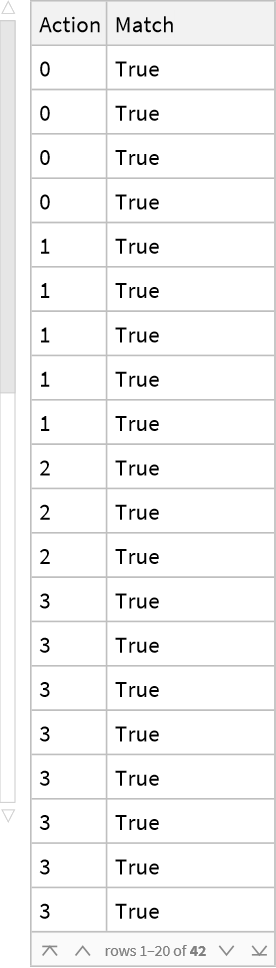

In [311]:
Dataset[
  conditionalTransitionAuditRowsS119B
]

In [316]:
Dataset[
  randomHoldoutPerDepthS119B
]

Dataset[{<|Depth -> 50, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 100, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 250, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Sequences, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 3], <||>]

<|TrueJointStates -> 120, HiddenFactorSizes -> {4, 5, 3, 2}, InferredFactors -> 4, 
 
>   LocalStateCounts -> {5, 3, 4, 2}, TrueInteractionEdges -> {3 -> 2, 4 -> 1}, 
 
>   LearnedInteractionEdges -> {3 -> 2, 4 -> 1}, InteractionGraphExact -> True, 
 
>   ActionParentAssignmentExact -> True, ConditionalTransitionMatches -> 42, 
 
>   ConditionalTransitionTotal -> 42, TrainingJointStates -> 46, 
 
>   TrainingCoveragePercent -> 38.3333, MaximumTrainingInteractionOrder -> 2, 
 
>   HighOrderTrainingStates -> 0, HighOrderHoldoutStates -> 74, HighOrderTouched -> 0, 
 
>   MembershipQueries -> 1822, HighOrderAccuracy -> 1., 
 
>   HighOrderTransitionAccuracy -> 1., RandomMixedAccuracy -> 1., 
 
>   AllJointAccuracy -> 1., ProbePartitionExact -> True, ActionPartitionExact -> True, 
 
>   LocalStateBijection -> True, StateCompression -> 8.57143, 
 
>   TransitionCompression -> 22.8571, CombinedCompression -> 27.5, 
 
>   ExactSparseStructuralIsomorphism -> True, AllFiniteSequenceEquivalent -> True, 
 
>   ProspectiveStrong -> True, Diagnosis -> 
 
>    S119B_SUCCESS_SPARSE_COUPLED_FACTOR_DISCOVERY_RECOVERS_THE_INTERACTION_GRAPH_AND_CO\
 
>     NDITIONAL_LOCAL_DYNAMICS_AND_GENERALIZES_FROM_PAIRWISE_TRAINING_TO_UNSEEN_HIGH_ORD\
 
>     ER_JOINT_COMBINATIONS|>
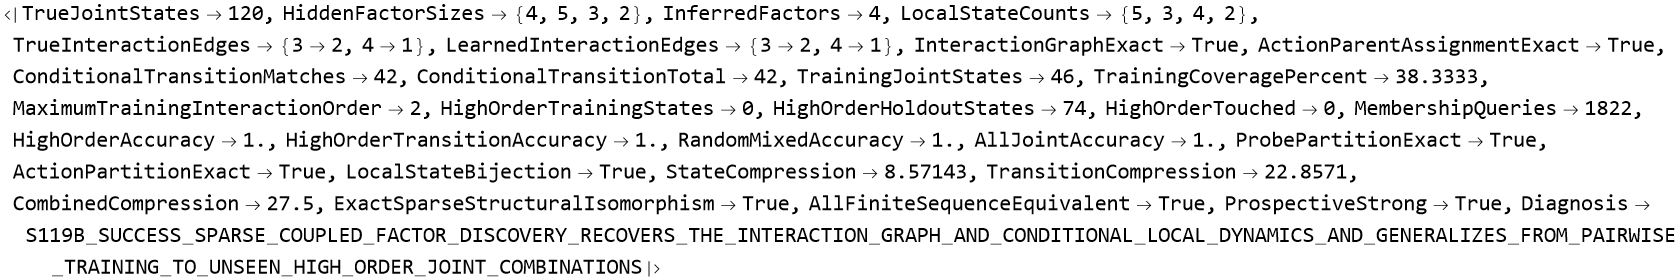

In [321]:
<|

  "TrueJointStates" ->
    trueJointStateCountS119B,

  "HiddenFactorSizes" ->
    hiddenFactorSizesS119B,

  "InferredFactors" ->
    inferredFactorCountS119B,

  "LocalStateCounts" ->
    learnedLocalStateCountsS119B,

  "TrueInteractionEdges" ->
    trueInteractionEdgesS119B,

  "LearnedInteractionEdges" ->
    learnedInteractionEdgesMappedS119B,

  "InteractionGraphExact" ->
    interactionGraphExactS119B,

  "ActionParentAssignmentExact" ->
    interactionParentAssignmentExactS119B,

  "ConditionalTransitionMatches" ->
    conditionalTransitionMatchesS119B,

  "ConditionalTransitionTotal" ->
    conditionalTransitionTotalS119B,

  "TrainingJointStates" ->
    trainingJointStateCountS119B,

  "TrainingCoveragePercent" ->
    100. trainingJointCoverageS119B,

  "MaximumTrainingInteractionOrder" ->
    maximumInteractionOrderSeenDuringTrainingS119B,

  "HighOrderTrainingStates" ->
    highOrderTrainingStatesS119B,

  "HighOrderHoldoutStates" ->
    Length[
      prospectiveHighOrderHoldoutS119B
    ],

  "HighOrderTouched" ->
    highOrderTouchedBeforeFreezeS119B,

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS119B,

  "HighOrderAccuracy" ->
    highOrderAccuracyS119B,

  "HighOrderTransitionAccuracy" ->
    highOrderTransitionAccuracyS119B,

  "RandomMixedAccuracy" ->
    randomHoldoutAccuracyS119B,

  "AllJointAccuracy" ->
    allJointAccuracyS119B,

  "ProbePartitionExact" ->
    factorProbePartitionExactS119B,

  "ActionPartitionExact" ->
    factorActionPartitionExactS119B,

  "LocalStateBijection" ->
    localStateBijectionPassedS119B,

  "StateCompression" ->
    stateStorageCompressionS119B,

  "TransitionCompression" ->
    transitionCompressionS119B,

  "CombinedCompression" ->
    combinedCompressionS119B,

  "ExactSparseStructuralIsomorphism" ->
    exactSparseStructuralIsomorphismS119B,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS119B,

  "ProspectiveStrong" ->
    prospectiveStrongS119B,

  "Diagnosis" ->
    diagnosisS119B

|>

In [326]:
(* ============================================================ *)
(* S120A                                                        *)
(* PARTIAL OBSERVABILITY / HIDDEN-FACTOR STATE INFERENCE        *)
(* ============================================================ *)
(*                                                              *)
(* TRUE HIDDEN WORLD                                             *)
(* ------------------------------------------------------------ *)
(* X in Z3                                                      *)
(* Y in Z2                                                      *)
(* H in Z3                                                      *)
(*                                                              *)
(* H HAS NO DIRECT PROBES.                                      *)
(*                                                              *)
(* Therefore true states                                       *)
(*                                                              *)
(*      (X,Y,H1) and (X,Y,H2)                                   *)
(*                                                              *)
(* can have exactly the same current observation.               *)
(*                                                              *)
(* H is behaviorally observable only through future             *)
(* intervention on X.                                           *)
(*                                                              *)
(* Learner is NOT given:                                        *)
(* - latent factor count                                        *)
(* - which factor is hidden                                     *)
(* - hidden factor size                                         *)
(* - action grouping                                            *)
(* - probe grouping                                             *)
(* - hidden action identities                                   *)
(* - hidden-state semantics                                     *)
(* - transition table                                           *)
(*                                                              *)
(* Learner sees only FINAL BINARY PROBE OUTPUTS.                 *)
(*                                                              *)
(* FROZEN STRUCTURAL PRIOR                                      *)
(* ------------------------------------------------------------ *)
(* Zero-immediate-support actions are treated as one candidate   *)
(* hidden residual component.                                   *)
(*                                                              *)
(* This is intentionally S120A, not yet arbitrary multiple      *)
(* hidden-factor discovery.                                     *)
(* ============================================================ *)


ClearAll["Global`S120A*"];
ClearAll["Global`s120A*"];


s120AResult =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S120AFail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S120A_STOP"];
);


Print["================================================"];
Print["S120A PARTIAL OBSERVABILITY / HIDDEN-FACTOR INFERENCE"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC INTERFACE                                          *)
(* ============================================================ *)

publicActionsS120A =
  Range[0, 5];


publicProbesS120A =
  Range[0, 4];


Print[
  "Public actions = ",
  publicActionsS120A
];


Print[
  "Public binary probes = ",
  publicProbesS120A
];


Print["ONE TRUE LATENT FACTOR HAS NO DIRECT PROBES."];
Print["LEARNER IS NOT TOLD WHICH FACTOR IS HIDDEN."];
Print["LEARNER IS NOT GIVEN LATENT FACTOR COUNT OR SIZES."];
Print["LEARNER RECEIVES FINAL BINARY OBSERVATIONS ONLY."];


(* ============================================================ *)
(* 2. FREEZE LEARNING POLICY                                    *)
(* ============================================================ *)

supportScanDepthS120A =
  8;


visibleBFSSafetyS120A =
  64;


hiddenBFSSafetyS120A =
  64;


preparationBFSSafetyS120A =
  128;


learningPolicySpecS120A =
  <|

    "Actions" ->
      publicActionsS120A,

    "Probes" ->
      publicProbesS120A,

    "SupportScanDepth" ->
      supportScanDepthS120A,

    "VisibleFactorRule" ->
      "EqualNonEmptyProbeSupport",

    "ZeroSupportRule" ->
      "SingleHiddenResidualFactorCandidate",

    "HiddenStateCriterion" ->
      "FutureObservableBehaviorUnderVisibleInterventions",

    "HiddenExperimentDepth" ->
      1,

    "ConditionalDynamicsRule" ->
      "TestVisibleTransitionsAcrossLearnedHiddenStates"

  |>;


frozenLearningPolicyHashS120A =
  Hash[
    learningPolicySpecS120A,
    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S120A POLICY FROZEN"];


Print[
  "Support scan depth = ",
  supportScanDepthS120A
];


Print[
  "Policy hash = ",
  frozenLearningPolicyHashS120A
];


Print["HIDDEN WORLD DOES NOT YET EXIST."];
Print["================================================"];


(* ============================================================ *)
(* 3. GENERATE HIDDEN WORLD AFTER POLICY FREEZE                 *)
(*                                                              *)
(* True factors:                                                *)
(* 1 = X, size 3                                                *)
(* 2 = Y, size 2                                                *)
(* 3 = H, size 3, NO PROBES                                     *)
(*                                                              *)
(* One X action is H-dependent:                                 *)
(*                                                              *)
(* H=0 : X += 1                                                 *)
(* H=1 : X += 2                                                 *)
(* H=2 : X += 0                                                 *)
(*                                                              *)
(* So H is not immediately observable, but is future-           *)
(* behaviorally distinguishable.                                *)
(* ============================================================ *)

hiddenBenchmarkSeedS120A =
  1205101;


trueFactorSizesS120A =
  {
    3,
    2,
    3
  };


trueHiddenFactorS120A =
  3;


hiddenActionRolePoolS120A =
  {
    {"XPlus", 1, 1},
    {"XMinus", 1, -1},
    {"YPlus", 2, 1},
    {"YMinus", 2, -1},
    {"HPlus", 3, 1},
    {"HMinus", 3, -1}
  };


hiddenActionRolePermutationS120A =
BlockRandom[

  SeedRandom[
    hiddenBenchmarkSeedS120A
  ];

  RandomSample[
    hiddenActionRolePoolS120A
  ]

];


hiddenActionRolesS120A =
  AssociationThread[
    publicActionsS120A ->
      hiddenActionRolePermutationS120A
  ];


hiddenProbeRolePoolS120A =
  {
    {1, 0},
    {1, 1},
    {1, 2},
    {2, 0},
    {2, 1}
  };


hiddenProbeRolePermutationS120A =
BlockRandom[

  SeedRandom[
    hiddenBenchmarkSeedS120A + 1
  ];

  RandomSample[
    hiddenProbeRolePoolS120A
  ]

];


hiddenProbeRolesS120A =
  AssociationThread[
    publicProbesS120A ->
      hiddenProbeRolePermutationS120A
  ];


hiddenStartStateS120A =
  {
    0,
    0,
    0
  };


S120AEnvStep[
  state_List,
  action_Integer
] :=
Module[
  {
    role,
    name,
    factor,
    direction,
    next,
    delta
  },


  role =
    Lookup[
      hiddenActionRolesS120A,
      action,
      Missing[
        "UnknownAction"
      ]
    ];


  If[
    !ListQ[
      role
    ],

    Missing[
      "UnknownAction"
    ],


    name =
      role[[1]];


    factor =
      role[[2]];


    direction =
      role[[3]];


    next =
      state;


    Which[

      name === "XPlus",

        delta =
          Switch[
            state[[3]],

            0,
              1,

            1,
              2,

            2,
              0
          ];


        next[[1]] =
          Mod[
            next[[1]] + delta,
            3
          ],


      name === "XMinus",

        next[[1]] =
          Mod[
            next[[1]] - 1,
            3
          ],


      name === "YPlus",

        next[[2]] =
          Mod[
            next[[2]] + 1,
            2
          ],


      name === "YMinus",

        next[[2]] =
          Mod[
            next[[2]] - 1,
            2
          ],


      name === "HPlus",

        next[[3]] =
          Mod[
            next[[3]] + 1,
            3
          ],


      name === "HMinus",

        next[[3]] =
          Mod[
            next[[3]] - 1,
            3
          ],


      True,

        next =
          Missing[
            "UnknownRole"
          ]

    ];


    next
  ]
];


S120AEnvStateAfter[
  seq_List
] :=
  Fold[
    S120AEnvStep,
    hiddenStartStateS120A,
    seq
  ];


S120AEnvOutputFromState[
  state_List,
  probe_Integer
] :=
Module[
  {
    role
  },


  role =
    Lookup[
      hiddenProbeRolesS120A,
      probe,
      Missing[
        "UnknownProbe"
      ]
    ];


  If[
    !ListQ[
      role
    ],

    Missing[
      "UnknownProbe"
    ],

    Boole[
      state[[role[[1]]]] ===
        role[[2]]
    ]
  ]
];


S120AEnvRawOutput[
  seq_List,
  probe_Integer
] :=
Module[
  {
    state
  },


  state =
    S120AEnvStateAfter[
      seq
    ];


  If[
    ListQ[
      state
    ],

    S120AEnvOutputFromState[
      state,
      probe
    ],

    Missing[
      "EnvironmentFailure"
    ]
  ]
];


Print["NEW PARTIALLY OBSERVABLE WORLD GENERATED."];
Print["Action roles and hidden state remain sealed."];


(* ============================================================ *)
(* 4. PROSPECTIVE RANDOM MIXED HOLDOUT                          *)
(* ============================================================ *)

randomHoldoutSeedS120A =
  1205102;


randomHoldoutDepthsS120A =
  {
    50,
    100,
    250,
    500
  };


randomHoldoutPerDepthS120A =
  100;


prospectiveRandomHoldoutS120A =
BlockRandom[

  SeedRandom[
    randomHoldoutSeedS120A
  ];


  Flatten[
    Table[

      Table[

        <|

          "Depth" ->
            depth,

          "Sequence" ->
            RandomChoice[
              publicActionsS120A,
              depth
            ]

        |>,

        {
          randomHoldoutPerDepthS120A
        }
      ],

      {
        depth,
        randomHoldoutDepthsS120A
      }
    ],

    1
  ]
];


Print[
  "Prospective random holdout = ",
  Length[
    prospectiveRandomHoldoutS120A
  ]
];


(* ============================================================ *)
(* 5. PROSPECTIVE ALIASED-HISTORY CHALLENGE                     *)
(*                                                              *)
(* Evaluator creates long histories ending in SAME visible      *)
(* state X=0,Y=0 but DIFFERENT hidden H.                         *)
(*                                                              *)
(* Current observations are therefore identical.                *)
(*                                                              *)
(* Then every action is applied.                                *)
(* Correct prediction requires retaining/inferencing H from     *)
(* history.                                                     *)
(* ============================================================ *)

evaluatorHiddenPlusActionS120A =
  SelectFirst[
    publicActionsS120A,

    Function[
      action,

      Lookup[
        hiddenActionRolesS120A,
        action
      ][[1]] ===
        "HPlus"
    ]
  ];


prospectiveAliasPrefixesS120A =
  Flatten[
    Table[

      Table[

        <|

          "HiddenValueEvaluatorOnly" ->
            hiddenValue,

          "Prefix" ->
            ConstantArray[
              evaluatorHiddenPlusActionS120A,
              hiddenValue +
                3 (
                  20 + replicate
                )
            ]

        |>,

        {
          replicate,
          1,
          30
        }
      ],

      {
        hiddenValue,
        0,
        2
      }
    ],

    1
  ];


prospectiveAliasTransitionHoldoutS120A =
  Flatten[
    Table[

      Table[

        <|

          "HiddenValueEvaluatorOnly" ->
            row[
              "HiddenValueEvaluatorOnly"
            ],

          "Action" ->
            action,

          "Sequence" ->
            Append[
              row[
                "Prefix"
              ],
              action
            ]

        |>,

        {
          action,
          publicActionsS120A
        }
      ],

      {
        row,
        prospectiveAliasPrefixesS120A
      }
    ],

    1
  ];


Print[
  "Prospective aliased prefixes = ",
  Length[
    prospectiveAliasPrefixesS120A
  ]
];


Print[
  "Prospective aliased future-action challenges = ",
  Length[
    prospectiveAliasTransitionHoldoutS120A
  ]
];


Print["ALIased-history outputs remain sealed."];
Print["================================================"];


(* ============================================================ *)
(* 6. MEMBERSHIP INTERFACE                                      *)
(* ============================================================ *)

membershipCacheS120A =
  <||>;


membershipUniqueCountS120A =
  0;


membershipNewBySourceS120A =
  <|

    "SupportScan" -> 0,

    "VisibleBFS" -> 0,

    "HiddenBFS" -> 0,

    "ConditionalTable" -> 0,

    "RandomHoldout" -> 0,

    "AliasHoldout" -> 0,

    "Audit" -> 0

  |>;


queriedSequenceRegistryS120A =
  <||>;


S120ASeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S120AQueryKey[
  seq_List,
  probe_Integer
] :=
  ToString[
    InputForm[
      {
        seq,
        probe
      }
    ]
  ];


S120AMembershipY[
  seq_List,
  probe_Integer,
  source_String
] :=
Module[
  {
    key,
    seqKey,
    y,
    oldCount
  },


  key =
    S120AQueryKey[
      seq,
      probe
    ];


  seqKey =
    S120ASeqKey[
      seq
    ];


  If[
    !KeyExistsQ[
      queriedSequenceRegistryS120A,
      seqKey
    ],

    AssociateTo[
      queriedSequenceRegistryS120A,
      seqKey -> seq
    ];
  ];


  If[
    KeyExistsQ[
      membershipCacheS120A,
      key
    ],

    Lookup[
      membershipCacheS120A,
      key
    ],


    y =
      S120AEnvRawOutput[
        seq,
        probe
      ];


    If[
      !MemberQ[
        {0, 1},
        y
      ],

      S120AFail[
        "Membership oracle returned non-binary output."
      ]
    ];


    membershipUniqueCountS120A++;


    AssociateTo[
      membershipCacheS120A,
      key -> y
    ];


    oldCount =
      Lookup[
        membershipNewBySourceS120A,
        source,
        0
      ];


    AssociateTo[
      membershipNewBySourceS120A,
      source -> (oldCount + 1)
    ];


    y
  ]
];


S120AObserveSignature[
  seq_List,
  probes_List,
  source_String
] :=
  Table[

    S120AMembershipY[
      seq,
      probe,
      source
    ],

    {
      probe,
      probes
    }
  ];


S120ASignatureKey[
  signature_List
] :=
  ToString[
    InputForm[
      signature
    ]
  ];


(* ============================================================ *)
(* 7. ACTION SUPPORT DISCOVERY                                  *)
(*                                                              *)
(* Visible actions change some direct probes.                   *)
(* Hidden actions change NO current probes.                     *)
(* ============================================================ *)

Print["================================================"];
Print["S120A OBSERVABLE SUPPORT DISCOVERY"];
Print["================================================"];


baselineVisibleSignatureS120A =
  S120AObserveSignature[
    {},
    publicProbesS120A,
    "SupportScan"
  ];


actionSupportRowsS120A =
  Table[

    Module[
      {
        signatures,
        changedPositions,
        support
      },


      signatures =
        Table[

          S120AObserveSignature[
            ConstantArray[
              action,
              repetition
            ],
            publicProbesS120A,
            "SupportScan"
          ],

          {
            repetition,
            1,
            supportScanDepthS120A
          }
        ];


      changedPositions =
        Select[
          Range[
            Length[
              publicProbesS120A
            ]
          ],

          Function[
            position,

            AnyTrue[
              signatures,

              Function[
                signature,

                signature[[position]] =!=
                  baselineVisibleSignatureS120A[[position]]
              ]
            ]
          ]
        ];


      support =
        publicProbesS120A[[
          changedPositions
        ]];


      <|

        "Action" ->
          action,

        "ObservedProbeSupport" ->
          Sort[
            support
          ],

        "SupportSize" ->
          Length[
            support
          ]

      |>

    ],

    {
      action,
      publicActionsS120A
    }
  ];


visibleActionSupportRowsS120A =
  Select[
    actionSupportRowsS120A,
    #["SupportSize"] > 0 &
  ];


hiddenActionCandidatesS120A =
  Sort[
    (
      #["Action"] &
    ) /@
      Select[
        actionSupportRowsS120A,
        #["SupportSize"] == 0 &
      ]
  ];


If[
  Length[
    hiddenActionCandidatesS120A
  ] == 0,

  S120AFail[
    "No zero-support hidden-action candidates discovered."
  ]
];


visibleSupportGroupsS120A =
  Values[
    GroupBy[
      visibleActionSupportRowsS120A,

      Function[
        row,

        ToString[
          InputForm[
            row[
              "ObservedProbeSupport"
            ]
          ]
        ]
      ]
    ]
  ];


visibleFactorDescriptorsS120A =
  Table[

    <|

      "LearnedVisibleFactor" ->
        groupIndex,

      "Probes" ->
        Sort[
          visibleSupportGroupsS120A[[groupIndex, 1]][
            "ObservedProbeSupport"
          ]
        ],

      "Actions" ->
        Sort[
          (
            #["Action"] &
          ) /@
            visibleSupportGroupsS120A[[groupIndex]]
        ]

    |>,

    {
      groupIndex,
      1,
      Length[
        visibleSupportGroupsS120A
      ]
    }
  ];


visibleFactorDescriptorsS120A =
  SortBy[
    visibleFactorDescriptorsS120A,
    First[
      #["Probes"]
    ] &
  ];


visibleFactorDescriptorsS120A =
  Table[

    Join[
      visibleFactorDescriptorsS120A[[i]],

      <|
        "LearnedVisibleFactor" -> i
      |>
    ],

    {
      i,
      Length[
        visibleFactorDescriptorsS120A
      ]
    }
  ];


inferredVisibleFactorCountS120A =
  Length[
    visibleFactorDescriptorsS120A
  ];


Print[
  "Inferred directly observable factors = ",
  inferredVisibleFactorCountS120A
];


Print[
  "Visible probe-group sizes = ",
  Length /@
    (
      #["Probes"] &
    ) /@
      visibleFactorDescriptorsS120A
];


Print[
  "Visible action-group sizes = ",
  Length /@
    (
      #["Actions"] &
    ) /@
      visibleFactorDescriptorsS120A
];


Print[
  "Zero-support action candidates = ",
  hiddenActionCandidatesS120A
];


(* ============================================================ *)
(* 8. LEARN DIRECTLY OBSERVABLE LOCAL FACTORS                   *)
(* ============================================================ *)

S120ALocalTransitionKey[
  state_Integer,
  action_Integer
] :=
  ToString[
    InputForm[
      {
        state,
        action
      }
    ]
  ];


S120ALearnVisibleFactor[
  descriptor_Association
] :=
Module[
  {
    probes,
    actions,
    startSignature,
    signatureToState,
    stateSignatures,
    representatives,
    transitions,
    queue,
    currentState,
    currentRep,
    nextSeq,
    nextSignature,
    nextKey,
    nextState,
    newState,
    guard
  },


  probes =
    descriptor[
      "Probes"
    ];


  actions =
    descriptor[
      "Actions"
    ];


  startSignature =
    S120AObserveSignature[
      {},
      probes,
      "VisibleBFS"
    ];


  signatureToState =
    Association[
      S120ASignatureKey[
        startSignature
      ] -> 1
    ];


  stateSignatures =
    <|
      1 -> startSignature
    |>;


  representatives =
    <|
      1 -> {}
    |>;


  transitions =
    <||>;


  queue =
    {1};


  guard =
    0;


  While[
    Length[
      queue
    ] > 0,


    guard++;


    If[
      guard >
        visibleBFSSafetyS120A,

      S120AFail[
        "Visible local BFS guard exceeded."
      ]
    ];


    currentState =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    currentRep =
      Lookup[
        representatives,
        currentState
      ];


    Do[

      nextSeq =
        Append[
          currentRep,
          action
        ];


      nextSignature =
        S120AObserveSignature[
          nextSeq,
          probes,
          "VisibleBFS"
        ];


      nextKey =
        S120ASignatureKey[
          nextSignature
        ];


      If[
        KeyExistsQ[
          signatureToState,
          nextKey
        ],

        nextState =
          Lookup[
            signatureToState,
            nextKey
          ],


        newState =
          Length[
            stateSignatures
          ] + 1;


        nextState =
          newState;


        AssociateTo[
          signatureToState,
          nextKey -> newState
        ];


        AssociateTo[
          stateSignatures,
          newState -> nextSignature
        ];


        AssociateTo[
          representatives,
          newState -> nextSeq
        ];


        AppendTo[
          queue,
          newState
        ];
      ];


      AssociateTo[
        transitions,

        S120ALocalTransitionKey[
          currentState,
          action
        ] ->
          nextState
      ],

      {
        action,
        actions
      }
    ];

  ];


  <|

    "Probes" ->
      probes,

    "Actions" ->
      actions,

    "StateCount" ->
      Length[
        stateSignatures
      ],

    "StateSignatures" ->
      stateSignatures,

    "RepresentativeByState" ->
      representatives,

    "BaselineTransitions" ->
      transitions,

    "StartState" ->
      1,

    "OneHot" ->
      AllTrue[
        Values[
          stateSignatures
        ],
        Total[#] === 1 &
      ]

  |>
];


learnedVisibleFactorsS120A =
  S120ALearnVisibleFactor /@
    visibleFactorDescriptorsS120A;


visibleLocalStateCountsS120A =
  (
    #["StateCount"] &
  ) /@
    learnedVisibleFactorsS120A;


Print["================================================"];
Print["DIRECTLY OBSERVABLE LOCAL FACTORS LEARNED"];


Print[
  "Visible local state counts = ",
  visibleLocalStateCountsS120A
];


Print[
  "Visible signatures one-hot = ",
  AllTrue[
    learnedVisibleFactorsS120A,
    TrueQ[
      #["OneHot"]
    ] &
  ]
];


Print["================================================"];


(* ============================================================ *)
(* 9. DISCOVER HIDDEN BEHAVIORAL STATE                          *)
(*                                                              *)
(* Hidden-only histories have the SAME current probe output.    *)
(*                                                              *)
(* Define their latent signature from FUTURE visible behavior:  *)
(*                                                              *)
(*   current visible observation                                *)
(*   + observation after every visible primitive intervention   *)
(*                                                              *)
(* No true H labels are used.                                   *)
(* ============================================================ *)

visibleActionsS120A =
  Sort[
    Flatten[
      (
        #["Actions"] &
      ) /@
        visibleFactorDescriptorsS120A
    ]
  ];


S120AHiddenBehaviorSignature[
  history_List
] :=
  Flatten[
    Join[
      {
        S120AObserveSignature[
          history,
          publicProbesS120A,
          "HiddenBFS"
        ]
      },

      Table[
        S120AObserveSignature[
          Append[
            history,
            action
          ],
          publicProbesS120A,
          "HiddenBFS"
        ],

        {
          action,
          visibleActionsS120A
        }
      ]
    ],

    1
  ];


hiddenStartBehaviorSignatureS120A =
  S120AHiddenBehaviorSignature[
    {}
  ];


hiddenSignatureToStateS120A =
  Association[
    S120ASignatureKey[
      hiddenStartBehaviorSignatureS120A
    ] -> 1
  ];


hiddenStateSignaturesS120A =
  <|
    1 ->
      hiddenStartBehaviorSignatureS120A
  |>;


hiddenRepresentativeByStateS120A =
  <|
    1 -> {}
  |>;


hiddenTransitionsS120A =
  <||>;


hiddenQueueS120A =
  {1};


hiddenGuardS120A =
  0;


While[
  Length[
    hiddenQueueS120A
  ] > 0,


  hiddenGuardS120A++;


  If[
    hiddenGuardS120A >
      hiddenBFSSafetyS120A,

    S120AFail[
      "Hidden residual BFS guard exceeded."
    ]
  ];


  currentHiddenStateS120A =
    First[
      hiddenQueueS120A
    ];


  hiddenQueueS120A =
    Rest[
      hiddenQueueS120A
    ];


  currentHiddenRepS120A =
    Lookup[
      hiddenRepresentativeByStateS120A,
      currentHiddenStateS120A
    ];


  Do[

    nextHiddenSeqS120A =
      Append[
        currentHiddenRepS120A,
        hiddenAction
      ];


    nextHiddenSignatureS120A =
      S120AHiddenBehaviorSignature[
        nextHiddenSeqS120A
      ];


    nextHiddenKeyS120A =
      S120ASignatureKey[
        nextHiddenSignatureS120A
      ];


    If[
      KeyExistsQ[
        hiddenSignatureToStateS120A,
        nextHiddenKeyS120A
      ],

      nextHiddenStateS120A =
        Lookup[
          hiddenSignatureToStateS120A,
          nextHiddenKeyS120A
        ],


      nextHiddenStateS120A =
        Length[
          hiddenStateSignaturesS120A
        ] + 1;


      AssociateTo[
        hiddenSignatureToStateS120A,
        nextHiddenKeyS120A ->
          nextHiddenStateS120A
      ];


      AssociateTo[
        hiddenStateSignaturesS120A,
        nextHiddenStateS120A ->
          nextHiddenSignatureS120A
      ];


      AssociateTo[
        hiddenRepresentativeByStateS120A,
        nextHiddenStateS120A ->
          nextHiddenSeqS120A
      ];


      AppendTo[
        hiddenQueueS120A,
        nextHiddenStateS120A
      ];
    ];


    AssociateTo[
      hiddenTransitionsS120A,

      S120ALocalTransitionKey[
        currentHiddenStateS120A,
        hiddenAction
      ] ->
        nextHiddenStateS120A
    ],

    {
      hiddenAction,
      hiddenActionCandidatesS120A
    }
  ];

];


learnedHiddenStateCountS120A =
  Length[
    hiddenStateSignaturesS120A
  ];


learnedHiddenFactorIndexS120A =
  inferredVisibleFactorCountS120A + 1;


Print["================================================"];
Print["HIDDEN BEHAVIORAL FACTOR DISCOVERED"];


Print[
  "Hidden residual states discovered = ",
  learnedHiddenStateCountS120A
];


Print[
  "Hidden transition cells = ",
  Length[
    hiddenTransitionsS120A
  ]
];


Print[
  "Total inferred factor count = ",
  learnedHiddenFactorIndexS120A
];


Print["================================================"];


(* ============================================================ *)
(* 10. MAP PUBLIC ACTIONS / PROBES TO LEARNED COMPONENTS        *)
(* ============================================================ *)

actionToVisibleFactorS120A =
  Association[
    Flatten[
      Table[

        Table[
          action -> factorIndex,

          {
            action,
            learnedVisibleFactorsS120A[[factorIndex]][
              "Actions"
            ]
          }
        ],

        {
          factorIndex,
          1,
          inferredVisibleFactorCountS120A
        }
      ]
    ]
  ];


probeToVisibleFactorS120A =
  Association[
    Flatten[
      Table[

        Table[
          probe -> factorIndex,

          {
            probe,
            learnedVisibleFactorsS120A[[factorIndex]][
              "Probes"
            ]
          }
        ],

        {
          factorIndex,
          1,
          inferredVisibleFactorCountS120A
        }
      ]
    ]
  ];


(* ============================================================ *)
(* 11. LOCAL SIGNATURE -> LOCAL STATE                           *)
(* ============================================================ *)

S120AVisibleStateFromSignature[
  factorIndex_Integer,
  signature_List
] :=
  SelectFirst[
    Range[
      learnedVisibleFactorsS120A[[factorIndex]][
        "StateCount"
      ]
    ],

    Function[
      localState,

      Lookup[
        learnedVisibleFactorsS120A[[factorIndex]][
          "StateSignatures"
        ],
        localState
      ] ===
        signature
    ],

    Missing[
      "UnknownVisibleSignature"
    ]
  ];


(* ============================================================ *)
(* 12. PREPARE A VISIBLE LOCAL STATE UNDER A HIDDEN CONTEXT      *)
(*                                                              *)
(* Start from a learned hidden-state representative.             *)
(* BFS only with actions belonging to the target visible factor.*)
(* Hidden state is therefore preserved.                         *)
(* ============================================================ *)

S120APrepareVisibleState[
  hiddenRepresentative_List,
  factorIndex_Integer,
  desiredLocalState_Integer
] :=
Module[
  {
    probes,
    actions,
    desiredSignature,
    startSignature,
    result
  },


  probes =
    learnedVisibleFactorsS120A[[factorIndex]][
      "Probes"
    ];


  actions =
    learnedVisibleFactorsS120A[[factorIndex]][
      "Actions"
    ];


  desiredSignature =
    Lookup[
      learnedVisibleFactorsS120A[[factorIndex]][
        "StateSignatures"
      ],
      desiredLocalState
    ];


  startSignature =
    S120AObserveSignature[
      hiddenRepresentative,
      probes,
      "ConditionalTable"
    ];


  result =
    Catch[

      Module[
        {
          queue,
          visited,
          current,
          currentSeq,
          currentSignature,
          nextSeq,
          nextSignature,
          nextKey,
          guard
        },


        If[
          startSignature ===
            desiredSignature,

          Throw[
            hiddenRepresentative,
            "S120A_PREPARED"
          ];
        ];


        queue =
          {
            {
              hiddenRepresentative,
              startSignature
            }
          };


        visited =
          <|
            S120ASignatureKey[
              startSignature
            ] -> True
          |>;


        guard =
          0;


        While[
          Length[
            queue
          ] > 0,


          guard++;


          If[
            guard >
              preparationBFSSafetyS120A,

            Throw[
              $Failed,
              "S120A_PREPARED"
            ];
          ];


          current =
            First[
              queue
            ];


          queue =
            Rest[
              queue
            ];


          currentSeq =
            current[[1]];


          currentSignature =
            current[[2]];


          Do[

            nextSeq =
              Append[
                currentSeq,
                action
              ];


            nextSignature =
              S120AObserveSignature[
                nextSeq,
                probes,
                "ConditionalTable"
              ];


            If[
              nextSignature ===
                desiredSignature,

              Throw[
                nextSeq,
                "S120A_PREPARED"
              ];
            ];


            nextKey =
              S120ASignatureKey[
                nextSignature
              ];


            If[
              !KeyExistsQ[
                visited,
                nextKey
              ],

              AssociateTo[
                visited,
                nextKey -> True
              ];


              AppendTo[
                queue,
                {
                  nextSeq,
                  nextSignature
                }
              ];
            ],

            {
              action,
              actions
            }
          ];

        ];


        $Failed
      ],

      "S120A_PREPARED"
    ];


  If[
    result === $Failed,

    S120AFail[
      "Could not prepare visible state under learned hidden context."
    ],

    result
  ]
];


(* ============================================================ *)
(* 13. DISCOVER WHICH VISIBLE ACTIONS DEPEND ON HIDDEN STATE    *)
(* ============================================================ *)

visibleConditionalRawRowsS120A =
  Flatten[
    Table[

      Module[
        {
          hiddenRep,
          preparedSeq,
          nextSeq,
          targetSignature,
          destinationState
        },


        hiddenRep =
          Lookup[
            hiddenRepresentativeByStateS120A,
            hiddenState
          ];


        preparedSeq =
          S120APrepareVisibleState[
            hiddenRep,
            factorIndex,
            targetState
          ];


        nextSeq =
          Append[
            preparedSeq,
            action
          ];


        targetSignature =
          S120AObserveSignature[
            nextSeq,
            learnedVisibleFactorsS120A[[factorIndex]][
              "Probes"
            ],
            "ConditionalTable"
          ];


        destinationState =
          S120AVisibleStateFromSignature[
            factorIndex,
            targetSignature
          ];


        If[
          !IntegerQ[
            destinationState
          ],

          S120AFail[
            "Conditional transition reached unknown visible state."
          ]
        ];


        <|

          "Action" ->
            action,

          "TargetFactor" ->
            factorIndex,

          "TargetState" ->
            targetState,

          "HiddenState" ->
            hiddenState,

          "DestinationState" ->
            destinationState

        |>

      ],

      {
        action,
        visibleActionsS120A
      },

      {
        factorIndex,
        {
          Lookup[
            actionToVisibleFactorS120A,
            action
          ]
        }
      },

      {
        targetState,
        Range[
          learnedVisibleFactorsS120A[[factorIndex]][
            "StateCount"
          ]
        ]
      },

      {
        hiddenState,
        Range[
          learnedHiddenStateCountS120A
        ]
      }
    ],

    3
  ];


S120AActionDependsOnHiddenQ[
  action_Integer
] :=
Module[
  {
    rows,
    factorIndex,
    stateCount
  },


  rows =
    Select[
      visibleConditionalRawRowsS120A,
      #["Action"] === action &
    ];


  factorIndex =
    Lookup[
      actionToVisibleFactorS120A,
      action
    ];


  stateCount =
    learnedVisibleFactorsS120A[[factorIndex]][
      "StateCount"
    ];


  AnyTrue[
    Range[
      stateCount
    ],

    Function[
      targetState,

      Length[
        DeleteDuplicates[
          (
            #["DestinationState"] &
          ) /@
            Select[
              rows,
              #["TargetState"] ===
                targetState &
            ]
        ]
      ] > 1
    ]
  ]
];


visibleActionDependsOnHiddenS120A =
  Association[
    Table[

      action ->
        S120AActionDependsOnHiddenQ[
          action
        ],

      {
        action,
        visibleActionsS120A
      }
    ]
  ];


learnedHiddenDependentVisibleActionsS120A =
  Sort[
    Select[
      visibleActionsS120A,
      TrueQ[
        Lookup[
          visibleActionDependsOnHiddenS120A,
          #
        ]
      ] &
    ]
  ];


Print[
  "Visible actions depending on hidden state = ",
  learnedHiddenDependentVisibleActionsS120A
];


(* ============================================================ *)
(* 14. BUILD SPARSE VISIBLE CONDITIONAL TRANSITION TABLE        *)
(* ============================================================ *)

S120AVisibleConditionalKey[
  action_Integer,
  targetState_Integer,
  hiddenState_Integer
] :=
  ToString[
    InputForm[
      {
        action,
        targetState,
        hiddenState
      }
    ]
  ];


visibleConditionalTransitionsS120A =
  <||>;


visibleConditionalTransitionRowsS120A =
  {};


Do[

  factorIndexS120A =
    Lookup[
      actionToVisibleFactorS120A,
      action
    ];


  dependsS120A =
    TrueQ[
      Lookup[
        visibleActionDependsOnHiddenS120A,
        action
      ]
    ];


  Do[

    If[
      dependsS120A,


      Do[

        destinationS120A =
          SelectFirst[
            visibleConditionalRawRowsS120A,

            And[
              #["Action"] === action,
              #["TargetState"] === targetState,
              #["HiddenState"] === hiddenState
            ] &
          ][
            "DestinationState"
          ];


        AssociateTo[
          visibleConditionalTransitionsS120A,

          S120AVisibleConditionalKey[
            action,
            targetState,
            hiddenState
          ] ->
            destinationS120A
        ];


        AppendTo[
          visibleConditionalTransitionRowsS120A,

          <|

            "Action" ->
              action,

            "TargetFactor" ->
              factorIndexS120A,

            "TargetState" ->
              targetState,

            "HiddenCondition" ->
              hiddenState,

            "DestinationState" ->
              destinationS120A

          |>
        ],

        {
          hiddenState,
          Range[
            learnedHiddenStateCountS120A
          ]
        }
      ],


      destinationS120A =
        SelectFirst[
          visibleConditionalRawRowsS120A,

          And[
            #["Action"] === action,
            #["TargetState"] === targetState
          ] &
        ][
          "DestinationState"
        ];


      AssociateTo[
        visibleConditionalTransitionsS120A,

        S120AVisibleConditionalKey[
          action,
          targetState,
          0
        ] ->
          destinationS120A
      ];


      AppendTo[
        visibleConditionalTransitionRowsS120A,

        <|

          "Action" ->
            action,

          "TargetFactor" ->
            factorIndexS120A,

          "TargetState" ->
            targetState,

          "HiddenCondition" ->
            0,

          "DestinationState" ->
            destinationS120A

        |>
      ];
    ],

    {
      targetState,
      Range[
        learnedVisibleFactorsS120A[[factorIndexS120A]][
          "StateCount"
        ]
      ]
    }
  ],

  {
    action,
    visibleActionsS120A
  }
];


Print[
  "Sparse visible conditional transition cells = ",
  Length[
    visibleConditionalTransitionsS120A
  ]
];


(* ============================================================ *)
(* 15. BUILD PARTIALLY-OBSERVABLE FACTORIZED EXECUTOR           *)
(*                                                              *)
(* Model state:                                                 *)
(*                                                              *)
(*      {VisibleFactor1, VisibleFactor2, HiddenBehaviorState}    *)
(* ============================================================ *)

modelStartStateS120A =
  Join[
    (
      #["StartState"] &
    ) /@
      learnedVisibleFactorsS120A,

    {
      1
    }
  ];


S120AModelStep[
  jointState_List,
  action_Integer
] :=
Module[
  {
    next,
    visibleFactor,
    targetState,
    hiddenState,
    hiddenCondition,
    destination
  },


  next =
    jointState;


  If[
    MemberQ[
      hiddenActionCandidatesS120A,
      action
    ],


    destination =
      Lookup[
        hiddenTransitionsS120A,

        S120ALocalTransitionKey[
          jointState[[
            learnedHiddenFactorIndexS120A
          ]],
          action
        ],

        Missing[
          "UnknownHiddenTransition"
        ]
      ];


    If[
      !IntegerQ[
        destination
      ],

      Missing[
        "ModelTransitionFailure"
      ],

      next[[
        learnedHiddenFactorIndexS120A
      ]] =
        destination;


      next
    ],


    visibleFactor =
      Lookup[
        actionToVisibleFactorS120A,
        action,
        Missing[
          "UnknownVisibleAction"
        ]
      ];


    If[
      !IntegerQ[
        visibleFactor
      ],

      Missing[
        "UnknownAction"
      ],


      targetState =
        jointState[[
          visibleFactor
        ]];


      hiddenState =
        jointState[[
          learnedHiddenFactorIndexS120A
        ]];


      hiddenCondition =
        If[
          TrueQ[
            Lookup[
              visibleActionDependsOnHiddenS120A,
              action
            ]
          ],

          hiddenState,

          0
        ];


      destination =
        Lookup[
          visibleConditionalTransitionsS120A,

          S120AVisibleConditionalKey[
            action,
            targetState,
            hiddenCondition
          ],

          Missing[
            "UnknownConditionalTransition"
          ]
        ];


      If[
        !IntegerQ[
          destination
        ],

        Missing[
          "ModelTransitionFailure"
        ],

        next[[
          visibleFactor
        ]] =
          destination;


        next
      ]
    ]
  ]
];


S120AModelStateAfter[
  seq_List
] :=
  Fold[

    Function[
      {
        state,
        action
      },

      If[
        ListQ[
          state
        ],

        S120AModelStep[
          state,
          action
        ],

        state
      ]
    ],

    modelStartStateS120A,

    seq
  ];


S120AModelOutputFromState[
  state_List,
  probe_Integer
] :=
Module[
  {
    factorIndex,
    localState,
    signature,
    position
  },


  factorIndex =
    Lookup[
      probeToVisibleFactorS120A,
      probe,
      Missing[
        "UnknownProbe"
      ]
    ];


  If[
    !IntegerQ[
      factorIndex
    ],

    Missing[
      "ModelOutputFailure"
    ],


    localState =
      state[[
        factorIndex
      ]];


    signature =
      Lookup[
        learnedVisibleFactorsS120A[[factorIndex]][
          "StateSignatures"
        ],
        localState
      ];


    position =
      FirstPosition[
        learnedVisibleFactorsS120A[[factorIndex]][
          "Probes"
        ],
        probe,
        Missing[
          "UnknownProbe"
        ]
      ];


    If[
      MissingQ[
        position
      ],

      Missing[
        "ModelOutputFailure"
      ],

      signature[[
        position[[1]]
      ]]
    ]
  ]
];


S120AModelOutput[
  seq_List,
  probe_Integer
] :=
Module[
  {
    state
  },


  state =
    S120AModelStateAfter[
      seq
    ];


  If[
    ListQ[
      state
    ],

    S120AModelOutputFromState[
      state,
      probe
    ],

    Missing[
      "ModelFailure"
    ]
  ]
];


(* ============================================================ *)
(* 16. PRE-FREEZE LEAKAGE CHECKS                                *)
(* ============================================================ *)

randomTouchedBeforeFreezeS120A =
  Count[
    prospectiveRandomHoldoutS120A,

    row_Association /;

      KeyExistsQ[
        queriedSequenceRegistryS120A,

        S120ASeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


aliasPrefixTouchedBeforeFreezeS120A =
  Count[
    prospectiveAliasPrefixesS120A,

    row_Association /;

      KeyExistsQ[
        queriedSequenceRegistryS120A,

        S120ASeqKey[
          row[
            "Prefix"
          ]
        ]
      ]
  ];


aliasTransitionTouchedBeforeFreezeS120A =
  Count[
    prospectiveAliasTransitionHoldoutS120A,

    row_Association /;

      KeyExistsQ[
        queriedSequenceRegistryS120A,

        S120ASeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


trainingSequencesBeforeFreezeS120A =
  Values[
    queriedSequenceRegistryS120A
  ];


membershipQueriesBeforeFreezeS120A =
  membershipUniqueCountS120A;


policyHashUnchangedS120A =
  Hash[
    learningPolicySpecS120A,
    "SHA256",
    "HexString"
  ] ===
    frozenLearningPolicyHashS120A;


If[
  !TrueQ[
    policyHashUnchangedS120A
  ],

  S120AFail[
    "Frozen learning policy changed."
  ]
];


frozenModelHashS120A =
  Hash[
    {
      visibleFactorDescriptorsS120A,
      learnedVisibleFactorsS120A,
      hiddenActionCandidatesS120A,
      hiddenStateSignaturesS120A,
      hiddenRepresentativeByStateS120A,
      hiddenTransitionsS120A,
      visibleActionDependsOnHiddenS120A,
      visibleConditionalTransitionsS120A,
      modelStartStateS120A
    },

    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S120A MODEL FROZEN"];


Print[
  "Visible local states = ",
  visibleLocalStateCountsS120A
];


Print[
  "Hidden behavioral states = ",
  learnedHiddenStateCountS120A
];


Print[
  "Total product capacity = ",
  Times @@
    Join[
      visibleLocalStateCountsS120A,
      {
        learnedHiddenStateCountS120A
      }
    ]
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS120A
];


Print[
  "Random holdout touched = ",
  randomTouchedBeforeFreezeS120A,
  " / ",
  Length[
    prospectiveRandomHoldoutS120A
  ]
];


Print[
  "Alias prefixes touched = ",
  aliasPrefixTouchedBeforeFreezeS120A,
  " / ",
  Length[
    prospectiveAliasPrefixesS120A
  ]
];


Print[
  "Alias transition tests touched = ",
  aliasTransitionTouchedBeforeFreezeS120A,
  " / ",
  Length[
    prospectiveAliasTransitionHoldoutS120A
  ]
];


Print[
  "Machine hash = ",
  frozenModelHashS120A
];


Print["NO LEARNED STRUCTURE CHANGES AFTER THIS POINT."];
Print["================================================"];


(* ============================================================ *)
(* 17. OPEN RANDOM MIXED HOLDOUT                                *)
(* ============================================================ *)

randomHoldoutRowsS120A =
  Table[

    Module[
      {
        seq,
        learnedSignature,
        trueSignature
      },


      seq =
        row[
          "Sequence"
        ];


      learnedSignature =
        Table[

          S120AModelOutput[
            seq,
            probe
          ],

          {
            probe,
            publicProbesS120A
          }
        ];


      trueSignature =
        Table[

          S120AMembershipY[
            seq,
            probe,
            "RandomHoldout"
          ],

          {
            probe,
            publicProbesS120A
          }
        ];


      <|

        "Depth" ->
          row[
            "Depth"
          ],

        "ExactMatch" ->
          (
            learnedSignature ===
              trueSignature
          )

      |>

    ],

    {
      row,
      prospectiveRandomHoldoutS120A
    }
  ];


randomHoldoutMatchesS120A =
  Count[
    (
      TrueQ[
        #["ExactMatch"]
      ] &
    ) /@
      randomHoldoutRowsS120A,
    True
  ];


randomHoldoutAccuracyS120A =
  N[
    randomHoldoutMatchesS120A /
      Length[
        randomHoldoutRowsS120A
      ]
  ];


randomHoldoutPerDepthS120A =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          randomHoldoutRowsS120A,
          #["Depth"] === depth &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["ExactMatch"]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Depth" ->
          depth,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      depth,
      randomHoldoutDepthsS120A
    }
  ];


Print[
  "Random mixed holdout = ",
  randomHoldoutMatchesS120A,
  " / ",
  Length[
    randomHoldoutRowsS120A
  ]
];


(* ============================================================ *)
(* 18. OPEN ALIASED-HISTORY CHALLENGE                           *)
(*                                                              *)
(* First verify all prefixes really have identical current      *)
(* observations.                                                *)
(* ============================================================ *)

aliasCurrentObservationRowsS120A =
  Table[

    <|

      "HiddenValueEvaluatorOnly" ->
        row[
          "HiddenValueEvaluatorOnly"
        ],

      "CurrentTrueSignature" ->
        Table[
          S120AMembershipY[
            row[
              "Prefix"
            ],
            probe,
            "AliasHoldout"
          ],
          {
            probe,
            publicProbesS120A
          }
        ],

      "CurrentLearnedSignature" ->
        Table[
          S120AModelOutput[
            row[
              "Prefix"
            ],
            probe
          ],
          {
            probe,
            publicProbesS120A
          }
        ],

      "LearnedHiddenState" ->
        S120AModelStateAfter[
          row[
            "Prefix"
          ]
        ][[
          learnedHiddenFactorIndexS120A
        ]]

    |>,

    {
      row,
      prospectiveAliasPrefixesS120A
    }
  ];


aliasDistinctTrueCurrentObservationsS120A =
  Length[
    DeleteDuplicates[
      (
        #[
          "CurrentTrueSignature"
        ] &
      ) /@
        aliasCurrentObservationRowsS120A
    ]
  ];


aliasDistinctLearnedHiddenStatesS120A =
  Length[
    DeleteDuplicates[
      (
        #[
          "LearnedHiddenState"
        ] &
      ) /@
        aliasCurrentObservationRowsS120A
    ]
  ];


aliasTransitionRowsS120A =
  Table[

    Module[
      {
        seq,
        learnedSignature,
        trueSignature
      },


      seq =
        row[
          "Sequence"
        ];


      learnedSignature =
        Table[
          S120AModelOutput[
            seq,
            probe
          ],
          {
            probe,
            publicProbesS120A
          }
        ];


      trueSignature =
        Table[
          S120AMembershipY[
            seq,
            probe,
            "AliasHoldout"
          ],
          {
            probe,
            publicProbesS120A
          }
        ];


      <|

        "HiddenValueEvaluatorOnly" ->
          row[
            "HiddenValueEvaluatorOnly"
          ],

        "Action" ->
          row[
            "Action"
          ],

        "ExactMatch" ->
          (
            learnedSignature ===
              trueSignature
          )

      |>

    ],

    {
      row,
      prospectiveAliasTransitionHoldoutS120A
    }
  ];


aliasTransitionMatchesS120A =
  Count[
    (
      TrueQ[
        #["ExactMatch"]
      ] &
    ) /@
      aliasTransitionRowsS120A,
    True
  ];


aliasTransitionAccuracyS120A =
  N[
    aliasTransitionMatchesS120A /
      Length[
        aliasTransitionRowsS120A
      ]
  ];


Print["================================================"];
Print["ALIASED-HISTORY CHALLENGE"];


Print[
  "Distinct TRUE current observations across hidden states = ",
  aliasDistinctTrueCurrentObservationsS120A
];


Print[
  "Distinct LEARNED hidden states across same observation = ",
  aliasDistinctLearnedHiddenStatesS120A
];


Print[
  "Future-action predictions from aliased histories = ",
  aliasTransitionMatchesS120A,
  " / ",
  Length[
    aliasTransitionRowsS120A
  ]
];


Print["================================================"];


(* ============================================================ *)
(* 19. SHORT EXHAUSTIVE SEQUENCE AUDIT                          *)
(* ============================================================ *)

shortAuditMaxLengthS120A =
  5;


shortAuditSequencesS120A =
  Flatten[
    Table[

      Tuples[
        publicActionsS120A,
        len
      ],

      {
        len,
        0,
        shortAuditMaxLengthS120A
      }
    ],

    1
  ];


shortAuditMatchesS120A =
  Count[
    Table[

      Table[
        S120AModelOutput[
          seq,
          probe
        ],
        {
          probe,
          publicProbesS120A
        }
      ] ===

      Table[
        S120AMembershipY[
          seq,
          probe,
          "Audit"
        ],
        {
          probe,
          publicProbesS120A
        }
      ],

      {
        seq,
        shortAuditSequencesS120A
      }
    ],

    True
  ];


shortAuditAccuracyS120A =
  N[
    shortAuditMatchesS120A /
      Length[
        shortAuditSequencesS120A
      ]
  ];


Print[
  "Exhaustive length 0..",
  shortAuditMaxLengthS120A,
  " = ",
  shortAuditMatchesS120A,
  " / ",
  Length[
    shortAuditSequencesS120A
  ]
];


(* ============================================================ *)
(* 20. VERIFY FROZEN HASH                                       *)
(* ============================================================ *)

frozenModelHashUnchangedS120A =
  Hash[
    {
      visibleFactorDescriptorsS120A,
      learnedVisibleFactorsS120A,
      hiddenActionCandidatesS120A,
      hiddenStateSignaturesS120A,
      hiddenRepresentativeByStateS120A,
      hiddenTransitionsS120A,
      visibleActionDependsOnHiddenS120A,
      visibleConditionalTransitionsS120A,
      modelStartStateS120A
    },

    "SHA256",
    "HexString"
  ] ===
    frozenModelHashS120A;


Print[
  "Frozen model hash unchanged = ",
  frozenModelHashUnchangedS120A
];


(* ============================================================ *)
(* 21. POST-HOC TRUE PARTIAL-OBSERVABILITY AUDIT                *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC TRUE HIDDEN-STATE AUDIT"];
Print["================================================"];


Print[
  "Hidden action roles = ",
  hiddenActionRolesS120A
];


Print[
  "Visible probe roles = ",
  hiddenProbeRolesS120A
];


trueJointStatesS120A =
  Tuples[
    {
      Range[0, 2],
      Range[0, 1],
      Range[0, 2]
    }
  ];


trueJointStateCountS120A =
  Length[
    trueJointStatesS120A
  ];


trueObservationGroupsS120A =
  Values[
    GroupBy[
      trueJointStatesS120A,

      Function[
        state,

        Table[
          S120AEnvOutputFromState[
            state,
            probe
          ],
          {
            probe,
            publicProbesS120A
          }
        ]
      ]
    ]
  ];


trueObservationClassSizesS120A =
  Reverse[
    Sort[
      Length /@
        trueObservationGroupsS120A
    ]
  ];


trueObservationClassCountS120A =
  Length[
    trueObservationGroupsS120A
  ];


Print[
  "True latent states = ",
  trueJointStateCountS120A
];


Print[
  "Distinct current observation classes = ",
  trueObservationClassCountS120A
];


Print[
  "Observation-class sizes = ",
  trueObservationClassSizesS120A
];


(* ============================================================ *)
(* 22. POST-HOC VISIBLE FACTOR MAPPING                          *)
(* ============================================================ *)

trueVisibleProbeGroupsS120A =
  Table[

    Sort[
      Select[
        publicProbesS120A,

        Function[
          probe,

          Lookup[
            hiddenProbeRolesS120A,
            probe
          ][[1]] === trueFactor
        ]
      ]
    ],

    {
      trueFactor,
      1,
      2
    }
  ];


visibleLearnedToTrueFactorS120A =
  Association[
    Table[

      learnedFactor ->

        SelectFirst[
          {1, 2},

          Function[
            trueFactor,

            Sort[
              learnedVisibleFactorsS120A[[learnedFactor]][
                "Probes"
              ]
            ] ===
              Sort[
                trueVisibleProbeGroupsS120A[[
                  trueFactor
                ]]
              ]
          ],

          Missing[
            "NoFactorMapping"
          ]
        ],

      {
        learnedFactor,
        1,
        inferredVisibleFactorCountS120A
      }
    ]
  ];


visibleFactorMappingExactS120A =
  And[
    AllTrue[
      Values[
        visibleLearnedToTrueFactorS120A
      ],
      IntegerQ
    ],

    Sort[
      Values[
        visibleLearnedToTrueFactorS120A
      ]
    ] ===
      {1, 2}
  ];


(* ============================================================ *)
(* 23. VISIBLE LOCAL STATE -> TRUE VALUE                        *)
(* ============================================================ *)

S120AVisibleLocalStateTrueValue[
  learnedFactor_Integer,
  localState_Integer
] :=
Module[
  {
    signature,
    ones,
    activeProbe,
    role,
    trueFactor
  },


  signature =
    Lookup[
      learnedVisibleFactorsS120A[[learnedFactor]][
        "StateSignatures"
      ],
      localState
    ];


  ones =
    Flatten[
      Position[
        signature,
        1
      ]
    ];


  If[
    Length[
      ones
    ] =!= 1,

    Missing[
      "NonOneHot"
    ],


    activeProbe =
      learnedVisibleFactorsS120A[[learnedFactor]][
        "Probes"
      ][[
        First[
          ones
        ]
      ]];


    role =
      Lookup[
        hiddenProbeRolesS120A,
        activeProbe
      ];


    trueFactor =
      Lookup[
        visibleLearnedToTrueFactorS120A,
        learnedFactor
      ];


    If[
      role[[1]] =!=
        trueFactor,

      Missing[
        "FactorMismatch"
      ],

      role[[2]]
    ]
  ]
];


visibleLocalStateTrueValueMapsS120A =
  Table[

    Association[
      Table[

        localState ->
          S120AVisibleLocalStateTrueValue[
            learnedFactor,
            localState
          ],

        {
          localState,
          1,
          learnedVisibleFactorsS120A[[learnedFactor]][
            "StateCount"
          ]
        }
      ]
    ],

    {
      learnedFactor,
      1,
      inferredVisibleFactorCountS120A
    }
  ];


visibleStateBijectionPerFactorS120A =
  Table[

    Module[
      {
        trueFactor,
        trueSize,
        values
      },


      trueFactor =
        Lookup[
          visibleLearnedToTrueFactorS120A,
          learnedFactor
        ];


      trueSize =
        trueFactorSizesS120A[[
          trueFactor
        ]];


      values =
        Values[
          visibleLocalStateTrueValueMapsS120A[[
            learnedFactor
          ]]
        ];


      Sort[
        values
      ] ===
        Range[
          0,
          trueSize - 1
        ]

    ],

    {
      learnedFactor,
      1,
      inferredVisibleFactorCountS120A
    }
  ];


visibleStateBijectionPassedS120A =
  AllTrue[
    visibleStateBijectionPerFactorS120A,
    TrueQ
  ];


(* ============================================================ *)
(* 24. HIDDEN LEARNED STATE -> TRUE H VALUE                    *)
(* ============================================================ *)

hiddenLearnedToTrueValueS120A =
  Association[
    Table[

      learnedHiddenState ->

        S120AEnvStateAfter[
          Lookup[
            hiddenRepresentativeByStateS120A,
            learnedHiddenState
          ]
        ][[
          trueHiddenFactorS120A
        ]],

      {
        learnedHiddenState,
        1,
        learnedHiddenStateCountS120A
      }
    ]
  ];


hiddenStateBijectionPassedS120A =
  And[
    learnedHiddenStateCountS120A === 3,

    Sort[
      Values[
        hiddenLearnedToTrueValueS120A
      ]
    ] ===
      {0, 1, 2}
  ];


Print[
  "Visible factor mapping exact = ",
  visibleFactorMappingExactS120A
];


Print[
  "Visible local-state bijections = ",
  visibleStateBijectionPerFactorS120A
];


Print[
  "Hidden learned-state -> true H mapping = ",
  hiddenLearnedToTrueValueS120A
];


Print[
  "Hidden-state bijection = ",
  hiddenStateBijectionPassedS120A
];


(* ============================================================ *)
(* 25. ACTION PARTITION AUDIT                                   *)
(* ============================================================ *)

trueHiddenActionsS120A =
  Sort[
    Select[
      publicActionsS120A,

      Function[
        action,

        Lookup[
          hiddenActionRolesS120A,
          action
        ][[2]] === 3
      ]
    ]
  ];


hiddenActionPartitionExactS120A =
  Sort[
    hiddenActionCandidatesS120A
  ] ===
    trueHiddenActionsS120A;


visibleActionPartitionExactS120A =
  AllTrue[
    visibleActionsS120A,

    Function[
      action,

      Module[
        {
          learnedFactor,
          mappedTrueFactor,
          trueTargetFactor
        },


        learnedFactor =
          Lookup[
            actionToVisibleFactorS120A,
            action
          ];


        mappedTrueFactor =
          Lookup[
            visibleLearnedToTrueFactorS120A,
            learnedFactor
          ];


        trueTargetFactor =
          Lookup[
            hiddenActionRolesS120A,
            action
          ][[2]];


        mappedTrueFactor ===
          trueTargetFactor
      ]
    ]
  ];


Print[
  "Hidden-action partition exact = ",
  hiddenActionPartitionExactS120A
];


Print[
  "Visible-action partition exact = ",
  visibleActionPartitionExactS120A
];


(* ============================================================ *)
(* 26. MAP LEARNED JOINT STATE -> TRUE JOINT STATE              *)
(* ============================================================ *)

S120AModelStateToTrueState[
  learnedState_List
] :=
Module[
  {
    trueState,
    learnedFactor,
    trueFactor
  },


  trueState =
    {
      0,
      0,
      0
    };


  Do[

    trueFactor =
      Lookup[
        visibleLearnedToTrueFactorS120A,
        learnedFactor
      ];


    trueState[[
      trueFactor
    ]] =
      Lookup[
        visibleLocalStateTrueValueMapsS120A[[
          learnedFactor
        ]],
        learnedState[[
          learnedFactor
        ]]
      ],

    {
      learnedFactor,
      1,
      inferredVisibleFactorCountS120A
    }
  ];


  trueState[[3]] =
    Lookup[
      hiddenLearnedToTrueValueS120A,
      learnedState[[
        learnedHiddenFactorIndexS120A
      ]]
    ];


  trueState
];


allLearnedJointStatesS120A =
  Tuples[
    Join[
      Table[
        Range[
          learnedVisibleFactorsS120A[[factorIndex]][
            "StateCount"
          ]
        ],
        {
          factorIndex,
          1,
          inferredVisibleFactorCountS120A
        }
      ],

      {
        Range[
          learnedHiddenStateCountS120A
        ]
      }
    ]
  ];


mappedTrueJointStatesS120A =
  S120AModelStateToTrueState /@
    allLearnedJointStatesS120A;


jointStateBijectionPassedS120A =
  And[
    Length[
      allLearnedJointStatesS120A
    ] ===
      trueJointStateCountS120A,

    Length[
      DeleteDuplicates[
        mappedTrueJointStatesS120A
      ]
    ] ===
      trueJointStateCountS120A,

    Sort[
      mappedTrueJointStatesS120A
    ] ===
      Sort[
        trueJointStatesS120A
      ]
  ];


Print[
  "Full latent joint-state bijection = ",
  jointStateBijectionPassedS120A
];


(* ============================================================ *)
(* 27. COMPLETE JOINT TRANSITION AUDIT                          *)
(* ============================================================ *)

jointTransitionAuditRowsS120A =
  Flatten[
    Table[

      Module[
        {
          learnedNext,
          trueCurrent,
          mappedLearnedNext,
          trueNext
        },


        learnedNext =
          S120AModelStep[
            learnedState,
            action
          ];


        trueCurrent =
          S120AModelStateToTrueState[
            learnedState
          ];


        mappedLearnedNext =
          If[
            ListQ[
              learnedNext
            ],

            S120AModelStateToTrueState[
              learnedNext
            ],

            Missing[
              "NoLearnedNext"
            ]
          ];


        trueNext =
          S120AEnvStep[
            trueCurrent,
            action
          ];


        <|

          "Action" ->
            action,

          "Match" ->
            (
              mappedLearnedNext ===
                trueNext
            )

        |>

      ],

      {
        learnedState,
        allLearnedJointStatesS120A
      },

      {
        action,
        publicActionsS120A
      }
    ],

    1
  ];


jointTransitionMatchesS120A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      jointTransitionAuditRowsS120A,
    True
  ];


jointTransitionTotalS120A =
  Length[
    jointTransitionAuditRowsS120A
  ];


jointTransitionExactS120A =
  jointTransitionMatchesS120A ===
    jointTransitionTotalS120A;


Print[
  "Complete latent transition correspondence = ",
  jointTransitionMatchesS120A,
  " / ",
  jointTransitionTotalS120A
];


(* ============================================================ *)
(* 28. COMPLETE OUTPUT AUDIT                                    *)
(* ============================================================ *)

jointOutputAuditRowsS120A =
  Flatten[
    Table[

      Module[
        {
          trueState,
          learnedOutput,
          trueOutput
        },


        trueState =
          S120AModelStateToTrueState[
            learnedState
          ];


        learnedOutput =
          S120AModelOutputFromState[
            learnedState,
            probe
          ];


        trueOutput =
          S120AEnvOutputFromState[
            trueState,
            probe
          ];


        <|

          "Probe" ->
            probe,

          "Match" ->
            (
              learnedOutput ===
                trueOutput
            )

        |>

      ],

      {
        learnedState,
        allLearnedJointStatesS120A
      },

      {
        probe,
        publicProbesS120A
      }
    ],

    1
  ];


jointOutputMatchesS120A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      jointOutputAuditRowsS120A,
    True
  ];


jointOutputTotalS120A =
  Length[
    jointOutputAuditRowsS120A
  ];


jointOutputExactS120A =
  jointOutputMatchesS120A ===
    jointOutputTotalS120A;


Print[
  "Complete observable-output correspondence = ",
  jointOutputMatchesS120A,
  " / ",
  jointOutputTotalS120A
];


(* ============================================================ *)
(* 29. START CORRESPONDENCE                                     *)
(* ============================================================ *)

startCorrespondenceS120A =
  S120AModelStateToTrueState[
    modelStartStateS120A
  ] ===
    hiddenStartStateS120A;


Print[
  "Start-state correspondence = ",
  startCorrespondenceS120A
];


(* ============================================================ *)
(* 30. TRAINING COVERAGE POST-HOC                               *)
(* ============================================================ *)

trainingTrueStatesPostHocS120A =
  DeleteDuplicates[
    S120AEnvStateAfter /@
      trainingSequencesBeforeFreezeS120A
  ];


trainingTrueStateCountS120A =
  Length[
    trainingTrueStatesPostHocS120A
  ];


trainingCoverageS120A =
  N[
    trainingTrueStateCountS120A /
      trueJointStateCountS120A
  ];


Print[
  "True latent states touched during learning = ",
  trainingTrueStateCountS120A,
  " / ",
  trueJointStateCountS120A
];


Print[
  "Training latent-state coverage = ",
  100. trainingCoverageS120A,
  "%"
];


(* ============================================================ *)
(* 31. REPRESENTATION EFFICIENCY                                *)
(* ============================================================ *)

storedLocalStatesS120A =
  Total[
    visibleLocalStateCountsS120A
  ] +
    learnedHiddenStateCountS120A;


flatStateCellsS120A =
  trueJointStateCountS120A;


stateCompressionS120A =
  N[
    flatStateCellsS120A /
      storedLocalStatesS120A
  ];


flatTransitionCellsS120A =
  trueJointStateCountS120A *
    Length[
      publicActionsS120A
    ];


structuredTransitionCellsS120A =
  Length[
    hiddenTransitionsS120A
  ] +
    Length[
      visibleConditionalTransitionsS120A
    ];


transitionCompressionS120A =
  N[
    flatTransitionCellsS120A /
      structuredTransitionCellsS120A
  ];


flatOutputCellsS120A =
  trueJointStateCountS120A *
    Length[
      publicProbesS120A
    ];


structuredOutputCellsS120A =
  Total[
    Table[

      learnedVisibleFactorsS120A[[factorIndex]][
        "StateCount"
      ] *
      Length[
        learnedVisibleFactorsS120A[[factorIndex]][
          "Probes"
        ]
      ],

      {
        factorIndex,
        1,
        inferredVisibleFactorCountS120A
      }
    ]
  ];


flatTotalCellsS120A =
  flatTransitionCellsS120A +
    flatOutputCellsS120A;


structuredTotalCellsS120A =
  structuredTransitionCellsS120A +
    structuredOutputCellsS120A;


combinedCompressionS120A =
  N[
    flatTotalCellsS120A /
      structuredTotalCellsS120A
  ];


Print["================================================"];
Print["PARTIALLY OBSERVABLE REPRESENTATION EFFICIENCY"];


Print[
  "Flat latent states / stored local states = ",
  flatStateCellsS120A,
  " / ",
  storedLocalStatesS120A
];


Print[
  "State compression = ",
  stateCompressionS120A,
  "x"
];


Print[
  "Flat transition cells = ",
  flatTransitionCellsS120A
];


Print[
  "Structured transition cells = ",
  structuredTransitionCellsS120A
];


Print[
  "Transition compression = ",
  transitionCompressionS120A,
  "x"
];


Print[
  "Flat total cells = ",
  flatTotalCellsS120A
];


Print[
  "Structured total cells = ",
  structuredTotalCellsS120A
];


Print[
  "Combined compression = ",
  combinedCompressionS120A,
  "x"
];


Print["================================================"];


(* ============================================================ *)
(* 32. EXACT STRUCTURAL EQUIVALENCE                             *)
(* ============================================================ *)

exactHiddenFactorizedIsomorphismS120A =
  And[
    policyHashUnchangedS120A,
    frozenModelHashUnchangedS120A,
    visibleFactorMappingExactS120A,
    visibleStateBijectionPassedS120A,
    hiddenStateBijectionPassedS120A,
    hiddenActionPartitionExactS120A,
    visibleActionPartitionExactS120A,
    jointStateBijectionPassedS120A,
    jointTransitionExactS120A,
    jointOutputExactS120A,
    startCorrespondenceS120A
  ];


allFiniteSequenceEquivalentS120A =
  exactHiddenFactorizedIsomorphismS120A;


(* ============================================================ *)
(* 33. PARTIAL OBSERVABILITY SUCCESS GATES                      *)
(* ============================================================ *)

truePartialObservabilityConfirmedS120A =
  And[
    trueObservationClassCountS120A <
      trueJointStateCountS120A,

    Max[
      trueObservationClassSizesS120A
    ] > 1
  ];


historyDisambiguationConfirmedS120A =
  And[
    aliasDistinctTrueCurrentObservationsS120A === 1,

    aliasDistinctLearnedHiddenStatesS120A === 3,

    Abs[
      aliasTransitionAccuracyS120A - 1.
    ] < 10^-12
  ];


prospectiveStrongS120A =
  And[
    randomTouchedBeforeFreezeS120A === 0,
    aliasPrefixTouchedBeforeFreezeS120A === 0,
    aliasTransitionTouchedBeforeFreezeS120A === 0,
    truePartialObservabilityConfirmedS120A,
    historyDisambiguationConfirmedS120A,
    hiddenStateBijectionPassedS120A,
    jointStateBijectionPassedS120A,
    Abs[
      randomHoldoutAccuracyS120A - 1.
    ] < 10^-12,
    Abs[
      shortAuditAccuracyS120A - 1.
    ] < 10^-12,
    exactHiddenFactorizedIsomorphismS120A
  ];


diagnosisS120A =
  Which[

    prospectiveStrongS120A,

      "S120A_SUCCESS_PARTIALLY_OBSERVABLE_HISTORY_BASED_HIDDEN_FACTOR_INFERENCE_RECOVERS_THE_EXACT_LATENT_STATE_AND_DYNAMICS_DESPITE_IDENTICAL_CURRENT_OBSERVATIONS",


    !truePartialObservabilityConfirmedS120A,

      "BENCHMARK_DID_NOT_CREATE_GENUINE_OBSERVATIONAL_ALIASING",


    !hiddenStateBijectionPassedS120A,

      "VISIBLE_FACTORS_RECOVERED_BUT_HIDDEN_BEHAVIORAL_STATE_DISCOVERY_FAILED",


    !historyDisambiguationConfirmedS120A,

      "MODEL_FAILED_TO_USE_HISTORY_TO_DISAMBIGUATE_IDENTICAL_CURRENT_OBSERVATIONS",


    !jointTransitionExactS120A,

      "LATENT_STATES_RECOVERED_BUT_FULL_HIDDEN_CONDITIONAL_DYNAMICS_ARE_NOT_EXACT",


    !jointStateBijectionPassedS120A,

      "LOCAL_COMPONENTS_FOUND_BUT_FULL_LATENT_STATE_SPACE_IS_NOT_BIJECTIVE",


    True,

      "INCONCLUSIVE"

  ];


(* ============================================================ *)
(* 34. FINAL REPORT                                             *)
(* ============================================================ *)

finalS120A =
  <|

    "Stage" ->
      "S120A_PartialObservabilityHiddenFactorInference",

    "TrueLatentStates" ->
      trueJointStateCountS120A,

    "TrueObservationClasses" ->
      trueObservationClassCountS120A,

    "ObservationClassSizes" ->
      trueObservationClassSizesS120A,

    "InferredVisibleFactors" ->
      inferredVisibleFactorCountS120A,

    "VisibleLocalStateCounts" ->
      visibleLocalStateCountsS120A,

    "HiddenActionCandidates" ->
      hiddenActionCandidatesS120A,

    "LearnedHiddenStates" ->
      learnedHiddenStateCountS120A,

    "HiddenDependentVisibleActions" ->
      learnedHiddenDependentVisibleActionsS120A,

    "ProductCapacity" ->
      Length[
        allLearnedJointStatesS120A
      ],

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS120A,

    "MembershipBySource" ->
      membershipNewBySourceS120A,

    "RandomTouchedBeforeFreeze" ->
      randomTouchedBeforeFreezeS120A,

    "AliasPrefixesTouchedBeforeFreeze" ->
      aliasPrefixTouchedBeforeFreezeS120A,

    "AliasTransitionsTouchedBeforeFreeze" ->
      aliasTransitionTouchedBeforeFreezeS120A,

    "RandomHoldoutAccuracy" ->
      randomHoldoutAccuracyS120A,

    "AliasDistinctCurrentObservations" ->
      aliasDistinctTrueCurrentObservationsS120A,

    "AliasDistinctLearnedHiddenStates" ->
      aliasDistinctLearnedHiddenStatesS120A,

    "AliasTransitionAccuracy" ->
      aliasTransitionAccuracyS120A,

    "ShortExhaustiveAccuracy" ->
      shortAuditAccuracyS120A,

    "VisibleFactorMappingExact" ->
      visibleFactorMappingExactS120A,

    "VisibleStateBijection" ->
      visibleStateBijectionPassedS120A,

    "HiddenStateBijection" ->
      hiddenStateBijectionPassedS120A,

    "HiddenActionPartitionExact" ->
      hiddenActionPartitionExactS120A,

    "JointStateBijection" ->
      jointStateBijectionPassedS120A,

    "JointTransitionMatches" ->
      jointTransitionMatchesS120A,

    "JointTransitionTotal" ->
      jointTransitionTotalS120A,

    "JointOutputMatches" ->
      jointOutputMatchesS120A,

    "JointOutputTotal" ->
      jointOutputTotalS120A,

    "TrainingTrueStates" ->
      trainingTrueStateCountS120A,

    "TrainingCoveragePercent" ->
      100. trainingCoverageS120A,

    "StateCompression" ->
      stateCompressionS120A,

    "TransitionCompression" ->
      transitionCompressionS120A,

    "CombinedCompression" ->
      combinedCompressionS120A,

    "PartialObservabilityConfirmed" ->
      truePartialObservabilityConfirmedS120A,

    "HistoryDisambiguationConfirmed" ->
      historyDisambiguationConfirmedS120A,

    "ExactHiddenFactorizedIsomorphism" ->
      exactHiddenFactorizedIsomorphismS120A,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS120A,

    "ProspectiveStrong" ->
      prospectiveStrongS120A,

    "Diagnosis" ->
      diagnosisS120A,

    "MachineHash" ->
      frozenModelHashS120A

  |>;


(* ============================================================ *)
(* 35. FINAL PRINT                                              *)
(* ============================================================ *)

Print["================================================"];
Print["S120A COMPLETE"];


Print[
  "True latent states = ",
  trueJointStateCountS120A
];


Print[
  "Current observation classes = ",
  trueObservationClassCountS120A
];


Print[
  "Observation class sizes = ",
  trueObservationClassSizesS120A
];


Print[
  "Visible local states = ",
  visibleLocalStateCountsS120A
];


Print[
  "Hidden behavioral states learned = ",
  learnedHiddenStateCountS120A
];


Print[
  "Hidden-dependent visible actions = ",
  learnedHiddenDependentVisibleActionsS120A
];


Print[
  "Random mixed holdout = ",
  randomHoldoutMatchesS120A,
  " / ",
  Length[
    randomHoldoutRowsS120A
  ]
];


Print[
  "Same current observation classes in alias challenge = ",
  aliasDistinctTrueCurrentObservationsS120A
];


Print[
  "Hidden states retained by learner = ",
  aliasDistinctLearnedHiddenStatesS120A
];


Print[
  "Aliased-history future predictions = ",
  aliasTransitionMatchesS120A,
  " / ",
  Length[
    aliasTransitionRowsS120A
  ]
];


Print[
  "Short exhaustive audit = ",
  shortAuditMatchesS120A,
  " / ",
  Length[
    shortAuditSequencesS120A
  ]
];


Print[
  "Visible factor mapping exact = ",
  visibleFactorMappingExactS120A
];


Print[
  "Hidden state bijection = ",
  hiddenStateBijectionPassedS120A
];


Print[
  "Full latent joint-state bijection = ",
  jointStateBijectionPassedS120A
];


Print[
  "Complete transitions = ",
  jointTransitionMatchesS120A,
  " / ",
  jointTransitionTotalS120A
];


Print[
  "Complete outputs = ",
  jointOutputMatchesS120A,
  " / ",
  jointOutputTotalS120A
];


Print[
  "State compression = ",
  stateCompressionS120A,
  "x"
];


Print[
  "Transition compression = ",
  transitionCompressionS120A,
  "x"
];


Print[
  "Combined compression = ",
  combinedCompressionS120A,
  "x"
];


Print[
  "Partial observability confirmed = ",
  truePartialObservabilityConfirmedS120A
];


Print[
  "History disambiguation confirmed = ",
  historyDisambiguationConfirmedS120A
];


Print[
  "Exact hidden factorized isomorphism = ",
  exactHiddenFactorizedIsomorphismS120A
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS120A
];


Print[
  "Prospective strong = ",
  prospectiveStrongS120A
];


Print[
  "Diagnosis = ",
  diagnosisS120A
];


Print["================================================"];


finalS120A

),

"S120A_STOP"
];

S120A PARTIAL OBSERVABILITY / HIDDEN-FACTOR INFERENCE
Public actions = {0, 1, 2, 3, 4, 5}
Public binary probes = {0, 1, 2, 3, 4}
ONE TRUE LATENT FACTOR HAS NO DIRECT PROBES.
LEARNER IS NOT TOLD WHICH FACTOR IS HIDDEN.
LEARNER IS NOT GIVEN LATENT FACTOR COUNT OR SIZES.
LEARNER RECEIVES FINAL BINARY OBSERVATIONS ONLY.
S120A POLICY FROZEN
Support scan depth = 8
Policy hash = 0ca2fa5b3c2721e0ffd225b24cf2c616c654b17cc9f8990c112a5358f4ea253a
HIDDEN WORLD DOES NOT YET EXIST.
NEW PARTIALLY OBSERVABLE WORLD GENERATED.
Action roles and hidden state remain sealed.
Prospective random holdout = 400
Prospective aliased prefixes = 90
Prospective aliased future-action challenges = 540
ALIased-history outputs remain sealed.
S120A OBSERVABLE SUPPORT DISCOVERY
Inferred directly observable factors = 2
Visible probe-group sizes = {2, 3}
Visible action-group sizes = {2, 2}
Zero-support action candidates = {0, 3}
DIRECTLY OBSERVABLE LOCAL FACTORS LEARNED
Visible local state counts = {2, 3}
Visible signatures

In [375]:
Dataset[
  actionSupportRowsS120A
]

Dataset[{<|Action -> 0, ObservedProbeSupport -> {}, SupportSize -> 0|>, 
 
>    <|Action -> 1, ObservedProbeSupport -> {0, 4}, SupportSize -> 2|>, 
 
>    <|Action -> 2, ObservedProbeSupport -> {0, 4}, SupportSize -> 2|>, 
 
>    <|Action -> 3, ObservedProbeSupport -> {}, SupportSize -> 0|>, 
 
>    <|Action -> 4, ObservedProbeSupport -> {1, 2, 3}, SupportSize -> 3|>, 
 
>    <|Action -> 5, ObservedProbeSupport -> {1, 2, 3}, SupportSize -> 3|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Action, ObservedProbeSupport, SupportSize}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 
 
>       TypeSystem`AnyLength], TypeSystem`Atom[Integer]}], 6], <||>]

In [380]:
Dataset[
  visibleConditionalTransitionRowsS120A
]

Dataset[{<|Action -> 1, TargetFactor -> 1, TargetState -> 1, HiddenCondition -> 0, 
 
>     DestinationState -> 2|>, <|Action -> 1, TargetFactor -> 1, TargetState -> 2, 
 
>     HiddenCondition -> 0, DestinationState -> 1|>, 
 
>    <|Action -> 2, TargetFactor -> 1, TargetState -> 1, HiddenCondition -> 0, 
 
>     DestinationState -> 2|>, <|Action -> 2, TargetFactor -> 1, TargetState -> 2, 
 
>     HiddenCondition -> 0, DestinationState -> 1|>, 
 
>    <|Action -> 4, TargetFactor -> 2, TargetState -> 1, HiddenCondition -> 0, 
 
>     DestinationState -> 2|>, <|Action -> 4, TargetFactor -> 2, TargetState -> 2, 
 
>     HiddenCondition -> 0, DestinationState -> 3|>, 
 
>    <|Action -> 4, TargetFactor -> 2, TargetState -> 3, HiddenCondition -> 0, 
 
>     DestinationState -> 1|>, <|Action -> 5, TargetFactor -> 2, TargetState -> 1, 
 
>     HiddenCondition -> 1, DestinationState -> 3|>, 
 
>    <|Action -> 5, TargetFactor -> 2, TargetState -> 1, HiddenCondition -> 2, 
 
>     DestinationState -> 1|>, <|Action -> 5, TargetFactor -> 2, TargetState -> 1, 
 
>     HiddenCondition -> 3, DestinationState -> 2|>, 
 
>    <|Action -> 5, TargetFactor -> 2, TargetState -> 2, HiddenCondition -> 1, 
 
>     DestinationState -> 1|>, <|Action -> 5, TargetFactor -> 2, TargetState -> 2, 
 
>     HiddenCondition -> 2, DestinationState -> 2|>, 
 
>    <|Action -> 5, TargetFactor -> 2, TargetState -> 2, HiddenCondition -> 3, 
 
>     DestinationState -> 3|>, <|Action -> 5, TargetFactor -> 2, TargetState -> 3, 
 
>     HiddenCondition -> 1, DestinationState -> 2|>, 
 
>    <|Action -> 5, TargetFactor -> 2, TargetState -> 3, HiddenCondition -> 2, 
 
>     DestinationState -> 3|>, <|Action -> 5, TargetFactor -> 2, TargetState -> 3, 
 
>     HiddenCondition -> 3, DestinationState -> 1|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Action, TargetFactor, TargetState, 
 
>      HiddenCondition, DestinationState}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 16], <||>]

In [385]:
Dataset[
  Take[
    aliasCurrentObservationRowsS120A,
    UpTo[30]
  ]
]

Dataset[{<|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignature -> {1, 0, 1, 0, 0}, LearnedHiddenState -> 1|>, 
 
>    <|HiddenValueEvaluatorOnly -> 0, CurrentTrueSignature -> {1, 0, 1, 0, 0}, 
 
>     CurrentLearnedSignat

In [390]:
Dataset[
  randomHoldoutPerDepthS120A
]

Dataset[{<|Depth -> 50, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 100, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 250, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 500, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Sequences, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 4], <||>]

<|TrueLatentStates -> 18, ObservationClasses -> 6, 
 
>   ObservationClassSizes -> {3, 3, 3, 3, 3, 3}, VisibleLocalStates -> {2, 3}, 
 
>   HiddenActionCandidates -> {0, 3}, LearnedHiddenStates -> 3, 
 
>   HiddenDependentActions -> {5}, MembershipQueries -> 415, RandomTouched -> 0, 
 
>   AliasPrefixesTouched -> 0, AliasTransitionsTouched -> 0, 
 
>   RandomHoldoutAccuracy -> 1., AliasDistinctCurrentObservations -> 1, 
 
>   AliasDistinctLearnedHiddenStates -> 3, AliasTransitionAccuracy -> 1., 
 
>   ShortAuditAccuracy -> 1., VisibleFactorMappingExact -> True, 
 
>   HiddenStateBijection -> True, JointStateBijection -> True, TransitionMatches -> 108, 
 
>   TransitionTotal -> 108, OutputMatches -> 90, OutputTotal -> 90, 
 
>   StateCompression -> 2.25, TransitionCompression -> 4.90909, 
 
>   PartialObservabilityConfirmed -> True, HistoryDisambiguationConfirmed -> True, 
 
>   ExactHiddenFactorizedIsomorphism -> True, AllFiniteSequenceEquivalent -> True, 
 
>   ProspectiveStrong -> True, Diagnosis -> 
 
>    S120A_SUCCESS_PARTIALLY_OBSERVABLE_HISTORY_BASED_HIDDEN_FACTOR_INFERENCE_RECOVERS_T\
 
>     HE_EXACT_LATENT_STATE_AND_DYNAMICS_DESPITE_IDENTICAL_CURRENT_OBSERVATIONS|>
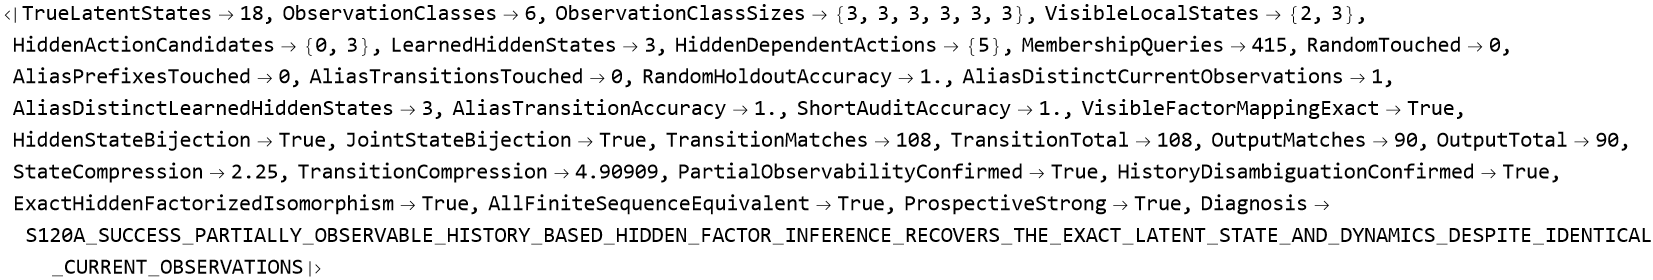

In [395]:
<|

  "TrueLatentStates" ->
    trueJointStateCountS120A,

  "ObservationClasses" ->
    trueObservationClassCountS120A,

  "ObservationClassSizes" ->
    trueObservationClassSizesS120A,

  "VisibleLocalStates" ->
    visibleLocalStateCountsS120A,

  "HiddenActionCandidates" ->
    hiddenActionCandidatesS120A,

  "LearnedHiddenStates" ->
    learnedHiddenStateCountS120A,

  "HiddenDependentActions" ->
    learnedHiddenDependentVisibleActionsS120A,

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS120A,

  "RandomTouched" ->
    randomTouchedBeforeFreezeS120A,

  "AliasPrefixesTouched" ->
    aliasPrefixTouchedBeforeFreezeS120A,

  "AliasTransitionsTouched" ->
    aliasTransitionTouchedBeforeFreezeS120A,

  "RandomHoldoutAccuracy" ->
    randomHoldoutAccuracyS120A,

  "AliasDistinctCurrentObservations" ->
    aliasDistinctTrueCurrentObservationsS120A,

  "AliasDistinctLearnedHiddenStates" ->
    aliasDistinctLearnedHiddenStatesS120A,

  "AliasTransitionAccuracy" ->
    aliasTransitionAccuracyS120A,

  "ShortAuditAccuracy" ->
    shortAuditAccuracyS120A,

  "VisibleFactorMappingExact" ->
    visibleFactorMappingExactS120A,

  "HiddenStateBijection" ->
    hiddenStateBijectionPassedS120A,

  "JointStateBijection" ->
    jointStateBijectionPassedS120A,

  "TransitionMatches" ->
    jointTransitionMatchesS120A,

  "TransitionTotal" ->
    jointTransitionTotalS120A,

  "OutputMatches" ->
    jointOutputMatchesS120A,

  "OutputTotal" ->
    jointOutputTotalS120A,

  "StateCompression" ->
    stateCompressionS120A,

  "TransitionCompression" ->
    transitionCompressionS120A,

  "PartialObservabilityConfirmed" ->
    truePartialObservabilityConfirmedS120A,

  "HistoryDisambiguationConfirmed" ->
    historyDisambiguationConfirmedS120A,

  "ExactHiddenFactorizedIsomorphism" ->
    exactHiddenFactorizedIsomorphismS120A,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS120A,

  "ProspectiveStrong" ->
    prospectiveStrongS120A,

  "Diagnosis" ->
    diagnosisS120A

|>